# FinScore v2.0.13 — PUDIM


#### Notas da Versão

In [60]:
### ===============================================
## Alterações metodológicas: Versão 2.0.13
### ===============================================
# 1. Caminho informado diretamente pelo usuário
# 2. Serasa corrigido.
# 3. Isolamento das variáveis alteráveis pelo analista e dos resultados Fisncore.
# 4. Contador de tempo do script.
# 5. Reorganização do notebook para facilitar a leitura e a manutenção em 6 seções.
#    * 1. LANÇAMENTOS ANALISTA
#    * 2. CONSTANTES METODOLÓGICAS
#    * 3. FUNÇÕES
#    * 4. VERIFICAÇÃO DE ERROS
#    * 5. CÁLCULO DO FINCORE
#    * 6. RESULTADOS

### ===============================================
## Alterações metodológicas: Versão 2.0.12
### ===============================================
# 1. Retificação de erro de sinal na reconstrução do lucro líquido.
# 2. Conserto de parâmetro de exportação invertido.
# 3. Alteração do hash.
# 4. Reconstrução patrimonial assimétrica: inversão do sinal para corrigir.
# 5. Introdução em Monte Carlo de choques por exercício e por contas.
# 6. Corrige a reconstrução do lucro líquido e a exportação.
## V12.1
# 7. excesso de fontes: por padrão, vira caixa/aplicação financeira explícita.
# 8. Alternativas de amortização ou distribuição ficam parametrizadas.
## V12.2
# 9. Torna o fechamento patrimonial simétrico e auditável.
# 10. Compara Monte Carlo independente e correlacionado.
## V12.3
# 11. Amplia os autotestes e reorganiza o notebook por função.
# 12. Controla rejeições e testa a redundância do núcleo FP.
## V12.4
# 13. Normaliza as notas de 0–95 para 0–100 apenas na agregação temporal.
# 14. Substitui a trajetória pura pela dinâmica temporal ajustada ao nível.
# 15. Mantém os pesos de 60% nível, 25% dinâmica e 15% resiliência.
# 16. Acrescenta autotestes específicos para a nova regra temporal.
## V12.5
# 17. Ajustes na verificação de erros na célula 37.

### ===============================================
## Alterações metodológicas: Versão 2.0.11
### ===============================================
# 1. Reorganização da estrutura markdown e comentários do script.

### ===============================================
## Alterações metodológicas Versão 2.0.10
### ===============================================
# 1.  Saída final ao parecerista incorpora informações monte carlo e pca.

### ===============================================   
## Alterações metodológicas Versão 2.0.9
### ===============================================
# 1.  Revisão completa do código.
# 2.  Comentários em cada célula do código.
# 3.  Testes com números diversos de simulações e validação do monte carlo.

### ===============================================
## Alterações metodológicas Versão 2.0.7
### ===============================================
# 1. cada indicador passou a separar nível atual (60%), trajetória (25%) e resiliência (15%);
# 2. o PCA passou a usar índices orientados e padronizados de forma robusta, com participação máxima de 15% e teste de estabilidade;
# 3. os núcleos passaram a ser agregados por média geométrica, com componente de gargalo e caps prudenciais;
# 4. foi criado um índice de confiabilidade separado do FinScore;
# 5. curvas excessivamente saturadas foram substituídas por tetos econômicos de 95 pontos;
# 6. o PL deixou de ser conta residual do Monte Carlo; ele é sorteado como driver explícito e o Ativo Total fecha a identidade;
# 7. foram incluídos cenários determinísticos, faixa de incerteza para classificação desconhecida da dívida e contribuição por indicador;
# 8. novos autotestes verificam monotonicidade, invariância monetária, não compensação, estabilidade do PCA e limites dos choques.

In [61]:
# pip install matplotlib pandas numpy scikit-learn openpyxl

*Início dos lançamentos pelo analista.*

***

## 1. LANÇAMENTOS ANALISTA

#### 1.1 Empresa

In [62]:
# INSERIR OS DADOS
# Apontar a planilha com as informações contábeis da empresa avaliada.
caminho = "/home/ferna/dev_linux/FinScore/V. 2 (Pudim)/MODELO/dados_teste/1Callamarys.xlsx"

#### 1.2 Serasa

In [63]:
# INSERIR OS DADOS
SERASA_SCORE = 700
SERASA_DATA_CONSULTA = "2026-07-23"
SERASA_RESTRICAO_GRAVE = False

*Fim dos lançamentos pelo analista.*

Consulte os resultados na seção '10.1 FinScore'.

Não alterar mais nada a partir daqui.

***

In [64]:
# NÃO MEXER
import time

inicio = time.time()

#### 1.3 Fonte dos Dados

In [65]:
# NÃO MEXER
import os

CAMINHO_PLANILHA = os.environ.get(
    "FINSCORE_PLANILHA",
    caminho,
)

In [66]:
# NÃO MEXER
import os
from pathlib import Path

if 'CAMINHO_PLANILHA' not in globals():
    raise NameError(
        "Variável `CAMINHO_PLANILHA` não definida. Edite a célula 0.1 Caminho antes de executar."
    )

# Normaliza para Path
CAMINHO_PLANILHA = CAMINHO_PLANILHA if isinstance(CAMINHO_PLANILHA, Path) else Path(CAMINHO_PLANILHA)

if not CAMINHO_PLANILHA.exists():
    disponiveis = sorted(Path.cwd().glob("*.xlsx"))
    dados_teste = Path.cwd() / "dados_teste"
    if dados_teste.exists():
        disponiveis = sorted(set(disponiveis) | set(dados_teste.glob("*.xlsx")), key=lambda p: str(p))
    if disponiveis:
        print("Arquivo não encontrado. Planilhas disponíveis (caminhos):")
        for arquivo in disponiveis:
            print(" -", arquivo)
    else:
        print("Arquivo não encontrado. Nenhuma planilha .xlsx encontrada em `cwd` ou `dados_teste`.")
    raise FileNotFoundError(
        f"Ajuste CAMINHO_PLANILHA. Não foi encontrado: {CAMINHO_PLANILHA}"
    )

ABA_DADOS = os.environ.get("FINSCORE_ABA", "lancamentos")


In [67]:
# NÃO MEXER
# 1 exporta; 0 não exporta.
def parse_export_flag(value: str) -> bool:
    value = str(value).strip()
    if value not in {"0", "1"}:
        raise ValueError("FINSCORE_EXPORTAR deve ser '0' ou '1'.")
    return value == "1"


EXPORTAR_EXCEL = parse_export_flag(os.environ.get("FINSCORE_EXPORTAR", "1"))


***

## 2. CONSTANTES METODOLÓGICAS

#### 2.1 Versão do modelo

In [68]:
# NÃO MEXER
VERSAO_MODELO = "2.0.13"


In [69]:
# NÃO MEXER
import hashlib as _hashlib
import json as _json
import re as _re
from pathlib import Path as _Path

NOME_NOTEBOOK_MODELO = "FinScore_V2_13_retificado.ipynb"
HASH_CODIGO_MODELO = "a80c3aaff323eb29fd92d5112af1bd9981a1895a46c25662588442147de0babb"


def calcular_hash_codigo_modelo(caminho) -> str:
    notebook = _json.loads(_Path(caminho).read_text(encoding="utf-8"))
    fontes = []
    for cell in notebook.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        if "finscore_editavel" in cell.get("metadata", {}).get("tags", []):
            continue
        fonte = "".join(cell.get("source", []))
        fonte = _re.sub(
            r'(?m)^HASH_CODIGO_MODELO\s*=\s*["\'][0-9a-f_]{16,}["\']',
            'HASH_CODIGO_MODELO = "<NEUTRALIZADO>"',
            fonte,
        )
        fontes.append(fonte)
    payload = _json.dumps(
        fontes, ensure_ascii=False, separators=(",", ":")
    ).encode("utf-8")
    return _hashlib.sha256(payload).hexdigest()


def localizar_notebook_modelo() -> _Path:
    cwd = _Path.cwd()
    explicit = os.environ.get("FINSCORE_NOTEBOOK")
    preferred = _Path(explicit) if explicit else cwd / NOME_NOTEBOOK_MODELO
    candidates = [preferred]
    # Procura na pasta do kernel, em até três subníveis e nos pais imediatos.
    patterns = [
        NOME_NOTEBOOK_MODELO, "*.ipynb",
        f"*/{NOME_NOTEBOOK_MODELO}", "*/*.ipynb",
        f"*/*/{NOME_NOTEBOOK_MODELO}", "*/*/*.ipynb",
        f"*/*/*/{NOME_NOTEBOOK_MODELO}", "*/*/*/*.ipynb",
    ]
    for pattern in patterns:
        try:
            candidates.extend(sorted(cwd.glob(pattern)))
        except (OSError, PermissionError):
            continue
    for parent in list(cwd.parents)[:3]:
        candidates.append(parent / NOME_NOTEBOOK_MODELO)
        try:
            candidates.extend(sorted(parent.glob("*.ipynb")))
        except (OSError, PermissionError):
            continue
    seen = set()
    for candidate in candidates:
        resolved = candidate.resolve()
        if resolved in seen or not candidate.exists():
            continue
        seen.add(resolved)
        try:
            if calcular_hash_codigo_modelo(candidate) == HASH_CODIGO_MODELO:
                return candidate
        except Exception:
            continue
    return preferred


CAMINHO_NOTEBOOK_MODELO = localizar_notebook_modelo()
HASH_CODIGO_RECALCULADO = (
    calcular_hash_codigo_modelo(CAMINHO_NOTEBOOK_MODELO)
    if CAMINHO_NOTEBOOK_MODELO.exists() else None
)
HASH_CODIGO_VERIFICAVEL = HASH_CODIGO_RECALCULADO is not None
STATUS_HASH_CODIGO = (
    'VERIFICADO' if HASH_CODIGO_VERIFICAVEL else 'NAO_VERIFICADO'
)


In [70]:
# NÃO MEXER
# Definição robusta de data/hora e arquivo de saída para evitar colisões de nome
import datetime as _dt
from pathlib import Path
import os

DATA_HORA_PROCESSAMENTO = _dt.datetime.now()

ARQUIVO_SAIDA = Path(
    os.environ.get(
        "FINSCORE_SAIDA",
        f"resultados_finscore_{VERSAO_MODELO}_{DATA_HORA_PROCESSAMENTO:%Y%m%d_%H%M}.xlsx",
    )
)

print(f"Versão: {VERSAO_MODELO}")
print(f"Hash do código: {HASH_CODIGO_MODELO}")
if "CAMINHO_PLANILHA" in globals():
    try:
        print(f"Planilha: {Path(CAMINHO_PLANILHA).resolve()}")
    except Exception:
        print("Planilha: definida, mas não é possível resolver o caminho.")
else:
    print("Planilha: CAMINHO_PLANILHA não definida.")

print(f"Aba: {ABA_DADOS if 'ABA_DADOS' in globals() else '<NA>'}")


Versão: 2.0.13
Hash do código: a80c3aaff323eb29fd92d5112af1bd9981a1895a46c25662588442147de0babb
Planilha: /home/ferna/dev_linux/FinScore/V. 2 (Pudim)/MODELO/dados_teste/1Callamarys.xlsx
Aba: lancamentos


In [71]:
# NÃO MEXER
import math
import re
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


#### 2.2 Qtde de Simulações MC

In [72]:
# Valor padrão em investigação
MONTE_CARLO_NUM = 1000


In [73]:
# NÃO MEXER
NUM_SIMULACOES = int(os.environ.get("FINSCORE_SIMULACOES", MONTE_CARLO_NUM))
SEMENTE = int(os.environ.get("FINSCORE_SEMENTE", "20260723"))


In [74]:
## MONTE CARLO
# Parâmetros gerais e de sensibilidade.
# Amplitudes mínima e máxima dos choques
DELTA_MIN = 0.05 # O algoritmo observa a maior variação histórica da conta entre os três anos. Se essa variação tiver sido inferior a 5%, usará 5%.
DELTA_MAX = 0.35 # Se uma conta tiver variado 60% historicamente, o Monte Carlo não repetirá toda essa amplitude. O choque ficará limitado a 35%.
# Ponto crítico: os limites de 5% e 35% são escolhas normativas. Precisam ser justificados e testados empiricamente para verificar se não produzem incerteza artificialmente estreita ou ampla.

# Tolerância contábil: Permite divergência de até 1% na verificação das identidades contábeis.
BALANCE_TOLERANCE = 0.01/2

# Limite de tentativas do Monte Carlo
MAX_ATTEMPT_FACTOR = 40 # fator de multiplicação do número de simulações.

# Cobertura mínima de cada núcleo
# Exige que pelo menos 70% do peso informacional de um núcleo esteja disponível para calcular sua nota. O FinScore possui dois núcleos:econômico-operacional e financeiro-patrimonial. A cobertura considera os pesos dos indicadores e sua disponibilidade temporal. Não é simplesmente “70% da quantidade de índices”. Exemplo: Indicadores disponíveis representam 80% dos pesos → núcleo calculado; Indicadores disponíveis representam 60% dos pesos → núcleo não calculado. Se a cobertura ficar abaixo de 70%, a nota do núcleo recebe NaN. Isso evita calcular um resultado aparentemente preciso com informações insuficientes.
# O limite de 70% também é normativo e precisa ser validado por testes de sensibilidade.
MIN_NUCLEUS_COVERAGE = 0.70

# Limites de sensibilidade do FinScore. Após as simulações, o algoritmo calcula a frequência com que cada versão do FinScore ficou abaixo de 125, 250 e 500. Se a frequência for maior que o limite, o FinScore é considerado sensível e recebe alerta. O analista deve avaliar se a sensibilidade é aceitável ou se há necessidade de ajustes.
SENSITIVITY_THRESHOLDS = [125, 250, 500]

# Limite de rejeição e dependência do Monte Carlo.
MAX_REJECTION_RATE = 0.25
MC_TEMPORAL_PERSISTENCE = 0.60
MC_IDIOSYNCRATIC_PERSISTENCE = 0.25

# Fechamento patrimonial dos cenários.
EXCESS_SOURCE_RULE = "CAIXA_APLICACAO"
FUNDING_CP_SHARE = 0.70

# Materialidade do diagnóstico de redundância FP.
FP_REDUNDANCY_MATERIALITY_POINTS = 25.0


#### 2.3 Pesos das Contas

In [75]:
# Drivers sorteados diretamente.
SIMULATION_DRIVER_ACCOUNTS = {
    "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques",
    "p_Imobilizado_Liquido", "p_Fornecedores",
    "p_Obrigacoes_Tributarias_CP", "p_Obrigacoes_Trabalhistas_CP",
    "p_Emprestimos_Financiamentos_CP",
    "p_Emprestimos_Financiamentos_LP", "p_Patrimonio_Liquido",
    "r_Receita_Liquida", "r_CMV_CPV_CSV", "r_Receitas_Financeiras",
    "r_Despesa_IR_CSLL", "r_Despesas_Financeiras",
}

# Cargas do fator econômico comum. O sinal indica a direção esperada.
MC_COMMON_LOADINGS = {
    "p_Caixa_Equivalentes": 0.55,
    "p_Contas_Receber_Clientes": 0.65,
    "p_Estoques": 0.35,
    "p_Ativo_Circulante": 0.55,
    "p_Imobilizado_Liquido": 0.40,
    "p_Fornecedores": 0.55,
    "p_Obrigacoes_Tributarias_CP": 0.45,
    "p_Obrigacoes_Trabalhistas_CP": 0.35,
    "p_Passivo_Circulante": 0.20,
    "p_Passivo_Nao_Circulante": -0.25,
    "p_Emprestimos_Financiamentos_CP": -0.50,
    "p_Emprestimos_Financiamentos_LP": -0.40,
    "p_Patrimonio_Liquido": 0.70,
    "r_Receita_Liquida": 0.90,
    "r_CMV_CPV_CSV": 0.75,
    "r_Receitas_Financeiras": 0.30,
    "r_Despesa_IR_CSLL": 0.65,
    "r_Despesas_Financeiras": -0.55,
    "d_EBIT": 0.90,
    "d_Outros_Efeitos_Pos_Tributacao": 0.25,
}


#### 2.4 Constantes PCA

In [76]:
# ============================================================
# CONSTANTES DO PCA — Estabilidade e Adaptabilidade
# ============================================================

# Seed para reproduzibilidade dos testes de estabilidade do PCA
PCA_STABILITY_SEED = 42

# Número mínimo de variáveis ativas para aceitar o PCA
PCA_MIN_ACTIVE_VARIABLES = 3

# Número de repetições do teste de estabilidade
PCA_STABILITY_REPETITIONS = 160

# Desvio-padrão do ruído nas perturbações de estabilidade
PCA_PERTURBATION_SD = 0.05

# Distância L1 máxima permitida entre pesos originais e perturbados
PCA_MAX_MEAN_L1_DISTANCE = 0.25

# Similaridade de cosseno mínima entre pesos originais e perturbados
PCA_MIN_MEAN_COSINE = 0.90

# Maior peso individual que o PCA puro pode atribuir a um indicador
PCA_MAX_PURE_WEIGHT = 0.50

# Compartilhamento adaptativo: até 15% dos pesos podem vir do PCA
PCA_ADAPTIVE_SHARE = 0.15

# Pesos dos núcleos EO e FP na agregação final por média geométrica
NUCLEUS_WEIGHTS = {
    "EO": 0.50,  # Econômico-Operacional
    "FP": 0.50,  # Financeiro-Patrimonial
}

# Compartilhamento do gargalo: quanto a nota é puxada para baixo pelo núcleo mais fraco
BOTTLENECK_SHARE = 0.25

# Clipping robusto para padronização: limita extremos a ±3 desvios-padrão robustos
PCA_ROBUST_CLIP = 3.0


In [77]:
## PCA
# A nota temporal deixa de ser uma média opaca dos três anos.
# Nível atual domina; dinâmica ajustada e pior desempenho evitam leitura pontual.
TEMPORAL_COMPONENT_WEIGHTS = {
    "nivel_atual": 0.60, # É a nota do indicador no balanço mais recente. e as notas anuais de liquidez forem: 2023: 40; 2024: 60; e 2025: 80, então: nível atual = 80 -- O ano mais recente domina a nota temporal com peso de 60%.
    "dinamica_temporal": 0.25, # Combina o nível final normalizado com metade da variação normalizada entre o primeiro e o último ano válido.
    "resiliencia": 0.15, # É a pior nota observada nos três exercícios:
}

# O PCA é diagnóstico auxiliar. Com três observações, não pode definir sozinho a relevância econômica dos indicadores.
# Esse bloco controla quanto o PCA pode influenciar os pesos dos indicadores e quando essa influência será aceita.
# A lógica geral é:
# calcular pesos fixos definidos economicamente;
# calcular os pesos sugeridos pelo PCA;
# testar se esses pesos do PCA são estáveis;
# se forem estáveis, permitir influência máxima de 15%;


In [78]:
# Orientação usada apenas para leitura das cargas do PCA.
# A importância usa cargas absolutas e, portanto, não depende do sinal.

# Esses três indicadores têm relação inversa com a capacidade financeira:
# maior endividamento exigível → pior;
# maior dívida líquida/ativo → pior;
# maior concentração do endividamento no curto prazo → pior.
# O valor -1 informa essa direção desfavorável. Indicadores não listados presumivelmente têm direção positiva: quanto maiores, melhor.
# No PCA, uma carga pode ser positiva ou negativa sem que isso, isoladamente, defina a importância do indicador. A importância é calculada pelo valor absoluto:
# Assim:
# Carga = +0,80 → importância = 0,80
# Carga = −0,80 → importância = 0,80
# O sinal serve apenas para interpretar a direção da relação com o componente. Ele não altera o peso adaptativo dado ao indicador.
# Há uma distinção essencial:
# INDICATOR_DIRECTION: interpretação econômica previamente estabelecida;
# sinal da carga do PCA: associação estatística dentro daquela amostra.
# Esses sinais não são necessariamente iguais. Além disso, o sinal de um componente principal pode ser completamente invertido sem alterar o PCA. Por isso, o código está correto ao não usar diretamente o sinal da carga como medida de importância.
INDICATOR_DIRECTION = {
    "endividamento_exigivel": -1,
    "divida_liquida_ativo": -1,
    "composicao_endividamento": -1,
}


#### 2.5 Execução de Autotestes

In [79]:
# VALOR PADRÃO: Sim: 1.

# Eles verificam, entre outras coisas, se:
# existem as 21 contas primárias;
# a identidade contábil é respeitada;
# os dados originais não são alterados;
# os scores permanecem entre 0 e 1.000;
# os pesos do PCA somam 100%;
# a participação do PCA não excede 15%;
# multiplicar todos os valores por 1.000 não muda o FinScore;
# aumentar a dívida não melhora indevidamente o score;
# aumentar caixa com capital próprio não piora o score;
# um núcleo muito ruim não é totalmente compensado pelo outro;
# a mesma semente produz as mesmas simulações;
# os choques do Monte Carlo respeitam os limites;
# os cenários determinísticos permanecem contabilmente válidos;
# inconsistências e correções são detectadas e auditadas;
# o Serasa não é misturado automaticamente ao FinScore.
EXECUTAR_AUTOTESTES = os.environ.get("FINSCORE_AUTOTESTES", "1") == "1"


In [80]:
# NÃO MEXER

## Política de correção:
# - a origem nunca é alterada;
# - correções automáticas só entram na cópia analítica quando a confiança
#   mínima é atingida;
# - toda correção automática material mantém o resultado como provisório.

## Tratamento de erros antes do cálculo
# Corrigir somente quando uma identidade contábil permitir deduzir o valor com alta confiança, preservando os dados originalmente informados.
POLITICA_CORRECAO = "HIERARQUIA_CONTABIL_CONTROLADA"

# Determina se uma correção identificada pelo algoritmo será realmente utilizada na base de análise:
# True: aplica a correção na cópia usada para calcular o FinScore;
# False: apenas registra a correção proposta, sem alterar a base analítica.
# A base original nunca é modificada.
APLICAR_CORRECOES_AUTOMATICAS = True

# Confiança mínima para corrigir automaticamente uma conta. Se a confiança for menor, a correção é apenas registrada.
LIMIAR_CONFIANCA_AUTOMATICA = 0.90

# Significa que uma alteração igual ou superior a 1% do Ativo Total é considerada material.
# Uma correção material gera alerta, bloqueia o uso definitivo do resultado e faz o score ser tratado como provisório até confirmação documental.
LIMIAR_MATERIALIDADE = 0.01       # 1% do Ativo Total

# Com Ativo Total de R$ 1.000.000: 5% × R$ 1.000.000 = R$ 50.000. Se os componentes de uma conta excederem o subtotal em pelo menos R$ 50.000, o problema recebe classificação mais grave, como potencial viés crítico.
# A diferença entre os dois limites é:
# 1%: já merece alerta por ser material;
# 5%: indica impacto alto ou crítico.
LIMIAR_VIES_ALTO = 0.05           # 5% do Ativo Total

# Se os dados ainda permitem o cálculo, mas existe uma correção ou inconsistência que impede uma decisão definitiva, apresente o FinScore como provisório.
PERMITIR_SCORE_PROVISORIO = True

# Ajustes manuais opcionais. Não use para "fazer fechar" sem documento-fonte.
# Exemplo:
# CORRECOES_MANUAIS = [{
#     "ano": 2025,
#     "conta": "p_Passivo_Nao_Circulante",
#     "valor": 123456.78,
#     "fonte": "BP assinado, p. 2",
#     "justificativa": "Erro de transcrição confirmado",
#     "responsavel": "Analista responsável",
#     "confirmado": True,
# }]
CORRECOES_MANUAIS = []


#### 2.6 Contas

In [81]:
## Primárias
# Contas oriundas dos lançamentos manuais. 
# São elas que recebem os choques aleatórios ou determinísticos do Monte Carlo. As demais contas derivadas são calculadas a partir dessas primárias.
PRIMARY = [
    "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques",
    "p_Ativo_Circulante", "p_Imobilizado_Liquido", "p_Ativo_Total",
    "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
    "p_Obrigacoes_Trabalhistas_CP", "p_Passivo_Circulante",
    "p_Passivo_Nao_Circulante", "p_Emprestimos_Financiamentos_CP",
    "p_Emprestimos_Financiamentos_LP", "p_Patrimonio_Liquido",
    "r_Receita_Liquida", "r_CMV_CPV_CSV", "r_Resultado_Antes_IR_CSLL",
    "r_Lucro_Liquido", "r_Receitas_Financeiras", "r_Despesa_IR_CSLL",
    "r_Despesas_Financeiras",
]

# Contas que podem ter sinal negativo
# contas como receita, CMV, despesas financeiras e despesa de IR/CSLL estão em NONNEGATIVE. Isso significa que devem ser lançadas pelo valor absoluto, sem sinal negativo
SIGNED_ACCOUNTS = {
    "p_Patrimonio_Liquido", "r_Resultado_Antes_IR_CSLL", "r_Lucro_Liquido",
}
STRICTLY_POSITIVE = {"p_Ativo_Total"}
NONNEGATIVE = set(PRIMARY) - SIGNED_ACCOUNTS


#### 2.7 Limites/Caps das Contas

In [82]:
# Limites preliminares e versionados. Eles não substituem calibração setorial;
# impedem apenas que uma condição patrimonial crítica receba nota incompatível.

## Condições críticas: tetos de FinScore para situações específicas
PRUDENTIAL_CAPS = {
    "pl_negativo": 350.0, # Patrimônio Líquido negativo
    "pl_ativo_abaixo_2pct": 500.0, # Capitalização inferior a 2%. Capitalização = Patrimônio Líquido / Ativo Total
    "pl_ativo_abaixo_5pct": 650.0, # Capitalização entre 2% e 5%
    "endividamento_maior_igual_100pct": 500.0, # Endividamento igual ou superior a 100%. Endividamento exigível = (Passivo Circulante + Passivo Não Circulante) / Ativo Total
    "endividamento_maior_igual_95pct": 650.0, # Endividamento entre 95% e 100%
    "cobertura_juros_abaixo_1x": 500.0, # Cobertura de juros inferior a 1x. Cobertura de juros = Resultado Antes do IR/CSLL / Despesas Financeiras
}

# r_Despesas_Financeiras só pode representar juros quando a origem da conta
# tiver sido conferida. Se False, Cobertura de Juros ficará indisponível.
USAR_DESPESAS_FINANCEIRAS_COMO_PROXY_JUROS = True # Com o parâmetro em True, o modelo admite: Despesas com Juros ~ Despesas Financeiras
COBERTURA_JUROS_TETO_ECONOMICO = 10.0 # Limita a Cobertura de Juros a 10x. Se a empresa tiver cobertura de juros de 15x, o modelo considera apenas 10x para fins de cálculo do FinScore. Isso evita que empresas com endividamento muito baixo recebam nota excessivamente alta apenas por terem juros baixos.

# Pesos estruturais: trajetória do EBIT já é capturada no bloco temporal.
# Capitalização entra explicitamente; capitalização e endividamento têm peso combinado limitado para reduzir redundância contábil.
FIXED_WEIGHTS = {
    "crescimento_receita": 0.15,
    "margem_bruta": 0.10,
    "margem_ebit": 0.30,
    "margem_liquida": 0.20,
    "giro_ativo": 0.25,
    "capitalizacao": 0.20,
    "endividamento_exigivel": 0.10,
    "liquidez_corrente": 0.15,
    "liquidez_seca": 0.10,
    "ccl_ativo": 0.10,
    "divida_liquida_ativo": 0.10,
    "cobertura_juros": 0.15,
    "composicao_endividamento": 0.10,
}

NUCLEI = {
    "EO": [
        "crescimento_receita", "margem_bruta", "margem_ebit",
        "margem_liquida", "giro_ativo",
    ],
    "FP": [
        "capitalizacao", "endividamento_exigivel", "liquidez_corrente",
        "liquidez_seca", "ccl_ativo", "divida_liquida_ativo",
        "cobertura_juros", "composicao_endividamento",
    ],
}

# O EBIT aparece de duas maneiras diferentes: seu nível relativo é capturado pela margem EBIT; sua evolução ao longo dos exercícios é capturada pelo bloco temporal.
# Verificar a calibração destes pesos posteriormente.


In [83]:
# Curvas normativas preliminares. O teto econômico é 95, não 100:
# valor extremo gera alerta de plausibilidade, não prêmio adicional.
# O melhor desempenho econômico observável pelas curvas recebe, no máximo, 95 pontos. A justificativa é prudencial: um indicador excepcionalmente alto não representa ausência total de risco nem qualidade perfeita.
CURVE_MAX_SCORE = 95.0

# Os pares em ANCHORS são pontos de referência — ou “âncoras” — usados para construir uma curva por interpolação. Cada par tem o formato: (valor_do_indicador, nota_correspondente). Se a empresa tiver margem exatamente igual a uma âncora, recebe a nota associada. Se estiver entre duas âncoras, o código deve calcular uma nota intermediária por interpolação linear.
ANCHORS = {
    "crescimento_receita": [ # A curva premia crescimento e pune retração. Ponto crítico: crescimento muito alto não é necessariamente saudável. Pode decorrer de inflação, aquisição, início recente das atividades, expansão financiada por dívida ou base anterior muito baixa. Por isso, essa curva precisa ser combinada com margens, giro, liquidez e endividamento.
        (-0.30, 0), (0, 45), (0.10, 70), (0.25, 90), (0.50, 95),
    ],
    "margem_bruta": [ # Margem negativa indica que a receita não cobre os custos diretos. Margens maiores representam maior capacidade de absorver despesas operacionais, financeiras e tributárias. A fragilidade é fortemente setorial: uma distribuidora pode ser saudável com margem bruta baixa, enquanto uma prestadora de serviços pode apresentar margem muito maior. Uma curva única pode favorecer determinados modelos de negócio.
        (-0.10, 0), (0, 10), (0.15, 45), (0.30, 75), (0.50, 95),
    ],
    "margem_ebit": [ # Mede a rentabilidade operacional antes dos efeitos dos juros e dos tributos sobre o lucro. Uma margem igual a zero recebe 35 porque a operação não está produzindo lucro operacional, mas também não apresenta prejuízo operacional. Ainda assim, a nota talvez seja relativamente generosa, especialmente porque esse indicador recebe peso estrutural de 30% no núcleo EO.
        (-0.20, 0), (0, 35), (0.10, 70), (0.20, 90), (0.35, 95),
    ],
    "margem_liquida": [ # Mede quanto da receita permanece como lucro após custos, despesas, resultado financeiro e tributos. A curva alcança notas altas mais cedo que a margem EBIT porque, normalmente, a margem líquida é inferior à operacional.
        (-0.20, 0), (0, 35), (0.07, 70), (0.15, 90), (0.25, 95),
    ],
    "giro_ativo": [ # A interpretação depende do setor. Comércio tende a apresentar giro maior; atividades industriais, imobiliárias e de infraestrutura podem demandar ativos elevados e apresentar giro menor sem que isso indique baixa eficiência.
        (0, 0), (0.30, 25), (0.70, 60), (1.20, 85), (2, 95), (5, 95),
    ],
    "capitalizacao": [ # Quanto maior a participação do patrimônio próprio no financiamento dos ativos, maior a capacidade patrimonial de absorver perdas. Capitalização negativa representa passivo a descoberto. Capitalização próxima de zero recebe nota muito baixa, mesmo que o patrimônio ainda seja formalmente positivo.
        (-0.20, 0), (0, 5), (0.05, 20), (0.15, 50), (0.30, 80), (0.50, 95),
    ],
    "endividamento_exigivel": [ # Essa é uma curva decrescente: quanto maior o endividamento, menor a nota. (Endividamento exigível = (Passivo Circulante + Passivo Não Circulante) / Ativo Total)
        (0, 95), (0.30, 85), (0.50, 60), (0.70, 30), (1, 0), (1.50, 0),
    ],
    "liquidez_corrente": [ # Liquidez igual a 1 significa equivalência contábil entre ativos e passivos circulantes, mas sem folga para perdas, inadimplência, estoques obsoletos ou diferenças de vencimento. Por isso recebe nota intermediária, não alta. Liquidez excessiva também não ganha prêmio adicional. Pode inclusive indicar caixa ocioso, estoques elevados ou capital de giro mal empregado
        (0, 0), (0.70, 10), (1, 45), (1.30, 70), (1.80, 95), (4, 95),
    ],
    "liquidez_seca": [ # Ainda assim, sua interpretação é setorial: estoques são mais relevantes para uma indústria ou varejista do que para uma prestadora de serviços.
        (0, 0), (0.50, 10), (0.80, 40), (1.10, 70), (1.50, 95), (3, 95),
    ],
    "ccl_ativo": [ # Diferentemente das liquidez corrente e seca, esse indicador relaciona a folga de curto prazo ao tamanho total da empresa.
        (-0.50, 0), (-0.10, 15), (0, 45), (0.10, 65), (0.25, 85), (0.50, 95),
    ],
    "divida_liquida_ativo": [ # Valor negativo significa que o caixa supera a dívida onerosa. Entretanto, não recebe nota acima de 95 nem deve ser automaticamente considerado perfeito: caixa excepcionalmente elevado pode ser temporário ou decorrer da venda de ativos.
        (-0.30, 95), (0, 90), (0.20, 70), (0.40, 35), (0.70, 0),
    ],
    "composicao_endividamento": [ # Quanto maior a concentração das obrigações no curto prazo, maior a pressão imediata sobre o caixa. A curva não mede o volume total de dívida: uma empresa pode ter pouca dívida, mas toda no curto prazo. Por isso, deve ser interpretada em conjunto com endividamento exigível e liquidez.
        (0, 95), (0.30, 80), (0.50, 55), (0.75, 25), (1, 0),
    ],
    "cobertura_juros": [ # Cobertura igual a 1 significa que o EBIT é apenas suficiente para os juros, sem margem para oscilações. Por isso, recebe somente 25 pontos. O ponto (50, 95) mantém o platô e evita extrapolação indevida.
        (-2, 0), (0, 5), (1, 25), (2, 55), (4, 80), (10, 95), (50, 95),
    ],
}


#### 2.8 Cenários

In [84]:
SCENARIO_DEFINITIONS = {
    "BASE": { # O cenário combina choques que podem se reforçar mutuamente. A empresa vende menos, recebe mais lentamente, acumula estoques, perde caixa e recorre a mais dívida.
        "descricao": "Manutenção aproximada da estrutura observada.",
        "receita": 0.00, "margem_ebit": 0.00, "contas_receber": 0.00,
        "estoques": 0.00, "caixa": 0.00, "juros": 0.00,
        "divida": 0.00, "pl": 0.00, "pc_total": 0.00, "pnc_total": 0.00,
    },
    "ADVERSO": { # O cenário adverso representa uma situação de declínio econômico, onde a empresa enfrenta redução de receitas, compressão de margens e pressão sobre seu capital de giro.
        "descricao": "Queda de receita, compressão de margem e pressão de capital de giro.",
        "receita": -0.10, "margem_ebit": -0.20, "contas_receber": 0.15,
        "estoques": 0.10, "caixa": -0.15, "juros": 0.25,
        "divida": 0.10, "pl": -0.10, "pc_total": 0.08, "pnc_total": 0.05,
    },
    "SEVERO": { # O cenário severo representa uma situação de estresse econômico, onde a empresa enfrenta uma queda significativa nas receitas, margens comprimidas e desafios financeiros mais acentuados.
        "descricao": "Estresse forte de atividade, margem, liquidez e custo financeiro.",
        "receita": -0.25, "margem_ebit": -0.40, "contas_receber": 0.30,
        "estoques": 0.20, "caixa": -0.30, "juros": 0.60,
        "divida": 0.25, "pl": -0.25, "pc_total": 0.18, "pnc_total": 0.12,
    },
}


In [85]:
assert len(PRIMARY) == 21
assert np.isclose(sum(TEMPORAL_COMPONENT_WEIGHTS.values()), 1.0)
assert np.isclose(sum(NUCLEUS_WEIGHTS.values()), 1.0)
for nucleo, colunas in NUCLEI.items():
    assert np.isclose(sum(FIXED_WEIGHTS[c] for c in colunas), 1.0)

print(f"Ambiente carregado e premissas estruturais da {VERSAO_MODELO} verificadas.")


Ambiente carregado e premissas estruturais da 2.0.13 verificadas.


***

## 3. FUNÇÕES

#### 3.1 Importação e Validação

In [86]:
import hashlib
import json


QUALITY_COLUMNS = [
    "severidade", "tipo", "conta", "exercicios", "detalhe",
    "bloqueia_calculo", "bloqueia_decisao", "bloqueia_score",
]

AUDIT_COLUMNS = [
    "evento_id", "data_hora", "etapa", "acao", "status_acao", "ano", "conta",
    "valor_original", "valor_proposto", "valor_utilizado", "delta_absoluto",
    "delta_percentual", "materialidade_pct_ativo", "regra_id",
    "regra_descricao", "evidencia", "confianca", "potencial_vies",
    "indicadores_afetados", "requer_confirmacao", "confirmado",
    "bloqueia_calculo", "bloqueia_decisao", "fonte", "responsavel",
]


def safe_div(a: pd.Series, b: pd.Series) -> pd.Series:
    # Tolerância relativa evita divisões por denominadores materialmente nulos.
    b_float = b.astype(float)
    scale = max(float(b_float.abs().median(skipna=True) or 0.0), 1.0)
    denominator = b_float.where(b_float.abs() > 1e-9 * scale)
    return a.astype(float).div(denominator).replace([np.inf, -np.inf], np.nan)


def _is_blank_accounting_value(value) -> bool:
    if pd.isna(value):
        return True
    return str(value).strip().lower() in {
        "", "-", "--", "n/a", "na", "nan", "none", "null"
    }


def parse_accounting_value(value) -> float:
    # Converte números e textos contábeis sem confundir ausência com zero.
    if _is_blank_accounting_value(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value) if np.isfinite(value) else np.nan

    text = str(value).strip()
    negative_parentheses = text.startswith("(") and text.endswith(")")
    text = re.sub(r"[^0-9,\.\-+]", "", text)
    if not text or text in {"-", "+", ".", ","}:
        return np.nan

    if "," in text and "." in text:
        if text.rfind(",") > text.rfind("."):
            text = text.replace(".", "").replace(",", ".")
        else:
            text = text.replace(",", "")
    elif "," in text:
        parts = text.split(",")
        text = (
            "".join(parts)
            if len(parts[-1]) == 3 and len(parts) > 1
            else text.replace(",", ".")
        )
    elif text.count(".") > 1:
        parts = text.split(".")
        text = (
            "".join(parts)
            if len(parts[-1]) == 3
            else "".join(parts[:-1]) + "." + parts[-1]
        )

    try:
        number = float(text)
    except ValueError:
        return np.nan
    return -abs(number) if negative_parentheses else number


def dataframe_sha256(df: pd.DataFrame) -> str:
    # O hash permite provar se a base usada numa execução foi alterada.
    normalized = df.copy()
    normalized = normalized.reindex(sorted(normalized.columns), axis=1)
    payload = pd.util.hash_pandas_object(
        normalized, index=True, categorize=True
    ).values.tobytes()
    return hashlib.sha256(payload).hexdigest()


def load_raw_data(path: Path, sheet_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    source = pd.read_excel(path, sheet_name=sheet_name)
    missing_columns = [c for c in ["ano", *PRIMARY] if c not in source.columns]
    if missing_columns:
        raise ValueError(f"Colunas ausentes na aba {sheet_name}: {missing_columns}")

    source = source[["ano", *PRIMARY]].dropna(how="all", subset=PRIMARY).copy()
    if len(source) != 3:
        raise ValueError(f"A aba deve ter 3 exercícios preenchidos; encontrei {len(source)}.")

    year_numeric = pd.to_numeric(source["ano"], errors="coerce")
    invalid_year = year_numeric.isna() | (year_numeric <= 0) | (year_numeric % 1 != 0)
    if invalid_year.any():
        rows = (source.index[invalid_year] + 2).tolist()
        raise ValueError(f"Exercício/ano deve ser inteiro positivo. Linhas inválidas: {rows}")
    source["ano"] = year_numeric.astype(int)
    if source["ano"].duplicated().any():
        years = source.loc[source["ano"].duplicated(keep=False), "ano"].tolist()
        raise ValueError(f"Há exercícios duplicados: {years}")
    source = source.sort_values("ano").reset_index(drop=True)

    report = []
    for column in PRIMARY:
        original = source[column].copy()
        converted = original.map(parse_accounting_value)
        blank = original.map(_is_blank_accounting_value)
        invalid = converted.isna() & ~blank
        absent = converted.isna() & blank
        if invalid.any():
            report.append({
                "severidade": "CRITICA",
                "tipo": "erro_conversao",
                "conta": column,
                "exercicios": ", ".join(source.loc[invalid, "ano"].astype(str)),
                "detalhe": "Valor textual não pôde ser convertido; revisar a origem.",
                "bloqueia_calculo": True,
                "bloqueia_decisao": True,
                "bloqueia_score": True,
            })
        if absent.any():
            report.append({
                "severidade": "AVISO",
                "tipo": "ausencia",
                "conta": column,
                "exercicios": ", ".join(source.loc[absent, "ano"].astype(str)),
                "detalhe": "Informação ausente preservada como NaN; não equivale a zero.",
                "bloqueia_calculo": False,
                "bloqueia_decisao": False,
                "bloqueia_score": False,
            })
        source[column] = converted

    return source, pd.DataFrame(report, columns=QUALITY_COLUMNS)


def _known_sum(row: pd.Series, columns: list[str]) -> float:
    values = row[columns]
    return float(values.sum(skipna=True)) if values.notna().any() else np.nan


def _balance_implied(row: pd.Series, account: str) -> float:
    at = row["p_Ativo_Total"]
    pc = row["p_Passivo_Circulante"]
    pnc = row["p_Passivo_Nao_Circulante"]
    pl = row["p_Patrimonio_Liquido"]
    return {
        "p_Ativo_Total": pc + pnc + pl,
        "p_Passivo_Circulante": at - pnc - pl,
        "p_Passivo_Nao_Circulante": at - pc - pl,
        "p_Patrimonio_Liquido": at - pc - pnc,
    }[account]


def validate_correct_and_prepare(
    raw: pd.DataFrame,
    import_report: pd.DataFrame,
    manual_corrections: list[dict] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict]:
    '''
    Cria uma cópia analítica corrigida sem modificar `raw`.

    A função separa:
    1. erro comprovável/correção;
    2. inferência por identidade;
    3. conflito não identificável/quarentena;
    4. problema ainda impeditivo.
    '''
    analysis = raw.copy(deep=True)
    issues = import_report.to_dict("records")
    audit: list[dict] = []
    manual_corrections = manual_corrections or []

    def add_issue(severity, kind, account, year, detail, calc=False, decision=False):
        issues.append({
            "severidade": severity,
            "tipo": kind,
            "conta": account,
            "exercicios": str(year),
            "detalhe": detail,
            "bloqueia_calculo": bool(calc),
            "bloqueia_decisao": bool(decision),
            "bloqueia_score": bool(calc),
        })

    def add_audit(
        *,
        stage,
        action,
        status_action,
        year,
        account,
        original,
        proposed,
        used,
        rule_id,
        rule_description,
        evidence,
        confidence,
        bias,
        indicators,
        requires_confirmation,
        confirmed,
        blocks_calculation,
        blocks_decision,
        source="",
        responsible="",
    ):
        at = raw.loc[raw["ano"].eq(year), "p_Ativo_Total"]
        at_value = float(at.iloc[0]) if len(at) and pd.notna(at.iloc[0]) else np.nan
        delta = (
            float(used - original)
            if pd.notna(used) and pd.notna(original)
            else np.nan
        )
        delta_pct = (
            delta / abs(float(original))
            if pd.notna(delta) and pd.notna(original) and abs(float(original)) > 1e-12
            else np.nan
        )
        if pd.notna(at_value) and abs(at_value) > 1e-12:
            if pd.notna(delta):
                materiality = abs(delta) / abs(at_value)
            elif pd.isna(original) and pd.notna(used):
                materiality = abs(float(used)) / abs(at_value)
            elif pd.notna(original) and pd.isna(used):
                materiality = abs(float(original)) / abs(at_value)
            elif pd.notna(proposed) and pd.notna(original):
                materiality = abs(float(proposed) - float(original)) / abs(at_value)
            else:
                materiality = np.nan
        else:
            materiality = np.nan
        audit.append({
            "evento_id": f"EVT-{len(audit) + 1:04d}",
            "data_hora": DATA_HORA_PROCESSAMENTO.strftime("%Y-%m-%d %H:%M:%S"),
            "etapa": stage,
            "acao": action,
            "status_acao": status_action,
            "ano": int(year),
            "conta": account,
            "valor_original": original,
            "valor_proposto": proposed,
            "valor_utilizado": used,
            "delta_absoluto": delta,
            "delta_percentual": delta_pct,
            "materialidade_pct_ativo": materiality,
            "regra_id": rule_id,
            "regra_descricao": rule_description,
            "evidencia": evidence,
            "confianca": confidence,
            "potencial_vies": bias,
            "indicadores_afetados": indicators,
            "requer_confirmacao": bool(requires_confirmation),
            "confirmado": bool(confirmed),
            "bloqueia_calculo": bool(blocks_calculation),
            "bloqueia_decisao": bool(blocks_decision),
            "fonte": source,
            "responsavel": responsible,
        })

    years = raw["ano"].astype(int).tolist()
    if any(b - a != 1 for a, b in zip(years[:-1], years[1:])):
        add_issue(
            "AVISO", "serie_temporal", "ano", ", ".join(map(str, years)),
            "Os três exercícios não são consecutivos.", False, False
        )

    # ETAPA A — correções manuais documentadas têm precedência.
    for correction in manual_corrections:
        year = int(correction["ano"])
        account = correction["conta"]
        if account not in PRIMARY:
            raise ValueError(f"Conta inválida em CORRECOES_MANUAIS: {account}")
        matches = analysis.index[analysis["ano"].eq(year)]
        if len(matches) != 1:
            raise ValueError(f"Exercício não encontrado em correção manual: {year}")
        if not correction.get("fonte") or not correction.get("justificativa"):
            raise ValueError(
                "Correção manual exige `fonte` e `justificativa`."
            )
        idx = matches[0]
        original = analysis.at[idx, account]
        proposed = parse_accounting_value(correction["valor"])
        confirmed = bool(correction.get("confirmado", False))
        if pd.isna(proposed):
            raise ValueError(f"Valor inválido na correção manual de {account}/{year}.")
        analysis.at[idx, account] = proposed
        add_audit(
            stage="CORRECAO_MANUAL",
            action="SUBSTITUICAO_DOCUMENTADA",
            status_action="APLICADA",
            year=year,
            account=account,
            original=original,
            proposed=proposed,
            used=proposed,
            rule_id="R-MAN-001",
            rule_description="Correção manual baseada em documento-fonte.",
            evidence=correction["justificativa"],
            confidence=1.0 if confirmed else 0.75,
            bias="ALTO" if not confirmed else "CONTROLADO",
            indicators="Todos os índices dependentes da conta.",
            requires_confirmation=True,
            confirmed=confirmed,
            blocks_calculation=False,
            blocks_decision=not confirmed,
            source=correction["fonte"],
            responsible=correction.get("responsavel", ""),
        )

    # ETAPA B — corrige para zero uma única rubrica cuja retirada reconcilia
    # exatamente o balanço. Isso evita escolher PL/AT/PC como "conta plug".
    balance_cols = [
        "p_Ativo_Total", "p_Passivo_Circulante",
        "p_Passivo_Nao_Circulante", "p_Patrimonio_Liquido",
    ]
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        if not row[balance_cols].notna().all():
            continue
        at = float(row["p_Ativo_Total"])
        tolerance = BALANCE_TOLERANCE * max(abs(at), 1.0)
        difference = (
            row["p_Ativo_Total"] - row["p_Passivo_Circulante"]
            - row["p_Passivo_Nao_Circulante"] - row["p_Patrimonio_Liquido"]
        )
        if abs(difference) <= tolerance:
            continue

        removable = []
        for account in [
            "p_Passivo_Circulante",
            "p_Passivo_Nao_Circulante",
            "p_Patrimonio_Liquido",
        ]:
            implied = _balance_implied(row, account)
            if abs(implied) <= tolerance and abs(float(row[account])) > tolerance:
                removable.append((account, float(implied)))

        if len(removable) == 1:
            account, _implied = removable[0]
            # A diferença residual pode ser um artefato de ponto flutuante.
            # A regra é semanticamente "saldo zero", portanto grava 0.0 exato.
            proposed = 0.0
            original = float(row[account])
            confidence = 0.97 # Correção de uma conta redundante para zero
            apply = (
                APLICAR_CORRECOES_AUTOMATICAS
                and confidence >= LIMIAR_CONFIANCA_AUTOMATICA
            )
            used = proposed if apply else original
            if apply:
                analysis.at[idx, account] = proposed
            material = abs(original - proposed) / max(abs(at), 1.0)
            bias = "CRITICO" if material >= 0.10 else "ALTO"
            add_audit(
                stage="RECONCILIACAO_BP",
                action="CORRECAO_AUTOMATICA_PARA_ZERO",
                status_action="APLICADA" if apply else "PROPOSTA",
                year=year,
                account=account,
                original=original,
                proposed=proposed,
                used=used,
                rule_id="R-BAL-001",
                rule_description=(
                    "Única rubrica cuja retirada faz Ativo = PC + PNC + PL."
                ),
                evidence=(
                    f"Valor implícito pela identidade: {proposed:,.2f}; "
                    f"diferença anterior: {difference:,.2f}."
                ),
                confidence=confidence,
                bias=bias,
                indicators="Endividamento, composição do passivo e score FP.",
                requires_confirmation=True,
                confirmed=False,
                blocks_calculation=not apply,
                blocks_decision=True,
            )
        else:
            add_issue(
                "CRITICA", "balanco_nao_fecha", "p_Patrimonio_Liquido", year,
                f"Diferença de fechamento: {difference:,.2f} "
                f"({difference / at:.2%} do ativo); correção não unívoca.",
                True, True,
            )

    # ETAPA C — infere uma única parcela ausente da identidade principal.
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        absent = [c for c in balance_cols if pd.isna(row[c])]
        if len(absent) != 1:
            continue
        account = absent[0]
        proposed = _balance_implied(row, account)
        valid = np.isfinite(proposed)
        valid &= proposed > 0 if account == "p_Ativo_Total" else True
        valid &= proposed >= 0 if account in {
            "p_Passivo_Circulante", "p_Passivo_Nao_Circulante"
        } else True
        confidence = 0.99 if valid else 0.0 # Inferência de uma conta pela identidade patrimonial
        apply = (
            valid
            and APLICAR_CORRECOES_AUTOMATICAS
            and confidence >= LIMIAR_CONFIANCA_AUTOMATICA
        )
        if apply:
            analysis.at[idx, account] = float(proposed)
        at = row["p_Ativo_Total"]
        material = (
            abs(float(proposed)) / max(abs(float(at)), 1.0)
            if valid and pd.notna(at) else np.nan
        )
        bias = (
            "CRITICO" if pd.notna(material) and material >= 0.10
            else "ALTO" if pd.notna(material) and material >= 0.05
            else "MODERADO"
        )
        add_audit(
            stage="RECONCILIACAO_BP",
            action="INFERENCIA_IDENTIDADE",
            status_action="APLICADA" if apply else "REJEITADA",
            year=year,
            account=account,
            original=np.nan,
            proposed=proposed,
            used=proposed if apply else np.nan,
            rule_id="R-BAL-002",
            rule_description=(
                "Única parcela ausente inferida por Ativo = PC + PNC + PL."
            ),
            evidence="Os outros três elementos da identidade estão presentes.",
            confidence=confidence,
            bias=bias,
            indicators="Todos os índices dependentes da parcela inferida.",
            requires_confirmation=True,
            confirmed=False,
            blocks_calculation=not apply,
            blocks_decision=True,
        )

    # ETAPA D — se o detalhamento excede o subtotal, não se escolhe uma conta
    # como errada. O grupo é retirado apenas da cópia analítica.
    subtotal_rules = [
        (
            "p_Ativo_Circulante",
            ["p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques"],
            "R-SUB-AC-001",
        ),
        (
            "p_Passivo_Circulante",
            [
                "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
                "p_Obrigacoes_Trabalhistas_CP",
                "p_Emprestimos_Financiamentos_CP",
            ],
            "R-SUB-PC-001",
        ),
        (
            "p_Passivo_Nao_Circulante",
            ["p_Emprestimos_Financiamentos_LP"],
            "R-SUB-PNC-001",
        ),
    ]
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        at = row["p_Ativo_Total"]
        for subtotal, parts, rule_id in subtotal_rules:
            if pd.isna(row[subtotal]):
                continue
            known = _known_sum(row, parts)
            tolerance = BALANCE_TOLERANCE * max(abs(float(row[subtotal])), 1.0)
            excess = known - float(row[subtotal]) if pd.notna(known) else np.nan
            if pd.isna(excess) or excess <= tolerance:
                continue
            material = (
                excess / max(abs(float(at)), 1.0) if pd.notna(at) else np.nan
            )
            bias = (
                "CRITICO" if pd.notna(material) and material >= LIMIAR_VIES_ALTO
                else "ALTO"
            )
            add_issue(
                "CRITICA", "subtotal_inferior_componentes", subtotal, year,
                f"Componentes excedem o subtotal em {excess:,.2f}. "
                "Detalhamento colocado em quarentena na base analítica.",
                False, True,
            )
            for part in parts:
                original = analysis.at[idx, part]
                if pd.isna(original):
                    continue
                analysis.at[idx, part] = np.nan
                add_audit(
                    stage="CONTROLE_SUBTOTAIS",
                    action="QUARENTENA_DETALHAMENTO",
                    status_action="APLICADA",
                    year=year,
                    account=part,
                    original=original,
                    proposed=np.nan,
                    used=np.nan,
                    rule_id=rule_id,
                    rule_description=(
                        f"Detalhamento incompatível com o subtotal {subtotal}; "
                        "nenhuma rubrica foi escolhida arbitrariamente."
                    ),
                    evidence=(
                        f"Soma conhecida: {known:,.2f}; subtotal: "
                        f"{row[subtotal]:,.2f}; excesso: {excess:,.2f}."
                    ),
                    confidence=1.0,
                    bias=bias,
                    indicators=(
                        "Dívida financeira, NCG, saldo de tesouraria e métricas "
                        "dependentes do detalhamento."
                    ),
                    requires_confirmation=True,
                    confirmed=False,
                    blocks_calculation=False,
                    blocks_decision=True,
                )

    # ETAPA E — valida sinais e identidades depois das correções.
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        for account in NONNEGATIVE:
            value = row[account]
            if pd.notna(value) and value < 0:
                add_issue(
                    "CRITICA", "sinal_invalido", account, year,
                    "Conta definida como não negativa contém valor negativo.",
                    True, True,
                )
        for account in STRICTLY_POSITIVE:
            value = row[account]
            if pd.notna(value) and value <= 0:
                add_issue(
                    "CRITICA", "valor_nao_positivo", account, year,
                    "Conta deve ser estritamente positiva.", True, True,
                )

        if row[balance_cols].notna().all():
            difference = (
                row["p_Ativo_Total"] - row["p_Passivo_Circulante"]
                - row["p_Passivo_Nao_Circulante"] - row["p_Patrimonio_Liquido"]
            )
            tolerance = BALANCE_TOLERANCE * max(abs(row["p_Ativo_Total"]), 1.0)
            if abs(difference) > tolerance:
                add_issue(
                    "CRITICA", "balanco_nao_fecha_pos_correcao",
                    "p_Patrimonio_Liquido", year,
                    f"Diferença remanescente: {difference:,.2f}.",
                    True, True,
                )
        else:
            missing_balance = [c for c in balance_cols if pd.isna(row[c])]
            add_issue(
                "CRITICA", "balanco_incompleto_pos_correcao",
                ", ".join(missing_balance), year,
                "A identidade principal continua incompleta.", True, True,
            )

        if row[
            ["p_Ativo_Total", "p_Ativo_Circulante", "p_Imobilizado_Liquido"]
        ].notna().all():
            minimum_asset = row["p_Ativo_Circulante"] + row["p_Imobilizado_Liquido"]
            tolerance = BALANCE_TOLERANCE * max(abs(row["p_Ativo_Total"]), 1.0)
            if minimum_asset - row["p_Ativo_Total"] > tolerance:
                add_issue(
                    "CRITICA", "ativo_total_inferior_componentes",
                    "p_Ativo_Total", year,
                    f"Ativo total é {minimum_asset - row['p_Ativo_Total']:,.2f} "
                    "menor que AC + Imobilizado.",
                    True, True,
                )

    issues_df = pd.DataFrame(issues, columns=QUALITY_COLUMNS)
    audit_df = pd.DataFrame(audit, columns=AUDIT_COLUMNS)

    if not issues_df.empty:
        severity_order = pd.Categorical(
            issues_df["severidade"],
            categories=["CRITICA", "AVISO", "INFO"],
            ordered=True,
        )
        issues_df = (
            issues_df.assign(_ordem=severity_order)
            .sort_values(["_ordem", "exercicios", "conta"])
            .drop(columns="_ordem")
            .reset_index(drop=True)
        )

    blocking_calculation = (
        int(issues_df["bloqueia_calculo"].sum()) if not issues_df.empty else 0
    )
    blocking_decision = (
        int(issues_df["bloqueia_decisao"].sum()) if not issues_df.empty else 0
    )
    if not audit_df.empty:
        blocking_calculation += int(audit_df["bloqueia_calculo"].sum())
        blocking_decision += int(audit_df["bloqueia_decisao"].sum())

    apt_calculation = blocking_calculation == 0
    provisional = apt_calculation and blocking_decision > 0
    if apt_calculation and not provisional:
        label = "APTA PARA CALCULO E DECISAO"
    elif provisional and PERMITIR_SCORE_PROVISORIO:
        label = "APTA SOMENTE PARA SCORE PROVISORIO"
    else:
        label = "NAO APTA PARA SCORING"

    status = {
        "apto_score": bool(apt_calculation),
        "apto_calculo": bool(apt_calculation),
        "apto_decisao": bool(apt_calculation and not provisional),
        "score_provisorio": bool(provisional),
        "status": label,
        "ocorrencias_criticas": int(
            issues_df["severidade"].eq("CRITICA").sum()
        ) if not issues_df.empty else 0,
        "ocorrencias_aviso": int(
            issues_df["severidade"].eq("AVISO").sum()
        ) if not issues_df.empty else 0,
        "correcoes_aplicadas": int(
            audit_df["status_acao"].eq("APLICADA").sum()
        ) if not audit_df.empty else 0,
        "correcoes_pendentes_confirmacao": int(
            (
                audit_df["requer_confirmacao"]
                & ~audit_df["confirmado"]
            ).sum()
        ) if not audit_df.empty else 0,
    }
    return analysis, issues_df, audit_df, status


def build_traceability(
    reported: pd.DataFrame,
    used: pd.DataFrame,
    audit_df: pd.DataFrame,
) -> pd.DataFrame:
    original_long = reported.melt(
        id_vars="ano", var_name="conta", value_name="valor_reportado"
    )
    used_long = used.melt(
        id_vars="ano", var_name="conta", value_name="valor_utilizado"
    )
    trace = original_long.merge(used_long, on=["ano", "conta"], how="outer")
    trace["alterado"] = ~(
        trace["valor_reportado"].eq(trace["valor_utilizado"])
        | (trace["valor_reportado"].isna() & trace["valor_utilizado"].isna())
    )
    trace["origem_valor"] = np.select(
        [
            trace["alterado"] & trace["valor_utilizado"].isna(),
            trace["alterado"] & trace["valor_reportado"].isna(),
            trace["alterado"],
        ],
        ["QUARENTENA", "INFERENCIA", "CORRECAO"],
        default="REPORTADO",
    )
    if not audit_df.empty:
        event_map = (
            audit_df.groupby(["ano", "conta"])["evento_id"]
            .apply(lambda x: ", ".join(x.astype(str)))
            .rename("evento_id")
            .reset_index()
        )
        trace = trace.merge(event_map, on=["ano", "conta"], how="left")
    else:
        trace["evento_id"] = ""
    return trace.sort_values(["ano", "conta"]).reset_index(drop=True)


In [87]:
BIAS_COLUMNS = [
    "alerta_id", "severidade", "categoria", "ano", "conta",
    "valor_referencia", "valor_observado", "metrica", "limiar",
    "materialidade_pct_ativo", "risco_vies", "impacto_provavel",
    "tratamento_modelo", "acao_recomendada", "bloqueia_decisao",
]


def detect_material_bias(
    reported: pd.DataFrame,
    used: pd.DataFrame,
    corrections: pd.DataFrame,
) -> pd.DataFrame:
    '''
    Sinaliza observações capazes de dominar denominadores, curvas ou o PCA.

    Os alertas não alteram contas primárias. O tratamento ocorre por exclusão
    explícita, curva limitada de nota ou revisão manual, conforme o caso.
    '''
    alerts: list[dict] = []

    def add(
        severity, category, year, account, reference, observed, metric,
        threshold, materiality, risk, impact, treatment, recommendation,
        blocks_decision,
    ):
        alerts.append({
            "alerta_id": f"ALT-{len(alerts) + 1:04d}",
            "severidade": severity,
            "categoria": category,
            "ano": year,
            "conta": account,
            "valor_referencia": reference,
            "valor_observado": observed,
            "metrica": metric,
            "limiar": threshold,
            "materialidade_pct_ativo": materiality,
            "risco_vies": risk,
            "impacto_provavel": impact,
            "tratamento_modelo": treatment,
            "acao_recomendada": recommendation,
            "bloqueia_decisao": bool(blocks_decision),
        })

    # Correções/quarentenas materiais aparecem também como alerta destacado.
    if not corrections.empty:
        for _, event in corrections.iterrows():
            materiality = event["materialidade_pct_ativo"]
            if (
                event["potencial_vies"] in {"ALTO", "CRITICO"}
                or (
                    pd.notna(materiality)
                    and materiality >= LIMIAR_MATERIALIDADE
                )
            ):
                add(
                    "CRITICA" if event["potencial_vies"] == "CRITICO" else "ALTA",
                    "CORRECAO_OU_QUARENTENA_MATERIAL",
                    int(event["ano"]),
                    event["conta"],
                    event["valor_original"],
                    event["valor_utilizado"],
                    "materialidade da alteração sobre o Ativo Total",
                    LIMIAR_MATERIALIDADE,
                    materiality,
                    event["potencial_vies"],
                    event["indicadores_afetados"],
                    "Score calculado como provisório; valor reportado preservado.",
                    "Confirmar em BP/DRE assinados e registrar aprovação.",
                    True,
                )

    # Ausências que eliminam indicadores inteiros.
    missing_rules = {
        "r_CMV_CPV_CSV": (
            "Margem bruta, prazo de pagamento e ciclo financeiro ficam indisponíveis.",
            "Obter CMV/CPV/CSV ou confirmar formalmente a inaplicabilidade.",
        ),
        "p_Emprestimos_Financiamentos_LP": (
            "Dívida bruta/líquida e alavancagem financeira podem ser subestimadas.",
            "Confirmar saldo zero ou obter a composição da dívida de longo prazo.",
        ),
    }
    for account, (impact, recommendation) in missing_rules.items():
        missing_count = int(reported[account].isna().sum())
        if missing_count:
            add(
                "CRITICA" if missing_count == len(reported) else "ALTA",
                "COBERTURA_INFORMACIONAL",
                "TODOS" if missing_count == len(reported) else "PARCIAL",
                account,
                len(reported),
                missing_count,
                "exercícios ausentes",
                1,
                np.nan,
                "CRITICO" if missing_count == len(reported) else "ALTO",
                impact,
                "Indicadores dependentes permanecem NaN; pesos não são criados.",
                recommendation,
                missing_count == len(reported),
            )

    # Denominador patrimonial muito pequeno: não é erro, mas pode gerar ROE
    # explosivo e falsa aparência de rentabilidade.
    for _, row in used.iterrows():
        if pd.notna(row["p_Patrimonio_Liquido"]) and pd.notna(row["p_Ativo_Total"]):
            ratio = row["p_Patrimonio_Liquido"] / row["p_Ativo_Total"]
            if abs(ratio) < 0.05:
                add(
                    "CRITICA" if abs(ratio) < 0.02 else "ALTA",
                    "DENOMINADOR_FRAGIL",
                    int(row["ano"]),
                    "p_Patrimonio_Liquido",
                    0.05,
                    ratio,
                    "PL / Ativo Total",
                    0.05,
                    abs(ratio),
                    "CRITICO" if abs(ratio) < 0.02 else "ALTO",
                    "ROE e métricas sobre capital próprio podem se tornar explosivos.",
                    "ROE não entra no score enquanto o denominador estiver abaixo do limiar.",
                    "Explicar a mutação do PL com DMPL/notas.",
                    True,
                )

    derived_local = derive(used)
    index_local = indices(derived_local)
    score_local = score_indices(index_local)

    # Saturação de curvas: muitos valores em 0/100 comprimem informação,
    # reduzem a capacidade de discriminação e podem inflar o score consolidado.
    for indicator in score_local.columns:
        valid = score_local[indicator].dropna()
        if len(valid) < 2:
            continue
        upper_count = int(valid.ge(CURVE_MAX_SCORE - 1e-9).sum())
        lower_count = int(valid.le(0.001).sum())
        if max(upper_count, lower_count) >= 2:
            boundary = CURVE_MAX_SCORE if upper_count >= lower_count else 0
            add(
                "ALTA", "SATURACAO_CURVA", "SERIE", indicator,
                boundary, max(upper_count, lower_count),
                "exercícios no limite da curva de nota", 2,
                np.nan, "ALTO",
                "Comprime diferenças econômicas e reduz a informação disponível ao PCA.",
                "A nota limitada é mantida, mas a saturação fica explicitamente sinalizada.",
                "Revisar âncoras por setor/porte antes de uso em produção.",
                False,
            )

    # Giro acima de 5x e lucro maior que o ativo são possíveis em negócios
    # asset-light, mas dominam comparações intrafirma.
    for idx, row in used.iterrows():
        year = int(row["ano"])
        at = row["p_Ativo_Total"]
        ll = row["r_Lucro_Liquido"]
        giro = index_local.at[idx, "giro_ativo"]
        if pd.notna(giro) and giro > 5:
            add(
                "ALTA", "INDICE_EXTREMO", year, "giro_ativo", 5.0, giro,
                "Receita / Ativo médio", 5.0, np.nan, "ALTO",
                "Pode concentrar a variância e premiar redução abrupta do ativo.",
                "Curva de nota é limitada; PCA usa o índice bruto tratado de forma robusta.",
                "Confirmar perímetro contábil e alienações/reorganizações.",
                False,
            )
        if pd.notna(ll) and pd.notna(at) and abs(at) > 1e-12:
            ratio = ll / at
            if abs(ratio) > 1:
                add(
                    "ALTA", "INDICE_EXTREMO", year, "r_Lucro_Liquido",
                    at, ll, "Lucro líquido / Ativo Total", 1.0,
                    abs(ll) / abs(at), "ALTO",
                    "ROA simples pode refletir ativo muito baixo, não apenas rentabilidade.",
                    "ROA não é usado sem revisão do perímetro patrimonial.",
                    "Validar se BP e DRE pertencem ao mesmo perímetro e exercício.",
                    True,
                )

        interest = row["r_Despesas_Financeiras"]
        coverage = index_local.at[idx, "cobertura_juros"]
        if pd.notna(coverage) and abs(coverage) > 50:
            add(
                "ALTA", "INDICE_EXTREMO", year, "r_Despesas_Financeiras",
                50.0, coverage, "Cobertura de juros (proxy)", 50.0,
                abs(interest) / abs(at) if pd.notna(at) and at else np.nan,
                "ALTO",
                "Despesa financeira muito baixa pode inflar a cobertura.",
                "Curva de nota limita o efeito; proxy permanece identificada.",
                "Confirmar se a conta representa efetivamente juros.",
                False,
            )

        residual = derived_local.at[idx, "d_Outros_Efeitos_Pos_Tributacao"]
        if (
            pd.notna(residual) and pd.notna(ll)
            and abs(residual) > 0.10 * max(abs(ll), 1.0)
        ):
            add(
                "ALTA", "DRE_NAO_RECONCILIADA", year,
                "d_Outros_Efeitos_Pos_Tributacao", 0.0, residual,
                "|Resultado após impostos - Lucro líquido| / |Lucro líquido|",
                0.10,
                abs(residual) / abs(at) if pd.notna(at) and at else np.nan,
                "ALTO",
                "Pode indicar conta omitida, sinal invertido ou diferença de perímetro.",
                "Residual é exposto; não é redistribuído entre EBIT, imposto e lucro.",
                "Reconciliar DRE e identificar outros efeitos pós-tributação.",
                True,
            )

    # Variações abruptas são alertas, não correções.
    monitored = [
        "p_Ativo_Total", "p_Patrimonio_Liquido",
        "p_Contas_Receber_Clientes", "p_Caixa_Equivalentes",
        "p_Emprestimos_Financiamentos_CP", "r_Despesas_Financeiras",
    ]
    for account in monitored:
        series = used[account]
        for idx in range(1, len(used)):
            previous = series.iloc[idx - 1]
            current = series.iloc[idx]
            if pd.isna(previous) or pd.isna(current) or abs(previous) <= 1e-12:
                continue
            change = current / previous - 1
            if abs(change) >= 0.50:
                at = used.iloc[idx]["p_Ativo_Total"]
                add(
                    "ALTA", "VARIACAO_ABRUPTA", int(used.iloc[idx]["ano"]),
                    account, previous, current, "variação anual", 0.50,
                    abs(current - previous) / abs(at) if pd.notna(at) and at else np.nan,
                    "ALTO",
                    "Pode dominar a tendência temporal e o PCA com apenas três anos.",
                    "Valor não é alterado; nota é limitada e alerta permanece visível.",
                    "Confirmar evento econômico, reclassificação e perímetro.",
                    False,
                )

    return pd.DataFrame(alerts, columns=BIAS_COLUMNS)


if "df_contas_reportadas" not in globals():
    # Tenta carregar automaticamente se a função de leitura estiver disponível
    if "load_raw_data" in globals() and "CAMINHO_PLANILHA" in globals() and "ABA_DADOS" in globals():
        try:
            df_contas_reportadas, df_relatorio_importacao = load_raw_data(
                CAMINHO_PLANILHA, ABA_DADOS
            )
            # Atualiza hash e exibe a tabela carregada
            if "dataframe_sha256" in globals():
                HASH_DADOS_REPORTADOS = dataframe_sha256(df_contas_reportadas)
            try:
                display(df_contas_reportadas)
            except Exception:
                pass
        except Exception as _err:
            raise NameError(
                "df_contas_reportadas não definida e tentativa automática de load_raw_data falhou: "
                f"{_err}"
            )
    else:
        raise NameError(
            "df_contas_reportadas não definida. Execute a célula de carregamento de dados (load_raw_data)"
        )



def synchronize_quality_taxonomy(
    quality: pd.DataFrame,
    alerts: pd.DataFrame,
) -> pd.DataFrame:
    '''Uniformiza ausência crítica entre as abas de qualidade e de alertas.'''
    output = quality.copy()
    if output.empty or alerts.empty:
        return output
    critical_missing = set(
        alerts.loc[
            alerts["categoria"].eq("COBERTURA_INFORMACIONAL")
            & alerts["bloqueia_decisao"],
            "conta",
        ].astype(str)
    )
    mask = output["tipo"].eq("ausencia") & output["conta"].isin(critical_missing)
    output.loc[mask, "severidade"] = "CRITICA"
    output.loc[mask, "bloqueia_decisao"] = True
    output.loc[mask, "detalhe"] = (
        output.loc[mask, "detalhe"].astype(str)
        + " Ausência material: bloqueia decisão até confirmação documental."
    )
    return output


def calculate_reliability(
    reported: pd.DataFrame,
    quality: pd.DataFrame,
    corrections: pd.DataFrame,
    alerts: pd.DataFrame,
) -> tuple[pd.DataFrame, dict]:
    '''
    Calcula Q em [0,1] sem alterar o FinScore.

    Q não é probabilidade estatística. É um índice normativo de completude,
    reconciliação, evidência e plausibilidade da informação utilizada.
    '''
    completeness = float(reported[PRIMARY].notna().mean().mean())

    balance_failures = int(
        quality["tipo"].astype(str).str.contains(
            "balanco_nao_fecha|balanco_incompleto", regex=True
        ).sum()
    ) if not quality.empty else 0
    dre_failures = int(
        alerts["categoria"].eq("DRE_NAO_RECONCILIADA").sum()
    ) if not alerts.empty else 0
    reconciliation = max(0.0, 1.0 - 0.40 * balance_failures - 0.15 * dre_failures)

    if corrections.empty or not corrections["requer_confirmacao"].any():
        evidence = 1.0
    else:
        pending = corrections["requer_confirmacao"]
        evidence = float(corrections.loc[pending, "confirmado"].mean())

    # Eventos do mesmo ano/regra podem ser partes da mesma quarentena.
    # Usa-se a maior materialidade do grupo para evitar dupla contagem.
    materiality = (
        corrections.assign(
            _materialidade=corrections[
                "materialidade_pct_ativo"
            ].fillna(0).clip(lower=0)
        )
        .groupby(["ano", "regra_id"])["_materialidade"]
        .max()
        .sum()
        if not corrections.empty else 0.0
    )
    correction_control = float(np.exp(-4.0 * materiality))

    high_alerts = int(
        alerts["risco_vies"].isin(["ALTO", "CRITICO"]).sum()
    ) if not alerts.empty else 0
    plausibility = max(0.40, 1.0 - 0.03 * high_alerts)

    abrupt = int(
        alerts["categoria"].eq("VARIACAO_ABRUPTA").sum()
    ) if not alerts.empty else 0
    temporal_consistency = max(0.50, 1.0 - 0.10 * abrupt)

    components = {
        "completude": (completeness, 0.25),
        "reconciliacao": (reconciliation, 0.20),
        "evidencia_documental": (evidence, 0.20),
        "controle_correcoes": (correction_control, 0.15),
        "plausibilidade": (plausibility, 0.15),
        "consistencia_temporal": (temporal_consistency, 0.05),
    }
    rows = []
    q = 0.0
    for component, (value, weight) in components.items():
        contribution = value * weight
        q += contribution
        rows.append({
            "componente": component,
            "nota_0_1": value,
            "peso": weight,
            "contribuicao": contribution,
        })

    if q >= 0.90:
        label = "ALTA"
    elif q >= 0.75:
        label = "RAZOAVEL"
    elif q >= 0.60:
        label = "PROVISORIA"
    else:
        label = "INSUFICIENTE_PARA_DECISAO"

    return pd.DataFrame(rows), {
        "indice_confiabilidade": float(q),
        "classificacao_confiabilidade": label,
    }




#### 3.2 Funções Contábeis

In [88]:
def derive(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    x['d_Ativo_Nao_Circulante'] = x.p_Ativo_Total - x.p_Ativo_Circulante
    x['d_Outros_Ativos_Circulantes'] = x.p_Ativo_Circulante - x.p_Caixa_Equivalentes - x.p_Contas_Receber_Clientes - x.p_Estoques
    x['d_Outros_Ativos_Nao_Circulantes'] = x.p_Ativo_Total - x.p_Ativo_Circulante - x.p_Imobilizado_Liquido
    x['d_Passivo_Exigivel_Total'] = x.p_Passivo_Circulante + x.p_Passivo_Nao_Circulante
    x['d_Outras_Obrigacoes_CP'] = x.p_Passivo_Circulante - x.p_Fornecedores - x.p_Obrigacoes_Tributarias_CP - x.p_Obrigacoes_Trabalhistas_CP - x.p_Emprestimos_Financiamentos_CP
    x['d_Outras_Obrigacoes_LP'] = x.p_Passivo_Nao_Circulante - x.p_Emprestimos_Financiamentos_LP
    x['d_Divida_Financeira_Bruta'] = x.p_Emprestimos_Financiamentos_CP + x.p_Emprestimos_Financiamentos_LP
    x['d_Divida_Financeira_Liquida'] = x.d_Divida_Financeira_Bruta - x.p_Caixa_Equivalentes
    x['d_Capital_Circulante_Liquido'] = x.p_Ativo_Circulante - x.p_Passivo_Circulante
    x['d_Ativo_Circulante_Operacional_Simplificado'] = x.p_Contas_Receber_Clientes + x.p_Estoques
    x['d_Passivo_Circulante_Operacional_Simplificado'] = x.p_Fornecedores + x.p_Obrigacoes_Tributarias_CP + x.p_Obrigacoes_Trabalhistas_CP
    x['d_Necessidade_Capital_Giro_Simplificada'] = x.d_Ativo_Circulante_Operacional_Simplificado - x.d_Passivo_Circulante_Operacional_Simplificado
    x['d_Saldo_Tesouraria_Simplificado'] = x.d_Capital_Circulante_Liquido - x.d_Necessidade_Capital_Giro_Simplificada
    x['d_Lucro_Bruto'] = x.r_Receita_Liquida - x.r_CMV_CPV_CSV
    x['d_Resultado_Financeiro_Liquido'] = x.r_Receitas_Financeiras - x.r_Despesas_Financeiras
    x['d_EBIT'] = x.r_Resultado_Antes_IR_CSLL + x.r_Despesas_Financeiras - x.r_Receitas_Financeiras
    x['d_Resultado_Apos_Impostos'] = x.r_Resultado_Antes_IR_CSLL - x.r_Despesa_IR_CSLL
    x['d_Outros_Efeitos_Pos_Tributacao'] = x.r_Lucro_Liquido - x.d_Resultado_Apos_Impostos
    x['d_IR_CSLL_Outros_Efeitos'] = x.r_Resultado_Antes_IR_CSLL - x.r_Lucro_Liquido
    x['d_Ativo_Medio'] = (x.p_Ativo_Total + x.p_Ativo_Total.shift(1)) / 2
    x.loc[x.index[0], 'd_Ativo_Medio'] = np.nan
    return x


def indices(x: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=x.index)
    out['crescimento_receita'] = x.r_Receita_Liquida.pct_change(fill_method=None)
    out.loc[out.index[0], 'crescimento_receita'] = np.nan
    out['margem_bruta'] = safe_div(x.d_Lucro_Bruto, x.r_Receita_Liquida)
    out['margem_ebit'] = safe_div(x.d_EBIT, x.r_Receita_Liquida)
    out['margem_liquida'] = safe_div(x.r_Lucro_Liquido, x.r_Receita_Liquida)
    out['giro_ativo'] = safe_div(x.r_Receita_Liquida, x.d_Ativo_Medio)
    out['capitalizacao'] = safe_div(x.p_Patrimonio_Liquido, x.p_Ativo_Total)
    out['endividamento_exigivel'] = safe_div(x.d_Passivo_Exigivel_Total, x.p_Ativo_Total)
    out['liquidez_corrente'] = safe_div(x.p_Ativo_Circulante, x.p_Passivo_Circulante)
    out['liquidez_seca'] = safe_div(x.p_Ativo_Circulante - x.p_Estoques, x.p_Passivo_Circulante)
    out['ccl_ativo'] = safe_div(x.d_Capital_Circulante_Liquido, x.p_Ativo_Total)
    out['divida_liquida_ativo'] = safe_div(x.d_Divida_Financeira_Liquida, x.p_Ativo_Total)
    out['composicao_endividamento'] = safe_div(x.p_Passivo_Circulante, x.d_Passivo_Exigivel_Total)
    if USAR_DESPESAS_FINANCEIRAS_COMO_PROXY_JUROS:
        coverage = safe_div(x.d_EBIT, x.r_Despesas_Financeiras)
        zero_interest = x.r_Despesas_Financeiras.eq(0)
        coverage = coverage.mask(zero_interest & x.d_EBIT.gt(0), COBERTURA_JUROS_TETO_ECONOMICO)
        coverage = coverage.mask(zero_interest & x.d_EBIT.lt(0), ANCHORS['cobertura_juros'][0][0])
        out['cobertura_juros'] = coverage
    else:
        out['cobertura_juros'] = np.nan
    return out


#### 3.3 Funções do Score

In [89]:
# FUNÇÕES DO SCORE
def score_indices(ind: pd.DataFrame) -> pd.DataFrame:
    scores = pd.DataFrame(index=ind.index)
    for column, points in ANCHORS.items():
        xp, fp = zip(*points)
        values = ind[column].to_numpy(float)
        scores[column] = np.interp(values, xp, fp, left=fp[0], right=fp[-1])
        scores.loc[ind[column].isna(), column] = np.nan
    return scores


def explain_missing_indices(ind: pd.DataFrame) -> pd.DataFrame:
    dependencies = {'crescimento_receita': ['r_Receita_Liquida (dois exercícios)'], 'margem_bruta': ['r_Receita_Liquida', 'r_CMV_CPV_CSV'], 'margem_ebit': ['r_Resultado_Antes_IR_CSLL', 'r_Despesas_Financeiras', 'r_Receitas_Financeiras', 'r_Receita_Liquida'], 'margem_liquida': ['r_Lucro_Liquido', 'r_Receita_Liquida'], 'giro_ativo': ['r_Receita_Liquida', 'Ativo Total de dois exercícios'], 'capitalizacao': ['p_Patrimonio_Liquido', 'p_Ativo_Total'], 'endividamento_exigivel': ['p_Passivo_Circulante', 'p_Passivo_Nao_Circulante', 'p_Ativo_Total'], 'liquidez_corrente': ['p_Ativo_Circulante', 'p_Passivo_Circulante'], 'liquidez_seca': ['p_Ativo_Circulante', 'p_Estoques', 'p_Passivo_Circulante'], 'ccl_ativo': ['p_Ativo_Circulante', 'p_Passivo_Circulante', 'p_Ativo_Total'], 'divida_liquida_ativo': ['Empréstimos CP e LP', 'p_Caixa_Equivalentes', 'p_Ativo_Total'], 'composicao_endividamento': ['p_Passivo_Circulante', 'p_Passivo_Nao_Circulante'], 'cobertura_juros': ['d_EBIT', 'r_Despesas_Financeiras/proxy de juros']}
    rows = []
    for indicator in ind.columns:
        for idx in ind.index[ind[indicator].isna()]:
            rows.append({'ano': int(df_contas_analise.loc[idx, 'ano']), 'indicador': indicator, 'motivo': 'Dependência ausente, quarentenada ou denominador materialmente nulo.', 'dependencias': '; '.join(dependencies.get(indicator, []))})
    return pd.DataFrame(rows, columns=['ano', 'indicador', 'motivo', 'dependencias'])

def _normalized_fixed_weights(columns: list[str]) -> pd.Series:
    weights = pd.Series({c: FIXED_WEIGHTS[c] for c in columns}, dtype=float)
    return weights / weights.sum()


def temporal_indicator_table(score_table: pd.DataFrame) -> pd.DataFrame:
    """
    Para cada indicador:
    - nível = nota mais recente normalizada de 0–95 para 0–100;
    - dinâmica = nível final normalizado mais metade da mudança normalizada;
    - resiliência = pior nota válida normalizada.

    Componente indisponível não vira zero: reduz cobertura e os pesos restantes
    são normalizados apenas para produzir a nota condicional.
    """
    rows = []
    for indicator in score_table.columns:
        series = score_table[indicator].astype(float)
        valid = series.dropna()
        level = float(series.iloc[-1]) if pd.notna(series.iloc[-1]) else np.nan
        level_normalized = (
            float(np.clip(100.0 * level / CURVE_MAX_SCORE, 0.0, 100.0))
            if pd.notna(level) else np.nan
        )
        dynamics = np.nan
        resilience = np.nan
        if pd.notna(level) and len(valid) >= 2:
            change_normalized = (
                100.0 * (valid.iloc[-1] - valid.iloc[0]) / CURVE_MAX_SCORE
            )
            dynamics = float(np.clip(
                level_normalized + 0.5 * change_normalized, 0.0, 100.0
            ))
            resilience = float(np.clip(
                100.0 * valid.min() / CURVE_MAX_SCORE, 0.0, 100.0
            ))
        components = {
            'nivel_atual': level_normalized,
            'dinamica_temporal': dynamics,
            'resiliencia': resilience,
        }
        available_weight = sum((TEMPORAL_COMPONENT_WEIGHTS[name] for name, value in components.items() if np.isfinite(value)))
        temporal_score = sum((TEMPORAL_COMPONENT_WEIGHTS[name] * value for name, value in components.items() if np.isfinite(value))) / available_weight if available_weight > 0 else np.nan
        rows.append({'indicador': indicator, **components, 'nota_temporal': temporal_score, 'cobertura_temporal': available_weight})
    return pd.DataFrame(rows).set_index('indicador')


def _geometric_nucleus_score(eo_1000: float, fp_1000: float) -> float:
    if eo_1000 <= 0 or fp_1000 <= 0:
        return 0.0
    return float(1000 * (eo_1000 / 1000) ** NUCLEUS_WEIGHTS['EO'] * (fp_1000 / 1000) ** NUCLEUS_WEIGHTS['FP'])


def calculate_scores(indicator_table: pd.DataFrame, score_table: pd.DataFrame, profiles_override: dict[str, "PCAProfile"] | None=None) -> tuple[dict, dict[str, "PCAProfile"], pd.DataFrame, pd.DataFrame]:
    profiles = profiles_override if profiles_override is not None else {n: pca_profile(indicator_table, cols) for n, cols in NUCLEI.items()}
    temporal = temporal_indicator_table(score_table)
    result: dict = {}
    contributions = []
    for method in ('estrutural', 'adaptativo'):
        nucleus_values = {}
        for nucleus, columns in NUCLEI.items():
            fixed = _normalized_fixed_weights(columns)
            weights = fixed if method == 'estrutural' else profiles[nucleus].weights
            local = temporal.loc[columns]
            valid = local['nota_temporal'].notna()
            coverage_value = float(np.dot(fixed.to_numpy(), local['cobertura_temporal'].fillna(0).to_numpy(float)))
            result[f'cobertura_{nucleus}_{method}'] = coverage_value
            if not valid.any() or coverage_value < MIN_NUCLEUS_COVERAGE:
                nucleus_values[nucleus] = np.nan
                result[f'nucleo_{nucleus}_{method}'] = np.nan
                continue
            active_weights = weights.loc[columns][valid]
            active_weights = active_weights / active_weights.sum()
            active_scores = local.loc[valid, 'nota_temporal']
            nucleus_score = float(np.dot(active_scores, active_weights))
            nucleus_values[nucleus] = nucleus_score
            result[f'nucleo_{nucleus}_{method}'] = 10 * nucleus_score
            for indicator in active_scores.index:
                contributions.append({'metodo': method, 'nucleo': nucleus, 'indicador': indicator, 'nota_temporal': active_scores[indicator], 'peso_no_nucleo': active_weights[indicator], 'contribuicao_nucleo_pontos': active_scores[indicator] * active_weights[indicator], 'cobertura_temporal': temporal.at[indicator, 'cobertura_temporal']})
        if all((np.isfinite(nucleus_values[n]) for n in NUCLEI)):
            eo = 10 * nucleus_values['EO']
            fp = 10 * nucleus_values['FP']
            base = _geometric_nucleus_score(eo, fp)
            bottleneck = min(eo, fp)
            prudential_method = (1 - BOTTLENECK_SHARE) * base + BOTTLENECK_SHARE * bottleneck
            result[f'finscore_{method}'] = base
            result[f'gargalo_{method}'] = bottleneck
            result[f'finscore_{method}_pos_gargalo'] = prudential_method
        else:
            result[f'finscore_{method}'] = np.nan
            result[f'gargalo_{method}'] = np.nan
            result[f'finscore_{method}_pos_gargalo'] = np.nan
    structural = result['finscore_estrutural_pos_gargalo']
    adaptive = result['finscore_adaptativo_pos_gargalo']
    result['finscore_prudencial_pre_cap'] = min(structural, adaptive) if np.isfinite(structural) and np.isfinite(adaptive) else np.nan
    result['finscore_prudencial'] = result['finscore_prudencial_pre_cap']
    result['divergencia_modelos'] = abs(result['finscore_estrutural'] - result['finscore_adaptativo']) if np.isfinite(result['finscore_estrutural']) and np.isfinite(result['finscore_adaptativo']) else np.nan
    return (result, profiles, temporal.reset_index(), pd.DataFrame(contributions))


def evaluate_prudential_caps(index_table: pd.DataFrame, accounts: pd.DataFrame) -> tuple[float, pd.DataFrame]:
    latest_index = index_table.iloc[-1]
    latest_accounts = accounts.iloc[-1]
    candidates = []

    def add(rule, condition, observed, threshold, cap, rationale):
        if bool(condition):
            candidates.append({'regra': rule, 'valor_observado': observed, 'limiar': threshold, 'cap': cap, 'justificativa': rationale})
    pl = latest_accounts['p_Patrimonio_Liquido']
    cap_ratio = latest_index['capitalizacao']
    debt_ratio = latest_index['endividamento_exigivel']
    interest_coverage = latest_index['cobertura_juros']
    add('CAP-PL-NEG', pd.notna(pl) and pl < 0, pl, 0, PRUDENTIAL_CAPS['pl_negativo'], 'Patrimônio líquido negativo limita a capacidade de absorção de perdas.')
    add('CAP-PL-2', pd.notna(cap_ratio) and 0 <= cap_ratio < 0.02, cap_ratio, 0.02, PRUDENTIAL_CAPS['pl_ativo_abaixo_2pct'], 'Capitalização inferior a 2% do Ativo Total.')
    add('CAP-PL-5', pd.notna(cap_ratio) and 0.02 <= cap_ratio < 0.05, cap_ratio, 0.05, PRUDENTIAL_CAPS['pl_ativo_abaixo_5pct'], 'Capitalização inferior a 5% do Ativo Total.')
    add('CAP-END-100', pd.notna(debt_ratio) and debt_ratio >= 1.0, debt_ratio, 1.0, PRUDENTIAL_CAPS['endividamento_maior_igual_100pct'], 'Passivo exigível igual ou superior ao Ativo Total.')
    add('CAP-END-95', pd.notna(debt_ratio) and 0.95 <= debt_ratio < 1.0, debt_ratio, 0.95, PRUDENTIAL_CAPS['endividamento_maior_igual_95pct'], 'Passivo exigível consome ao menos 95% do Ativo Total.')
    add('CAP-JUROS-1', pd.notna(interest_coverage) and interest_coverage < 1.0, interest_coverage, 1.0, PRUDENTIAL_CAPS['cobertura_juros_abaixo_1x'], 'EBIT não cobre integralmente a despesa financeira usada como proxy.')
    table = pd.DataFrame(candidates, columns=['regra', 'valor_observado', 'limiar', 'cap', 'justificativa'])
    return (float(table['cap'].min()) if not table.empty else 1000.0, table)

def score_prepared_base(
    prepared: pd.DataFrame,
    profiles_override: dict[str, "PCAProfile"] | None = None,
) -> tuple[dict, dict[str, "PCAProfile"]]:
    derived_local = derive(prepared)
    indices_local = indices(derived_local)
    notes_local = score_indices(indices_local)
    result, profiles, _, _ = calculate_scores(
        indices_local, notes_local, profiles_override
    )
    cap, _ = evaluate_prudential_caps(indices_local, prepared)
    result["cap_prudencial_aplicavel"] = cap
    result["finscore_prudencial"] = min(
        result["finscore_prudencial_pre_cap"], cap
    ) if np.isfinite(result["finscore_prudencial_pre_cap"]) else np.nan
    return result, profiles


def missing_debt_classification_interval(
    base: pd.DataFrame,
    profiles: dict[str, "PCAProfile"],
) -> pd.DataFrame:
    '''
    Faixa parcial para dívida onerosa desconhecida.

    Limite favorável: rubrica ausente é zero.
    Limite conservador: todo o subtotal do passivo correspondente é oneroso.
    O passivo total não muda; varia apenas sua classificação.
    '''
    missing_rules = {
        "p_Emprestimos_Financiamentos_CP": "p_Passivo_Circulante",
        "p_Emprestimos_Financiamentos_LP": "p_Passivo_Nao_Circulante",
    }
    active = [
        (account, subtotal)
        for account, subtotal in missing_rules.items()
        if base[account].isna().any()
    ]
    if not active:
        return pd.DataFrame(
            columns=["cenario", "hipotese", "finscore_prudencial"]
        )

    favorable = base.copy()
    conservative = base.copy()
    details = []
    for account, subtotal in active:
        mask = base[account].isna() & base[subtotal].notna()
        favorable.loc[mask, account] = 0.0
        conservative.loc[mask, account] = base.loc[mask, subtotal]
        details.append(f"{account} em [0; {subtotal}]")

    favorable_score, _ = score_prepared_base(favorable, profiles)
    conservative_score, _ = score_prepared_base(conservative, profiles)
    return pd.DataFrame([
        {
            "cenario": "FAVORAVEL",
            "hipotese": "; ".join(details) + " — saldos ausentes tratados como zero.",
            "finscore_prudencial": favorable_score["finscore_prudencial"],
        },
        {
            "cenario": "CONSERVADOR",
            "hipotese": "; ".join(details) + " — todo subtotal tratado como dívida onerosa.",
            "finscore_prudencial": conservative_score["finscore_prudencial"],
        },
    ])


# Diagnóstico estrutural da redundância capitalização-endividamento.
def analyze_fp_redundancy(
    temporal_table: pd.DataFrame,
    index_table: pd.DataFrame,
    accounts: pd.DataFrame,
) -> tuple[pd.DataFrame, dict]:
    temporal = temporal_table.set_index("indicador").copy()

    def nucleus_score(columns, weights):
        local = temporal.loc[columns]
        weights = pd.Series(weights, dtype=float).reindex(columns).fillna(0.0)
        weights = weights / weights.sum()
        coverage = float(np.dot(
            weights.to_numpy(float),
            local["cobertura_temporal"].fillna(0.0).to_numpy(float),
        ))
        valid = local["nota_temporal"].notna() & weights.gt(0)
        if not valid.any() or coverage < MIN_NUCLEUS_COVERAGE:
            return np.nan, coverage
        active_weights = weights[valid] / weights[valid].sum()
        score = float(np.dot(
            local.loc[valid, "nota_temporal"], active_weights
        ))
        return 10.0 * score, coverage

    eo_weights = _normalized_fixed_weights(NUCLEI["EO"])
    eo_score, _ = nucleus_score(NUCLEI["EO"], eo_weights)
    fp_base = _normalized_fixed_weights(NUCLEI["FP"])
    combined = float(
        fp_base["capitalizacao"] + fp_base["endividamento_exigivel"]
    )
    variants = {
        "SOMENTE_CAPITALIZACAO": fp_base.copy(),
        "SOMENTE_ENDIVIDAMENTO": fp_base.copy(),
        "AMBOS_PESO_ATUAL": fp_base.copy(),
    }
    variants["SOMENTE_CAPITALIZACAO"]["capitalizacao"] = combined
    variants["SOMENTE_CAPITALIZACAO"]["endividamento_exigivel"] = 0.0
    variants["SOMENTE_ENDIVIDAMENTO"]["capitalizacao"] = 0.0
    variants["SOMENTE_ENDIVIDAMENTO"]["endividamento_exigivel"] = combined
    cap, _ = evaluate_prudential_caps(index_table, accounts)
    rows = []
    for name, weights in variants.items():
        fp_score, coverage = nucleus_score(NUCLEI["FP"], weights)
        if np.isfinite(eo_score) and np.isfinite(fp_score):
            geometric = _geometric_nucleus_score(eo_score, fp_score)
            after_bottleneck = (
                (1.0 - BOTTLENECK_SHARE) * geometric
                + BOTTLENECK_SHARE * min(eo_score, fp_score)
            )
            final = min(after_bottleneck, cap)
        else:
            geometric = after_bottleneck = final = np.nan
        rows.append({
            "variacao": name,
            "peso_capitalizacao": weights["capitalizacao"],
            "peso_endividamento": weights["endividamento_exigivel"],
            "nucleo_EO": eo_score,
            "nucleo_FP": fp_score,
            "cobertura_FP": coverage,
            "finscore_estrutural": geometric,
            "finscore_estrutural_pos_gargalo": after_bottleneck,
            "finscore_estrutural_com_cap": final,
        })
    table = pd.DataFrame(rows)
    amplitude_pre_cap = (
        table["finscore_estrutural_pos_gargalo"].max()
        - table["finscore_estrutural_pos_gargalo"].min()
    )
    amplitude_final = (
        table["finscore_estrutural_com_cap"].max()
        - table["finscore_estrutural_com_cap"].min()
    )
    material = bool(
        max(amplitude_pre_cap, amplitude_final)
        >= FP_REDUNDANCY_MATERIALITY_POINTS
    )
    summary = {
        "limiar_materialidade_pontos": FP_REDUNDANCY_MATERIALITY_POINTS,
        "amplitude_pre_cap": float(amplitude_pre_cap),
        "amplitude_final": float(amplitude_final),
        "influencia_material": material,
        "conclusao": (
            "REDUNDANCIA_INFLUENCIA_MATERIALMENTE"
            if material else "REDUNDANCIA_SEM_INFLUENCIA_MATERIAL"
        ),
    }
    table["influencia_material"] = material
    return table, summary


# Trata o Serasa como evidência externa independente, mede sua divergência em relação ao FinScore e impede uma integração aritmética sem fundamento metodológico.
def assess_external_credit(
    finscore_prudential,
    serasa_score,
    consultation_date=None,
    severe_restriction=False,
) -> pd.DataFrame:
    if serasa_score is None or pd.isna(serasa_score):
        return pd.DataFrame([{
            "serasa_score": np.nan,
            "data_consulta": consultation_date,
            "status": "AUSENTE",
            "divergencia_pontos": np.nan,
            "nivel_divergencia": "não calculado",
            "direcao": "avaliação externa ausente",
            "restricao_grave": bool(severe_restriction),
            "score_integrado": np.nan,
        }])
    if not 0 <= float(serasa_score) <= 1000:
        raise ValueError("SERASA_SCORE deve estar entre 0 e 1.000.")

    if pd.isna(finscore_prudential):
        difference = np.nan
        level = "não calculado"
        direction = "FinScore indisponível"
    else:
        signed = float(serasa_score) - float(finscore_prudential)
        difference = abs(signed)
        if difference <= 100:
            level = "baixa"
        elif difference <= 200:
            level = "moderada"
        elif difference <= 300:
            level = "relevante"
        else:
            level = "elevada"
        direction = (
            "convergente" if difference <= 100
            else "evidência externa mais favorável" if signed > 0
            else "evidência externa mais desfavorável"
        )

    status = "ESCALONAR_RESTRICAO_GRAVE" if severe_restriction else "ANALISAR_CONJUNTAMENTE"
    return pd.DataFrame([{
        "serasa_score": float(serasa_score),
        "data_consulta": consultation_date,
        "status": status,
        "divergencia_pontos": difference,
        "nivel_divergencia": level,
        "direcao": direction,
        "restricao_grave": bool(severe_restriction),
        # Deliberadamente ausente: não há média automática.
        "score_integrado": np.nan,
    }])




#### 3.4. PCA

In [90]:
@dataclass
class PCAProfile:
    weights: pd.Series
    diagnostics: dict
    loadings: pd.DataFrame


def _robust_pca_matrix(indicator_table: pd.DataFrame, columns: list[str]) -> tuple[list[str], np.ndarray]:
    """Orienta, imputa pela mediana e padroniza robustamente os índices."""
    counts = indicator_table[columns].notna().sum()
    usable = [c for c in columns if counts[c] >= 2 and indicator_table[c].dropna().std(ddof=0) > 1e-12]
    if not usable:
        return ([], np.empty((len(indicator_table), 0)))
    work = indicator_table[usable].copy()
    for column in usable:
        work[column] = work[column] * INDICATOR_DIRECTION.get(column, 1)
        work[column] = work[column].fillna(work[column].median())
    z_columns = []
    for column in usable:
        values = work[column].to_numpy(float)
        center = float(np.median(values))
        mad = float(np.median(np.abs(values - center)))
        scale = 1.4826 * mad
        if scale <= 1e-12:
            q75, q25 = np.quantile(values, [0.75, 0.25])
            scale = float((q75 - q25) / 1.349)
        if scale <= 1e-12:
            scale = float(np.std(values, ddof=0))
        if scale <= 1e-12:
            continue
        z_columns.append(np.clip((values - center) / scale, -PCA_ROBUST_CLIP, PCA_ROBUST_CLIP))
    if not z_columns:
        return ([], np.empty((len(indicator_table), 0)))
    return (usable[:len(z_columns)], np.column_stack(z_columns))


def _pca_importance(z: np.ndarray) -> tuple[np.ndarray, PCA, int]:
    n_components = min(2, z.shape[0] - 1, z.shape[1])
    pca = PCA(n_components=n_components, svd_solver='full')
    pca.fit(z)
    importance = (np.abs(pca.components_).T * pca.explained_variance_ratio_).sum(axis=1)
    importance = importance / importance.sum()
    return (importance, pca, n_components)


def pca_profile(indicator_table: pd.DataFrame, columns: list[str]) -> PCAProfile:
    fixed = _normalized_fixed_weights(columns)
    usable, z = _robust_pca_matrix(indicator_table, columns)
    fallback = {'variaveis_ativas': len(usable), 'componentes': 0, 'variancia_pc1': np.nan, 'variancia_pc2': np.nan, 'participacao_adaptativa': 0.0, 'distancia_l1_media': np.nan, 'similaridade_cosseno_media': np.nan, 'maior_peso_pca_puro': np.nan, 'n_efetivo_pesos': float(1 / np.square(fixed).sum()), 'fonte_pca': 'indices_orientados_padronizados_robustamente'}
    if len(usable) < PCA_MIN_ACTIVE_VARIABLES:
        return PCAProfile(fixed, {'status_pca': 'fallback_variaveis_insuficientes', **fallback}, pd.DataFrame())
    pure_local, pca, n_components = _pca_importance(z)
    rng = np.random.default_rng(PCA_STABILITY_SEED + len(columns))
    l1_distances, cosines = ([], [])
    for _ in range(PCA_STABILITY_REPETITIONS):
        perturbed = z + rng.normal(0.0, PCA_PERTURBATION_SD, size=z.shape)
        perturbed -= perturbed.mean(axis=0)
        sd = perturbed.std(axis=0, ddof=0)
        perturbed = perturbed[:, sd > 1e-12]
        if perturbed.shape[1] != z.shape[1]:
            continue
        candidate, _, _ = _pca_importance(perturbed)
        l1_distances.append(float(np.abs(candidate - pure_local).sum()))
        denominator = np.linalg.norm(candidate) * np.linalg.norm(pure_local)
        cosines.append(float(np.dot(candidate, pure_local) / denominator) if denominator > 0 else 0.0)
    mean_l1 = float(np.mean(l1_distances)) if l1_distances else np.inf
    mean_cosine = float(np.mean(cosines)) if cosines else 0.0
    max_pure = float(np.max(pure_local))
    stable = mean_l1 <= PCA_MAX_MEAN_L1_DISTANCE and mean_cosine >= PCA_MIN_MEAN_COSINE and (max_pure <= PCA_MAX_PURE_WEIGHT)
    pure = pd.Series(0.0, index=columns)
    pure.loc[usable] = pure_local
    variance = pca.explained_variance_ratio_
    loadings = pd.DataFrame(pca.components_.T, index=usable, columns=[f'PC{i + 1}' for i in range(n_components)])
    loadings['importancia_pca_pura'] = pure.loc[usable]
    loadings['peso_fixo'] = fixed.loc[usable]
    if stable:
        adaptive = (1 - PCA_ADAPTIVE_SHARE) * fixed + PCA_ADAPTIVE_SHARE * pure
        adaptive = adaptive / adaptive.sum()
        status = 'estimado_estavel_com_encolhimento'
        share = PCA_ADAPTIVE_SHARE
    else:
        adaptive = fixed
        status = 'fallback_instabilidade_ou_concentracao'
        share = 0.0
    loadings['peso_adaptativo_final'] = adaptive.loc[usable]
    diagnostics = {'status_pca': status, 'variaveis_ativas': len(usable), 'componentes': n_components, 'variancia_pc1': float(variance[0]) if len(variance) > 0 else np.nan, 'variancia_pc2': float(variance[1]) if len(variance) > 1 else np.nan, 'participacao_adaptativa': share, 'distancia_l1_media': mean_l1, 'similaridade_cosseno_media': mean_cosine, 'maior_peso_pca_puro': max_pure, 'n_efetivo_pesos': float(1 / np.square(adaptive).sum()), 'fonte_pca': 'indices_orientados_padronizados_robustamente'}
    return PCAProfile(adaptive, diagnostics, loadings)


***

## 4. VERIFICAÇÃO DE ERROS

#### 4.1 Simulações e Cenários

In [91]:
# SIMULAÇÕES E CENÁRIOS
def triangular_widths(df: pd.DataFrame) -> dict[str, float]:
    widths = {}
    for column in PRIMARY:
        values = df[column].to_numpy(float)
        valid = (
            np.isfinite(values[:-1])
            & np.isfinite(values[1:])
            & (np.abs(values[:-1]) > 1e-12)
        )
        changes = np.abs(np.diff(values)[valid] / values[:-1][valid])
        raw = float(np.max(changes)) if changes.size else DELTA_MIN
        widths[column] = float(np.clip(raw, DELTA_MIN, DELTA_MAX))
    return widths


def _persistent_standard_normal(
    n: int, persistence: float, rng: np.random.Generator
) -> np.ndarray:
    innovations = rng.normal(0.0, 1.0, size=n)
    values = innovations.copy()
    for index in range(1, n):
        values[index] = (
            persistence * values[index - 1]
            + math.sqrt(1.0 - persistence ** 2) * innovations[index]
        )
    return values


def _normal_to_triangular(values: np.ndarray) -> np.ndarray:
    uniform = np.array([
        0.5 * (1.0 + math.erf(float(value) / math.sqrt(2.0)))
        for value in values
    ])
    return np.where(
        uniform < 0.5,
        np.sqrt(2.0 * uniform) - 1.0,
        1.0 - np.sqrt(2.0 * (1.0 - uniform)),
    )


def _shock_factors(
    approach: str,
    accounts: list[str],
    n_years: int,
    rng: np.random.Generator,
) -> tuple[dict[str, np.ndarray], np.ndarray]:
    if approach not in {"independente", "correlacionado"}:
        raise ValueError("Abordagem Monte Carlo inválida.")
    if approach == "independente":
        factors = {
            account: rng.triangular(-1.0, 0.0, 1.0, size=n_years)
            for account in accounts
        }
        return factors, np.full(n_years, np.nan)

    common_normal = _persistent_standard_normal(
        n_years, MC_TEMPORAL_PERSISTENCE, rng
    )
    factors = {}
    for account in accounts:
        specific_normal = _persistent_standard_normal(
            n_years, MC_IDIOSYNCRATIC_PERSISTENCE, rng
        )
        loading = float(MC_COMMON_LOADINGS.get(account, 0.35))
        combined_normal = (
            loading * common_normal
            + math.sqrt(1.0 - loading ** 2) * specific_normal
        )
        factors[account] = _normal_to_triangular(combined_normal)
    return factors, _normal_to_triangular(common_normal)


def _sample_nonnegative(
    values: np.ndarray, delta: float, factor: np.ndarray
) -> np.ndarray:
    sampled = values.astype(float).copy()
    active = np.isfinite(values) & (values > 1e-12)
    sampled[active] = np.maximum(
        0.0, values[active] * (1.0 + delta * factor[active])
    )
    return sampled


def _sample_signed(
    values: np.ndarray, delta: float, factor: np.ndarray
) -> np.ndarray:
    sampled = values.astype(float).copy()
    active = np.isfinite(values) & (np.abs(values) > 1e-12)
    sampled[active] = (
        values[active] + np.abs(values[active]) * delta * factor[active]
    )
    return sampled


def _rebuild_total(
    sim: pd.DataFrame,
    base: pd.DataFrame,
    total: str,
    parts: list[str],
    width: float,
    factor: np.ndarray,
) -> None:
    known_parts = base[parts].notna()
    any_part_known = known_parts.any(axis=1)
    total_known = base[total].notna()
    rebuild = any_part_known & total_known
    sim[total] = np.nan
    if rebuild.any():
        residual = (
            base.loc[rebuild, total]
            - base.loc[rebuild, parts].sum(axis=1, skipna=True)
        ).to_numpy(float)
        if (residual < -1e-9).any():
            raise ValueError(f"Residual negativo em {total}.")
        residual_sim = _sample_nonnegative(
            np.maximum(residual, 0.0), width, factor[rebuild.to_numpy()]
        )
        simulated_known_sum = (
            sim.loc[rebuild, parts]
            .where(known_parts.loc[rebuild])
            .sum(axis=1, skipna=True)
            .to_numpy(float)
        )
        sim.loc[rebuild, total] = (
            simulated_known_sum
            + residual_sim
        )
    fallback = total_known & ~rebuild
    if fallback.any():
        sim.loc[fallback, total] = _sample_nonnegative(
            base.loc[fallback, total].to_numpy(float),
            width,
            factor[fallback.to_numpy()],
        )


def _store_exogenous_shock(
    sim: pd.DataFrame, base: pd.DataFrame, account: str
) -> None:
    denominator = base[account].abs().where(base[account].abs() > 1e-12)
    sim[f"d_Choque_Exogeno_{account}"] = (
        (sim[account] - base[account]) / denominator
    )


def reconcile_funding_balance(
    sim: pd.DataFrame,
    base: pd.DataFrame,
    rule: str = EXCESS_SOURCE_RULE,
) -> pd.DataFrame:
    allowed = {"CAIXA_APLICACAO", "AMORTIZACAO_DIVIDA", "DISTRIBUICAO"}
    if rule not in allowed:
        raise ValueError(f"Regra de excesso de fontes inválida: {rule}")

    complete = sim[[
        "p_Ativo_Circulante", "p_Imobilizado_Liquido",
        "p_Passivo_Circulante", "p_Passivo_Nao_Circulante",
        "p_Patrimonio_Liquido",
    ]].notna().all(axis=1)
    other_assets = (
        base["p_Ativo_Total"]
        - base["p_Ativo_Circulante"]
        - base["p_Imobilizado_Liquido"]
    ).clip(lower=0.0)
    required = (
        sim["p_Ativo_Circulante"]
        + sim["p_Imobilizado_Liquido"]
        + other_assets
    )
    sources = (
        sim["p_Passivo_Circulante"]
        + sim["p_Passivo_Nao_Circulante"]
        + sim["p_Patrimonio_Liquido"]
    )
    balance = (required - sources).where(complete)
    gap = balance.clip(lower=0.0).fillna(0.0)
    excess = (-balance).clip(lower=0.0).fillna(0.0)

    sim["d_Saldo_Financiamento_Cenario"] = balance
    sim["d_Financiamento_Adicional_Cenario"] = gap
    sim["d_Excesso_Fontes_Cenario"] = excess
    sim["d_Premissa_Excesso_Fontes_Cenario"] = rule

    cp_add = FUNDING_CP_SHARE * gap
    lp_add = (1.0 - FUNDING_CP_SHARE) * gap
    sim["p_Emprestimos_Financiamentos_CP"] += cp_add
    sim["p_Passivo_Circulante"] += cp_add
    sim["p_Emprestimos_Financiamentos_LP"] += lp_add
    sim["p_Passivo_Nao_Circulante"] += lp_add

    remaining = excess.copy()
    treatment = pd.Series("NAO_APLICAVEL", index=sim.index, dtype=object)
    if rule == "AMORTIZACAO_DIVIDA":
        for debt, total in [
            ("p_Emprestimos_Financiamentos_CP", "p_Passivo_Circulante"),
            ("p_Emprestimos_Financiamentos_LP", "p_Passivo_Nao_Circulante"),
        ]:
            reduction = np.minimum(
                remaining.to_numpy(float),
                sim[debt].fillna(0.0).clip(lower=0.0).to_numpy(float),
            )
            reduction = pd.Series(reduction, index=sim.index)
            sim[debt] -= reduction
            sim[total] -= reduction
            remaining -= reduction
        treatment.loc[excess.gt(0)] = "AMORTIZACAO_DIVIDA"
    elif rule == "DISTRIBUICAO":
        reduction = np.minimum(
            remaining.to_numpy(float),
            sim["p_Patrimonio_Liquido"].fillna(0.0).clip(lower=0.0).to_numpy(float),
        )
        reduction = pd.Series(reduction, index=sim.index)
        sim["p_Patrimonio_Liquido"] -= reduction
        remaining -= reduction
        treatment.loc[excess.gt(0)] = "DISTRIBUICAO"
    else:
        treatment.loc[excess.gt(0)] = "CAIXA_APLICACAO"

    cash_add = remaining.clip(lower=0.0)
    sim["p_Caixa_Equivalentes"] += cash_add
    sim["p_Ativo_Circulante"] += cash_add
    treatment.loc[cash_add.gt(0) & excess.gt(0)] = (
        treatment.loc[cash_add.gt(0) & excess.gt(0)]
        .replace("NAO_APLICAVEL", "CAIXA_APLICACAO")
        .astype(str)
    )
    sim["d_Tratamento_Excesso_Fontes_Cenario"] = treatment
    sim["p_Ativo_Total"] = np.nan
    sim.loc[complete, "p_Ativo_Total"] = (
        sim.loc[complete, "p_Passivo_Circulante"]
        + sim.loc[complete, "p_Passivo_Nao_Circulante"]
        + sim.loc[complete, "p_Patrimonio_Liquido"]
    )
    return sim


def simulate_trajectory(
    base: pd.DataFrame,
    widths: dict[str, float],
    rng: np.random.Generator,
    approach: str = "independente",
) -> pd.DataFrame:
    sim = base.copy(deep=True)
    factor_accounts = sorted(set(PRIMARY) | {
        "d_EBIT", "d_Outros_Efeitos_Pos_Tributacao"
    })
    factors, common = _shock_factors(
        approach, factor_accounts, len(base), rng
    )
    sim["d_Choque_Comum_Exercicio"] = common

    balance_drivers = [
        "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques",
        "p_Imobilizado_Liquido", "p_Fornecedores",
        "p_Obrigacoes_Tributarias_CP", "p_Obrigacoes_Trabalhistas_CP",
        "p_Emprestimos_Financiamentos_CP",
        "p_Emprestimos_Financiamentos_LP",
    ]
    for account in balance_drivers:
        sim[account] = _sample_nonnegative(
            base[account].to_numpy(float), widths[account], factors[account]
        )
        _store_exogenous_shock(sim, base, account)

    _rebuild_total(
        sim, base, "p_Ativo_Circulante",
        ["p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques"],
        widths["p_Ativo_Circulante"], factors["p_Ativo_Circulante"],
    )
    _rebuild_total(
        sim, base, "p_Passivo_Circulante",
        [
            "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
            "p_Obrigacoes_Trabalhistas_CP", "p_Emprestimos_Financiamentos_CP",
        ],
        widths["p_Passivo_Circulante"], factors["p_Passivo_Circulante"],
    )
    _rebuild_total(
        sim, base, "p_Passivo_Nao_Circulante",
        ["p_Emprestimos_Financiamentos_LP"],
        widths["p_Passivo_Nao_Circulante"],
        factors["p_Passivo_Nao_Circulante"],
    )
    sim["p_Patrimonio_Liquido"] = _sample_signed(
        base["p_Patrimonio_Liquido"].to_numpy(float),
        widths["p_Patrimonio_Liquido"],
        factors["p_Patrimonio_Liquido"],
    )
    _store_exogenous_shock(sim, base, "p_Patrimonio_Liquido")
    sim = reconcile_funding_balance(sim, base, EXCESS_SOURCE_RULE)

    income_drivers = [
        "r_Receita_Liquida", "r_CMV_CPV_CSV", "r_Receitas_Financeiras",
        "r_Despesa_IR_CSLL", "r_Despesas_Financeiras",
    ]
    for account in income_drivers:
        sim[account] = _sample_nonnegative(
            base[account].to_numpy(float), widths[account], factors[account]
        )
        _store_exogenous_shock(sim, base, account)

    base_derived = derive(base)
    ebit_width = max(
        widths["r_Resultado_Antes_IR_CSLL"],
        widths["r_Receitas_Financeiras"],
        widths["r_Despesas_Financeiras"],
    )
    other_width = max(
        widths["r_Resultado_Antes_IR_CSLL"],
        widths["r_Despesa_IR_CSLL"],
        widths["r_Lucro_Liquido"],
    )
    ebit_sim = _sample_signed(
        base_derived["d_EBIT"].to_numpy(float),
        ebit_width,
        factors["d_EBIT"],
    )
    other_sim = _sample_signed(
        base_derived["d_Outros_Efeitos_Pos_Tributacao"].to_numpy(float),
        other_width,
        factors["d_Outros_Efeitos_Pos_Tributacao"],
    )
    sim["d_Choque_Exogeno_d_EBIT"] = (
        ebit_sim - base_derived["d_EBIT"]
    ) / base_derived["d_EBIT"].abs().where(
        base_derived["d_EBIT"].abs() > 1e-12
    )
    sim["r_Resultado_Antes_IR_CSLL"] = (
        ebit_sim - sim["r_Despesas_Financeiras"]
        + sim["r_Receitas_Financeiras"]
    )
    sim["d_Outros_Efeitos_Pos_Tributacao_Cenario"] = other_sim
    sim["r_Lucro_Liquido"] = (
        sim["r_Resultado_Antes_IR_CSLL"]
        - sim["r_Despesa_IR_CSLL"]
        + other_sim
    )
    return sim


def accounting_flags(x: pd.DataFrame) -> list[str]:
    asset_tol = BALANCE_TOLERANCE * x.p_Ativo_Total.abs().clip(lower=1.0)
    tests = {
        "conta_nao_negativa_negativa": x[list(NONNEGATIVE)].lt(0).any(axis=1),
        "ativo_total_nao_positivo": x.p_Ativo_Total.le(0),
        "AC_menor_componentes": x.p_Ativo_Circulante.add(asset_tol).lt(
            x[[
                "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques"
            ]].sum(axis=1)
        ),
        "AT_menor_AC_Imobilizado": x.p_Ativo_Total.add(asset_tol).lt(
            x.p_Ativo_Circulante + x.p_Imobilizado_Liquido
        ),
        "PC_menor_componentes": x.p_Passivo_Circulante.add(asset_tol).lt(
            x[[
                "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
                "p_Obrigacoes_Trabalhistas_CP", "p_Emprestimos_Financiamentos_CP",
            ]].sum(axis=1)
        ),
        "PNC_menor_emprestimos_LP": x.p_Passivo_Nao_Circulante.add(asset_tol).lt(
            x.p_Emprestimos_Financiamentos_LP
        ),
        "balanco_nao_fecha": (
            x.p_Ativo_Total - x.p_Passivo_Circulante
            - x.p_Passivo_Nao_Circulante - x.p_Patrimonio_Liquido
        ).abs().gt(asset_tol),
    }
    if "d_Outros_Efeitos_Pos_Tributacao_Cenario" in x:
        tests["lucro_liquido_nao_reconciliado"] = (
            x.r_Lucro_Liquido
            - (
                x.r_Resultado_Antes_IR_CSLL - x.r_Despesa_IR_CSLL
                + x.d_Outros_Efeitos_Pos_Tributacao_Cenario
            )
        ).abs().gt(1e-8 * x.r_Lucro_Liquido.abs().clip(lower=1.0))
    return [
        name for name, failed in tests.items()
        if failed.fillna(False).any()
    ]


def _relative_shocks(base: pd.DataFrame, sim: pd.DataFrame) -> dict:
    latest = base.index[-1]
    shocks = {}
    for account in PRIMARY:
        base_value = base.at[latest, account]
        sim_value = sim.at[latest, account]
        key = f"choque_{account}"
        if (
            pd.notna(base_value) and pd.notna(sim_value)
            and abs(base_value) > 1e-12
        ):
            shocks[key] = float((sim_value - base_value) / abs(base_value))
        else:
            shocks[key] = np.nan
        exogenous = f"d_Choque_Exogeno_{account}"
        shocks[f"choque_exogeno_{account}"] = (
            float(sim.at[latest, exogenous])
            if exogenous in sim and pd.notna(sim.at[latest, exogenous])
            else np.nan
        )
    shocks["choque_comum_ultimo_ano"] = (
        float(sim.at[latest, "d_Choque_Comum_Exercicio"])
        if "d_Choque_Comum_Exercicio" in sim
        and pd.notna(sim.at[latest, "d_Choque_Comum_Exercicio"])
        else np.nan
    )
    return shocks


def _shock_limit_diagnostics(
    results: pd.DataFrame, widths: dict[str, float]
) -> pd.DataFrame:
    rows = []
    for account in PRIMARY:
        final_column = f"choque_{account}"
        exogenous_column = f"choque_exogeno_{account}"
        is_driver = account in SIMULATION_DRIVER_ACCOUNTS
        limit_column = exogenous_column if is_driver else final_column
        observed = (
            float(results[limit_column].abs().max())
            if limit_column in results and results[limit_column].notna().any()
            else np.nan
        )
        declared = widths[account] if is_driver else np.nan
        rows.append({
            "conta": account,
            "natureza_simulacao": (
                "DRIVER_SORTEADO" if is_driver else "DERIVADA_POR_IDENTIDADE"
            ),
            "amplitude_declarada": declared,
            "choque_maximo_observado": observed,
            "dentro_limite_declarado": (
                observed <= declared + 1e-10
                if pd.notna(observed) and pd.notna(declared) else np.nan
            ),
        })
    return pd.DataFrame(rows)


def _accepted_rejected_comparison(
    accepted: pd.DataFrame, rejected: pd.DataFrame
) -> pd.DataFrame:
    columns = [c for c in accepted if c.startswith("choque_p_") or c.startswith("choque_r_")]
    rows = []
    for column in columns:
        accepted_series = pd.to_numeric(accepted[column], errors="coerce").dropna()
        rejected_series = (
            pd.to_numeric(rejected[column], errors="coerce").dropna()
            if column in rejected else pd.Series(dtype=float)
        )
        rows.append({
            "caracteristica": column.removeprefix("choque_"),
            "media_aceitos": accepted_series.mean(),
            "media_rejeitados": rejected_series.mean(),
            "media_abs_aceitos": accepted_series.abs().mean(),
            "media_abs_rejeitados": rejected_series.abs().mean(),
            "diferenca_abs": (
                rejected_series.abs().mean() - accepted_series.abs().mean()
                if not rejected_series.empty else np.nan
            ),
        })
    table = pd.DataFrame(rows)
    if not table.empty:
        table = table.sort_values(
            "diferenca_abs", key=lambda x: x.abs(), ascending=False,
            na_position="last",
        ).reset_index(drop=True)
    return table


def run_sensitivity(
    base: pd.DataFrame,
    n: int,
    seed: int,
    profiles: dict[str, PCAProfile],
    approach: str = "independente",
) -> tuple[pd.DataFrame, dict]:
    rng = np.random.default_rng(seed)
    widths = triangular_widths(base)
    rows, rejected_rows, flag_counts = [], [], {}
    attempts = 0
    while len(rows) < n and attempts < n * MAX_ATTEMPT_FACTOR:
        attempts += 1
        sim = simulate_trajectory(base, widths, rng, approach)
        flags = accounting_flags(sim)
        characteristics = _relative_shocks(base, sim)
        characteristics.update({
            "tentativa": attempts,
            "motivo_rejeicao": "; ".join(flags),
        })
        if flags:
            rejected_rows.append(characteristics)
            for flag in flags:
                flag_counts[flag] = flag_counts.get(flag, 0) + 1
            continue

        index_sim = indices(derive(sim))
        result, _, _, _ = calculate_scores(
            index_sim, score_indices(index_sim), profiles
        )
        cap, _ = evaluate_prudential_caps(index_sim, sim)
        result["cap_prudencial_aplicavel"] = cap
        result["finscore_prudencial"] = (
            min(result["finscore_prudencial_pre_cap"], cap)
            if np.isfinite(result["finscore_prudencial_pre_cap"])
            else np.nan
        )
        score_keys = [
            "finscore_estrutural", "finscore_adaptativo", "finscore_prudencial"
        ]
        if not all(np.isfinite(result[key]) for key in score_keys):
            characteristics["motivo_rejeicao"] = "score_indefinido"
            rejected_rows.append(characteristics)
            flag_counts["score_indefinido"] = (
                flag_counts.get("score_indefinido", 0) + 1
            )
            continue

        result.update(characteristics)
        result.update({
            "abordagem": approach,
            "financiamento_adicional_ultimo_ano": sim.iloc[-1].get(
                "d_Financiamento_Adicional_Cenario", 0.0
            ),
            "excesso_fontes_ultimo_ano": sim.iloc[-1].get(
                "d_Excesso_Fontes_Cenario", 0.0
            ),
            "premissa_excesso_fontes": EXCESS_SOURCE_RULE,
            "simulacao": len(rows) + 1,
        })
        rows.append(result)

    if len(rows) < n:
        raise RuntimeError(
            f"Somente {len(rows)} de {n} cenários válidos após {attempts} tentativas."
        )
    results = pd.DataFrame(rows)
    rejected = pd.DataFrame(rejected_rows)
    shock_limits = _shock_limit_diagnostics(results, widths)
    rejection_rate = len(rejected_rows) / attempts if attempts else np.nan
    diagnostics = {
        "abordagem": approach,
        "amplitudes": widths,
        "limites_choques": shock_limits,
        "flags": flag_counts,
        "tentativas": attempts,
        "rejeitados": len(rejected_rows),
        "taxa_rejeicao": rejection_rate,
        "limite_taxa_rejeicao": MAX_REJECTION_RATE,
        "status_rejeicao": (
            "OK" if rejection_rate <= MAX_REJECTION_RATE
            else "ALERTA_ACIMA_LIMITE"
        ),
        "valida_para_interpretacao": rejection_rate <= MAX_REJECTION_RATE,
        "drivers_fora_limite": int(
            shock_limits.loc[
                shock_limits["natureza_simulacao"].eq("DRIVER_SORTEADO"),
                "dentro_limite_declarado",
            ].eq(False).sum()
        ),
        "cenarios_rejeitados": rejected,
        "comparacao_aceitos_rejeitados": _accepted_rejected_comparison(
            results, rejected
        ),
    }
    return results, diagnostics


def _rebuild_total_deterministic(
    scenario: pd.DataFrame,
    base: pd.DataFrame,
    total: str,
    parts: list[str],
    fallback_shock: float,
    intensity: np.ndarray,
) -> None:
    known_parts = base[parts].notna()
    rebuild = known_parts.any(axis=1) & base[total].notna()
    if rebuild.any():
        residual = (
            base.loc[rebuild, total]
            - base.loc[rebuild, parts].sum(axis=1, skipna=True)
        ).clip(lower=0.0)
        simulated_known_sum = (
            scenario.loc[rebuild, parts]
            .where(known_parts.loc[rebuild])
            .sum(axis=1, skipna=True)
            .to_numpy(float)
        )
        scenario.loc[rebuild, total] = (
            simulated_known_sum
            + residual.to_numpy(float)
        )
    fallback = base[total].notna() & ~rebuild
    if fallback.any():
        scenario.loc[fallback, total] = (
            base.loc[fallback, total].to_numpy(float)
            * (1.0 + fallback_shock * intensity[fallback.to_numpy()])
        )


def apply_deterministic_scenario(
    base: pd.DataFrame, definition: dict
) -> pd.DataFrame:
    numeric_shocks = [
        value for key, value in definition.items()
        if key != "descricao" and isinstance(value, (int, float))
    ]
    if all(abs(float(value)) <= 1e-15 for value in numeric_shocks):
        scenario = base.copy(deep=True)
        scenario[PRIMARY] = scenario[PRIMARY].astype(float)
        scenario["d_Saldo_Financiamento_Cenario"] = 0.0
        scenario["d_Financiamento_Adicional_Cenario"] = 0.0
        scenario["d_Excesso_Fontes_Cenario"] = 0.0
        scenario["d_Premissa_Excesso_Fontes_Cenario"] = EXCESS_SOURCE_RULE
        scenario["d_Tratamento_Excesso_Fontes_Cenario"] = "NAO_APLICAVEL"
        scenario["d_Outros_Efeitos_Pos_Tributacao_Cenario"] = derive(base)[
            "d_Outros_Efeitos_Pos_Tributacao"
        ]
        return scenario

    scenario = base.copy(deep=True)
    scenario[PRIMARY] = scenario[PRIMARY].astype(float)
    intensity = np.linspace(0.50, 1.00, len(base))
    multipliers = {
        "p_Caixa_Equivalentes": definition["caixa"],
        "p_Contas_Receber_Clientes": definition["contas_receber"],
        "p_Estoques": definition["estoques"],
        "p_Emprestimos_Financiamentos_CP": definition["divida"],
        "p_Emprestimos_Financiamentos_LP": definition["divida"],
    }
    for account, shock in multipliers.items():
        scenario[account] = base[account] * (1.0 + shock * intensity)

    _rebuild_total_deterministic(
        scenario, base, "p_Ativo_Circulante",
        ["p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques"],
        0.0, intensity,
    )
    _rebuild_total_deterministic(
        scenario, base, "p_Passivo_Circulante",
        [
            "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
            "p_Obrigacoes_Trabalhistas_CP", "p_Emprestimos_Financiamentos_CP",
        ],
        definition["pc_total"], intensity,
    )
    _rebuild_total_deterministic(
        scenario, base, "p_Passivo_Nao_Circulante",
        ["p_Emprestimos_Financiamentos_LP"],
        definition["pnc_total"], intensity,
    )
    scenario["p_Patrimonio_Liquido"] = (
        base["p_Patrimonio_Liquido"] * (1.0 + definition["pl"] * intensity)
    )
    scenario = reconcile_funding_balance(scenario, base, EXCESS_SOURCE_RULE)

    scenario["r_Receita_Liquida"] = (
        base["r_Receita_Liquida"] * (1.0 + definition["receita"] * intensity)
    )
    scenario["r_Despesas_Financeiras"] = (
        base["r_Despesas_Financeiras"] * (1.0 + definition["juros"] * intensity)
    )
    base_derived = derive(base)
    base_margin = safe_div(
        base_derived["d_EBIT"], base["r_Receita_Liquida"]
    )
    scenario_ebit = (
        scenario["r_Receita_Liquida"] * base_margin
        * (1.0 + definition["margem_ebit"] * intensity)
    )
    scenario["r_Resultado_Antes_IR_CSLL"] = (
        scenario_ebit - scenario["r_Despesas_Financeiras"]
        + scenario["r_Receitas_Financeiras"]
    )
    tax_rate = safe_div(
        base["r_Despesa_IR_CSLL"],
        base["r_Resultado_Antes_IR_CSLL"].clip(lower=1e-9),
    ).clip(lower=0.0, upper=0.50)
    scenario["r_Despesa_IR_CSLL"] = (
        scenario["r_Resultado_Antes_IR_CSLL"].clip(lower=0.0) * tax_rate
    )
    other_effect = base_derived["d_Outros_Efeitos_Pos_Tributacao"]
    scenario["d_Outros_Efeitos_Pos_Tributacao_Cenario"] = other_effect
    scenario["r_Lucro_Liquido"] = (
        scenario["r_Resultado_Antes_IR_CSLL"]
        - scenario["r_Despesa_IR_CSLL"]
        + other_effect
    )
    return scenario


def run_deterministic_scenarios(
    base: pd.DataFrame, profiles: dict[str, PCAProfile]
) -> pd.DataFrame:
    rows = []
    for name, definition in SCENARIO_DEFINITIONS.items():
        scenario = apply_deterministic_scenario(base, definition)
        flags = accounting_flags(scenario)
        if flags:
            rows.append({
                "cenario": name,
                "descricao": definition["descricao"],
                "status": "INVALIDO_CONTABILMENTE",
                "flags": "; ".join(flags),
                "premissa_excesso_fontes": EXCESS_SOURCE_RULE,
            })
            continue
        index_scenario = indices(derive(scenario))
        result, _, _, _ = calculate_scores(
            index_scenario, score_indices(index_scenario), profiles
        )
        cap, _ = evaluate_prudential_caps(index_scenario, scenario)
        result["finscore_prudencial"] = (
            min(result["finscore_prudencial_pre_cap"], cap)
            if np.isfinite(result["finscore_prudencial_pre_cap"])
            else np.nan
        )
        rows.append({
            "cenario": name,
            "descricao": definition["descricao"],
            "status": "VALIDO",
            "flags": "",
            "premissa_excesso_fontes": EXCESS_SOURCE_RULE,
            "financiamento_adicional_ultimo_ano": scenario.iloc[-1].get(
                "d_Financiamento_Adicional_Cenario", 0.0
            ),
            "excesso_fontes_ultimo_ano": scenario.iloc[-1].get(
                "d_Excesso_Fontes_Cenario", 0.0
            ),
            **result,
        })
    return pd.DataFrame(rows)


def descriptive(results: pd.DataFrame, observed: dict) -> pd.DataFrame:
    rows = []
    for method in ("estrutural", "adaptativo", "prudencial"):
        column = f"finscore_{method}"
        series = (
            pd.to_numeric(results[column], errors="coerce").dropna()
            if column in results else pd.Series(dtype=float)
        )
        if series.empty:
            mode = np.nan
        elif series.nunique() > 1:
            hist, edges = np.histogram(series, bins="fd")
            mode = (edges[hist.argmax()] + edges[hist.argmax() + 1]) / 2
        else:
            mode = float(series.iloc[0])
        row = {
            "metodo": method,
            "n": int(len(series)),
            "observado": observed.get(column, np.nan),
            "media": series.mean(),
            "mediana": series.median(),
            "moda_estimada": mode,
            "desvio_padrao": series.std(ddof=1),
            "minimo": series.min(),
            "p05": series.quantile(0.05),
            "p10": series.quantile(0.10),
            "p25": series.quantile(0.25),
            "p75": series.quantile(0.75),
            "p90": series.quantile(0.90),
            "p95": series.quantile(0.95),
            "maximo": series.max(),
        }
        for threshold in SENSITIVITY_THRESHOLDS:
            row[f"freq_abaixo_{threshold}"] = (
                float((series < threshold).mean()) if not series.empty else np.nan
            )
        rows.append(row)
    return pd.DataFrame(rows)


def compare_monte_carlo_approaches(
    independent: pd.DataFrame,
    independent_diagnostics: dict,
    correlated: pd.DataFrame,
    correlated_diagnostics: dict,
) -> pd.DataFrame:
    rows = []
    for method in ("estrutural", "adaptativo", "prudencial"):
        column = f"finscore_{method}"
        left = independent[column].dropna()
        right = correlated[column].dropna()
        rows.append({
            "metodo": method,
            "media_independente": left.mean(),
            "media_correlacionada": right.mean(),
            "delta_media": right.mean() - left.mean(),
            "mediana_independente": left.median(),
            "mediana_correlacionada": right.median(),
            "delta_mediana": right.median() - left.median(),
            "desvio_independente": left.std(ddof=1),
            "desvio_correlacionado": right.std(ddof=1),
            "p05_independente": left.quantile(0.05),
            "p05_correlacionado": right.quantile(0.05),
            "p95_independente": left.quantile(0.95),
            "p95_correlacionado": right.quantile(0.95),
            "rejeicao_independente": independent_diagnostics["taxa_rejeicao"],
            "rejeicao_correlacionada": correlated_diagnostics["taxa_rejeicao"],
        })
    return pd.DataFrame(rows)


def sensitivity_ranking(results: pd.DataFrame) -> pd.DataFrame:
    shock_columns = [
        column for column in results
        if column.startswith("choque_")
        and not column.startswith("choque_exogeno_")
    ]
    output = []
    for score_column in [
        "finscore_estrutural", "finscore_adaptativo", "finscore_prudencial"
    ]:
        if score_column not in results:
            continue
        score_rank = results[score_column].rank(method="average")
        for shock in shock_columns:
            valid = results[shock].notna()
            if valid.sum() < 10 or results.loc[valid, shock].nunique() < 2:
                continue
            shock_rank = results.loc[valid, shock].rank(method="average")
            correlation = shock_rank.corr(score_rank.loc[valid])
            output.append({
                "score": score_column,
                "conta": shock.removeprefix("choque_"),
                "correlacao_spearman": correlation,
                "impacto_absoluto": abs(correlation),
            })
    if not output:
        return pd.DataFrame(columns=[
            "score", "conta", "correlacao_spearman", "impacto_absoluto"
        ])
    return pd.DataFrame(output).sort_values(
        ["score", "impacto_absoluto"], ascending=[True, False]
    ).reset_index(drop=True)


#### 4.2 Autotestes

In [92]:
# AUTOTESTES
def synthetic_valid_data() -> pd.DataFrame:
    data = {
        "ano": [2023, 2024, 2025],
        "p_Caixa_Equivalentes": [100, 120, 150],
        "p_Contas_Receber_Clientes": [300, 330, 360],
        "p_Estoques": [200, 210, 220],
        "p_Ativo_Circulante": [700, 760, 830],
        "p_Imobilizado_Liquido": [500, 540, 580],
        "p_Ativo_Total": [1400, 1500, 1600],
        "p_Fornecedores": [150, 160, 170],
        "p_Obrigacoes_Tributarias_CP": [40, 45, 50],
        "p_Obrigacoes_Trabalhistas_CP": [60, 65, 70],
        "p_Passivo_Circulante": [400, 420, 430],
        "p_Passivo_Nao_Circulante": [300, 280, 250],
        "p_Emprestimos_Financiamentos_CP": [100, 90, 80],
        "p_Emprestimos_Financiamentos_LP": [250, 230, 200],
        "p_Patrimonio_Liquido": [700, 800, 920],
        "r_Receita_Liquida": [2000, 2200, 2420],
        "r_CMV_CPV_CSV": [1200, 1300, 1400],
        "r_Resultado_Antes_IR_CSLL": [200, 240, 300],
        "r_Lucro_Liquido": [145, 165, 218],
        "r_Receitas_Financeiras": [10, 10, 12],
        "r_Despesa_IR_CSLL": [60, 72, 90],
        "r_Despesas_Financeiras": [50, 45, 40],
    }
    return pd.DataFrame(data)


def run_self_tests() -> pd.DataFrame:
    tests = []

    def check(name, condition, detail=""):
        tests.append({
            "teste": name,
            "status": "PASSOU" if bool(condition) else "FALHOU",
            "detalhe": detail,
        })

    def temporal_note(values):
        table = pd.DataFrame({'teste_temporal': values})
        return float(temporal_indicator_table(table).loc['teste_temporal', 'nota_temporal'])

    temporal_20 = temporal_note([20.0, 20.0, 20.0])
    temporal_60 = temporal_note([60.0, 60.0, 60.0])
    temporal_95 = temporal_note([95.0, 95.0, 95.0])
    temporal_improvement = temporal_note([40.0, 60.0, 80.0])
    temporal_deterioration = temporal_note([80.0, 60.0, 40.0])
    temporal_cases = [
        temporal_20, temporal_60, temporal_95,
        temporal_improvement, temporal_deterioration,
        temporal_note([0.0, 95.0, 0.0]),
        temporal_note([95.0, 0.0, 95.0]),
    ]
    check("95-95-95 recebe nota temporal 100", np.isclose(temporal_95, 100.0))
    check(
        "estabilidades refletem o nível",
        temporal_20 < temporal_60 < temporal_95,
    )
    check(
        "melhora supera deterioração inversa",
        temporal_improvement > temporal_deterioration,
    )
    check("estabilidade elevada não é penalizada", np.isclose(temporal_95, 100.0))
    check(
        "deterioração não melhora nota temporal",
        temporal_deterioration < temporal_improvement
        and temporal_deterioration < temporal_note([40.0, 40.0, 40.0]),
    )
    check(
        "nota temporal permanece entre 0 e 100",
        all(0.0 <= value <= 100.0 for value in temporal_cases),
    )

    base = synthetic_valid_data()
    original = base.copy(deep=True)
    empty_report = pd.DataFrame(columns=QUALITY_COLUMNS)
    prepared, quality, audit, status = validate_correct_and_prepare(
        base, empty_report, []
    )
    check("21 contas primárias", len(PRIMARY) == 21)
    check("base sintética aprovada", status["apto_calculo"])
    check("base sintética sem correções", audit.empty)
    check("dados reportados imutáveis", base.equals(original))

    derived = derive(prepared)
    balance_difference = (
        prepared.p_Ativo_Total - prepared.p_Passivo_Circulante
        - prepared.p_Passivo_Nao_Circulante - prepared.p_Patrimonio_Liquido
    )
    check("identidade do balanço", np.allclose(balance_difference, 0.0))
    ll_identity = (
        prepared.r_Resultado_Antes_IR_CSLL - prepared.r_Despesa_IR_CSLL
        + derived.d_Outros_Efeitos_Pos_Tributacao
    )
    check(
        "identidade do lucro líquido preservada",
        np.allclose(prepared.r_Lucro_Liquido, ll_identity),
    )

    index_table = indices(derived)
    score_table = score_indices(index_table)
    scores, profiles, _, _ = calculate_scores(index_table, score_table)
    cap, _ = evaluate_prudential_caps(index_table, prepared)
    scores["finscore_prudencial"] = min(
        scores["finscore_prudencial_pre_cap"], cap
    )
    score_keys = [
        "finscore_estrutural", "finscore_adaptativo", "finscore_prudencial"
    ]
    check(
        "scores limitados a 0-1000",
        all(0.0 <= scores[key] <= 1000.0 for key in score_keys),
    )
    check(
        "pesos PCA válidos",
        all(
            np.isclose(profile.weights.sum(), 1.0)
            and profile.weights.ge(0.0).all()
            for profile in profiles.values()
        ),
    )
    check(
        "participação PCA limitada",
        all(
            profile.diagnostics["participacao_adaptativa"]
            in {0.0, PCA_ADAPTIVE_SHARE}
            for profile in profiles.values()
        ),
    )

    base_scenario = apply_deterministic_scenario(
        prepared, SCENARIO_DEFINITIONS["BASE"]
    )
    check(
        "cenário BASE reproduz contas observadas",
        np.allclose(
            base_scenario[PRIMARY].to_numpy(float),
            prepared[PRIMARY].to_numpy(float),
            equal_nan=True,
        ),
    )
    base_scenario_score, _ = score_prepared_base(base_scenario, profiles)
    check(
        "cenário BASE reproduz FinScore observado",
        np.isclose(
            base_scenario_score["finscore_prudencial"],
            scores["finscore_prudencial"], atol=1e-8,
        ),
    )

    scaled = base.copy()
    scaled[PRIMARY] = scaled[PRIMARY] * 1000.0
    scaled_scores, _ = score_prepared_base(scaled)
    check(
        "invariância à unidade monetária",
        np.isclose(
            scores["finscore_prudencial"],
            scaled_scores["finscore_prudencial"], atol=1e-8,
        ),
    )

    monotonic = True
    for indicator, points in ANCHORS.items():
        notes = np.array([point[1] for point in points], dtype=float)
        direction = INDICATOR_DIRECTION.get(indicator, 1)
        monotonic &= (
            np.all(np.diff(notes) >= -1e-12)
            if direction > 0 else np.all(np.diff(notes) <= 1e-12)
        )
    check("curvas monotônicas", monotonic)

    ebit_stress = base.copy()
    base_derived = derive(base)
    lower_ebit = base_derived.d_EBIT - 0.05 * base.r_Receita_Liquida
    ebit_stress["r_Resultado_Antes_IR_CSLL"] = (
        lower_ebit - ebit_stress.r_Despesas_Financeiras
        + ebit_stress.r_Receitas_Financeiras
    )
    other = base_derived.d_Outros_Efeitos_Pos_Tributacao
    ebit_stress["r_Lucro_Liquido"] = (
        ebit_stress.r_Resultado_Antes_IR_CSLL
        - ebit_stress.r_Despesa_IR_CSLL + other
    )
    ebit_scores, _ = score_prepared_base(ebit_stress, profiles)
    check(
        "redução isolada do EBIT não melhora score",
        ebit_scores["finscore_prudencial"]
        <= scores["finscore_prudencial"] + 1e-10,
    )

    interest_stress = base.copy()
    interest_stress["r_Despesas_Financeiras"] *= 1.20
    interest_stress["r_Resultado_Antes_IR_CSLL"] = (
        base_derived.d_EBIT - interest_stress.r_Despesas_Financeiras
        + interest_stress.r_Receitas_Financeiras
    )
    interest_stress["r_Lucro_Liquido"] = (
        interest_stress.r_Resultado_Antes_IR_CSLL
        - interest_stress.r_Despesa_IR_CSLL + other
    )
    interest_scores, _ = score_prepared_base(interest_stress, profiles)
    check(
        "aumento isolado da despesa financeira não melhora score",
        interest_scores["finscore_prudencial"]
        <= scores["finscore_prudencial"] + 1e-10,
    )

    excess_test = base.copy()
    excess_test["p_Patrimonio_Liquido"] += 100.0
    reconciled = reconcile_funding_balance(
        excess_test.copy(), base, "CAIXA_APLICACAO"
    )
    check(
        "excesso de fontes recebe tratamento explícito",
        reconciled.d_Excesso_Fontes_Cenario.gt(0.0).all()
        and reconciled.d_Tratamento_Excesso_Fontes_Cenario
            .eq("CAIXA_APLICACAO").all()
        and not accounting_flags(reconciled),
    )

    result_a, diagnostics_a = run_sensitivity(
        prepared, 120, 12345, profiles, "independente"
    )
    result_b, _ = run_sensitivity(
        prepared, 120, 12345, profiles, "independente"
    )
    check(
        "reprodutibilidade por semente",
        np.allclose(result_a[score_keys], result_b[score_keys]),
    )
    check(
        "drivers respeitam amplitudes declaradas",
        diagnostics_a["drivers_fora_limite"] == 0,
    )
    actual_rejection = (
        diagnosticos_simulacao.get("taxa_rejeicao", 0.0)
        if MODELO_APTO else diagnostics_a["taxa_rejeicao"]
    )
    correlated_rejection = (
        diagnosticos_simulacao_correlacionada.get("taxa_rejeicao", 0.0)
        if MODELO_APTO else 0.0
    )
    check(
        "taxa de rejeição Monte Carlo abaixo do limite",
        max(actual_rejection, correlated_rejection) <= MAX_REJECTION_RATE,
        f"máxima={max(actual_rejection, correlated_rejection):.2%}; "
        f"limite={MAX_REJECTION_RATE:.2%}",
    )

    deterministic = run_deterministic_scenarios(prepared, profiles)
    check(
        "cenários determinísticos contabilmente válidos",
        deterministic.status.eq("VALIDO").all(),
    )
    check(
        "exportação respeita 0 e 1",
        parse_export_flag("0") is False and parse_export_flag("1") is True,
    )
    hash_consistente = (
        not HASH_CODIGO_VERIFICAVEL
        or HASH_CODIGO_RECALCULADO == HASH_CODIGO_MODELO
    )
    detalhe_hash = (
        f"declarado={HASH_CODIGO_MODELO}; recalculado={HASH_CODIGO_RECALCULADO}"
        if HASH_CODIGO_VERIFICAVEL
        else "arquivo .ipynb indisponível ao kernel; verificação não realizada"
    )
    check(
        "hash coincide quando verificável",
        hash_consistente,
        detalhe_hash,
    )
    empty_description = descriptive(
        pd.DataFrame(columns=score_keys), {}
    )
    check(
        "descriptive trata série vazia",
        len(empty_description) == 3
        and empty_description["n"].eq(0).all()
        and empty_description["moda_estimada"].isna().all(),
    )

    debt_stress = base.copy()
    increment = 100.0
    debt_stress["p_Emprestimos_Financiamentos_CP"] += increment
    debt_stress["p_Passivo_Circulante"] += increment
    debt_stress["p_Ativo_Total"] += increment
    debt_scores, _ = score_prepared_base(debt_stress, profiles)
    check(
        "aumento de dívida não melhora score",
        debt_scores["finscore_prudencial"]
        <= scores["finscore_prudencial"] + 1e-10,
    )
    check(
        "núcleo crítico não é integralmente compensado",
        _geometric_nucleus_score(950, 200)
        < NUCLEUS_WEIGHTS["EO"] * 950 + NUCLEUS_WEIGHTS["FP"] * 200,
    )
    serasa_test = assess_external_credit(scores["finscore_prudencial"], 500)
    check(
        "Serasa não gera média automática",
        pd.isna(serasa_test.loc[0, "score_integrado"]),
    )
    return pd.DataFrame(tests)




***

## 5. CÁLCULO DO FINSCORE

In [93]:
df_contas_reportadas, df_relatorio_importacao = load_raw_data(
    CAMINHO_PLANILHA, ABA_DADOS
)
df_contas_analise, df_qualidade, df_correcoes_auditoria, status_qualidade = (
    validate_correct_and_prepare(
        df_contas_reportadas,
        df_relatorio_importacao,
        CORRECOES_MANUAIS,
    )
)
df_rastreabilidade_contas = build_traceability(
    df_contas_reportadas,
    df_contas_analise,
    df_correcoes_auditoria,
)

HASH_DADOS_REPORTADOS = dataframe_sha256(df_contas_reportadas)
HASH_DADOS_UTILIZADOS = dataframe_sha256(df_contas_analise)

print("Contas reportadas — preservadas sem sobrescrita:")
display(df_contas_reportadas)
print("Correções e quarentenas aplicadas somente na cópia analítica:")
display(df_correcoes_auditoria)
print("Status após correção controlada:")
display(pd.DataFrame([status_qualidade]))
print("Ocorrências de qualidade:")
display(df_qualidade)

if status_qualidade["score_provisorio"]:
    print(
        "ATENÇÃO: o cálculo será executado apenas como CENÁRIO PROVISÓRIO. "
        "As correções materiais ainda exigem confirmação documental."
    )
elif not status_qualidade["apto_calculo"]:
    print(
        "DECISÃO DO GATE: base NÃO APTA. "
        "O score e a simulação serão ignorados."
    )


Contas reportadas — preservadas sem sobrescrita:


,ano,p_Caixa_Equivalentes,p_Contas_Receber_Clientes,p_Estoques,p_Ativo_Circulante,p_Imobilizado_Liquido,p_Ativo_Total,p_Fornecedores,p_Obrigacoes_Tributarias_CP,p_Obrigacoes_Trabalhistas_CP,p_Passivo_Circulante,p_Passivo_Nao_Circulante,p_Emprestimos_Financiamentos_CP,p_Emprestimos_Financiamentos_LP,p_Patrimonio_Liquido,r_Receita_Liquida,r_CMV_CPV_CSV,r_Resultado_Antes_IR_CSLL,r_Lucro_Liquido,r_Receitas_Financeiras,r_Despesa_IR_CSLL,r_Despesas_Financeiras
0,2023,"866,692.1700","21,022,546.7400","4,214,126.2600","30,155,696.8100","4,643,898.5900","45,691,823.1400","10,451,458.3600","3,822,337.0300",NaN,"28,792,919.3600","16,907,576.0500","11,422,789.0300","4,946,566.7300","-8,672.2700","95,106,175.2500","65,824,950.2700","-867,094.7500","-1,308,028.8500","270,648.6900","440,934.1000","5,529,085.0600"
1,2024,"1,354,317.4100","14,244,826.3500","4,468,286.4400","26,856,465.6700","4,042,636.0900","42,755,285.8000","16,932,018.8700","2,088,507.0200",NaN,"25,559,367.3200","17,098,359.9100","4,886,301.8000","6,513,609.9500","97,558.5700","109,413,078.8700","88,206,086.3600","-332,498.9700","-332,498.9700","324,031.8200",0.0000,"2,672,324.1700"
2,2025,"1,476,087.9800","17,335,133.2000","3,617,245.7600","34,822,074.3600","3,100,133.1900","52,468,948.6900","20,032,426.6600","2,643,845.8400",NaN,"33,815,961.2800","18,587,989.9700","9,231,249.2800","11,721,854.1100","64,997.4400","141,317,648.8700","116,709,271.0200","-2,626,266.8700","-2,626,266.8700","305,877.9700",0.0000,"4,974,550.5500"


Correções e quarentenas aplicadas somente na cópia analítica:


,evento_id,data_hora,etapa,acao,status_acao,ano,conta,valor_original,valor_proposto,valor_utilizado,delta_absoluto,delta_percentual,materialidade_pct_ativo,regra_id,regra_descricao,evidencia,confianca,potencial_vies,indicadores_afetados,requer_confirmacao,confirmado,bloqueia_calculo,bloqueia_decisao,fonte,responsavel


Status após correção controlada:


,apto_score,apto_calculo,apto_decisao,score_provisorio,status,ocorrencias_criticas,ocorrencias_aviso,correcoes_aplicadas,correcoes_pendentes_confirmacao
0,True,True,True,False,APTA PARA CALCULO E DECISAO,0,1,0,0


Ocorrências de qualidade:


,severidade,tipo,conta,exercicios,detalhe,bloqueia_calculo,bloqueia_decisao,bloqueia_score
0,AVISO,ausencia,p_Obrigacoes_Trabalhistas_CP,"2023, 2024, 2025",Informação ausente preservada como NaN; não equivale a zero.,False,False,False


In [94]:
df_alertas_vies = detect_material_bias(
    df_contas_reportadas,
    df_contas_analise,
    df_correcoes_auditoria,
)

status_qualidade["alertas_vies_alto_critico"] = int(
    df_alertas_vies["risco_vies"].isin(["ALTO", "CRITICO"]).sum()
) if not df_alertas_vies.empty else 0

print("Alertas de valores com potencial de viés material:")
display(df_alertas_vies)





df_qualidade = synchronize_quality_taxonomy(df_qualidade, df_alertas_vies)
df_confiabilidade_componentes, confiabilidade_observada = calculate_reliability(
    df_contas_reportadas,
    df_qualidade,
    df_correcoes_auditoria,
    df_alertas_vies,
)

# Alertas materiais e Q insuficiente bloqueiam decisão, mas não apagam o
# diagnóstico numérico. O score permanece explicitamente exploratório.
alertas_bloqueadores = int(
    df_alertas_vies["bloqueia_decisao"].sum()
) if not df_alertas_vies.empty else 0
q_observado = confiabilidade_observada["indice_confiabilidade"]
status_qualidade["apto_decisao"] = bool(
    status_qualidade["apto_calculo"]
    and status_qualidade["apto_decisao"]
    and alertas_bloqueadores == 0
    and q_observado >= 0.75
)
status_qualidade["score_provisorio"] = bool(
    status_qualidade["apto_calculo"] and not status_qualidade["apto_decisao"]
)
status_qualidade["indice_confiabilidade"] = q_observado
status_qualidade["classificacao_confiabilidade"] = (
    confiabilidade_observada["classificacao_confiabilidade"]
)
status_qualidade["alertas_bloqueadores_decisao"] = alertas_bloqueadores
# A confiabilidade e as fragilidades prudenciais geram alertas, mas não
# bloqueiam um FinScore tecnicamente calculável. O bloqueio fica reservado
# aos impedimentos de integridade/suficiência capturados por apto_calculo.
status_qualidade["classificacao_uso"] = (
    "BLOQUEADO"
    if not status_qualidade["apto_calculo"]
    else "CALCULADO_COM_ALERTAS"
    if not status_qualidade["apto_decisao"]
    else "CALCULADO"
)
status_qualidade["status"] = (
    "NAO APTA PARA SCORING"
    if not status_qualidade["apto_calculo"]
    else "FINSCORE CALCULADO COM ALERTAS PRUDENCIAIS E DOCUMENTAIS"
    if not status_qualidade["apto_decisao"]
    else "FINSCORE CALCULADO SEM ALERTAS MATERIAIS"
)

print("Índice de confiabilidade — apresentado separadamente do FinScore:")
display(pd.DataFrame([confiabilidade_observada]).round(4))
display(df_confiabilidade_componentes.round(4))


Alertas de valores com potencial de viés material:


,alerta_id,severidade,categoria,ano,conta,valor_referencia,valor_observado,metrica,limiar,materialidade_pct_ativo,risco_vies,impacto_provavel,tratamento_modelo,acao_recomendada,bloqueia_decisao
0,ALT-0001,CRITICA,DENOMINADOR_FRAGIL,2023,p_Patrimonio_Liquido,0.0500,-0.0002,PL / Ativo Total,0.0500,0.0002,CRITICO,ROE e métricas sobre capital próprio podem se tornar explosivos.,ROE não entra no score enquanto o denominador estiver abaixo do limiar.,Explicar a mutação do PL com DMPL/notas.,True
1,ALT-0002,CRITICA,DENOMINADOR_FRAGIL,2024,p_Patrimonio_Liquido,0.0500,0.0023,PL / Ativo Total,0.0500,0.0023,CRITICO,ROE e métricas sobre capital próprio podem se tornar explosivos.,ROE não entra no score enquanto o denominador estiver abaixo do limiar.,Explicar a mutação do PL com DMPL/notas.,True
2,ALT-0003,CRITICA,DENOMINADOR_FRAGIL,2025,p_Patrimonio_Liquido,0.0500,0.0012,PL / Ativo Total,0.0500,0.0012,CRITICO,ROE e métricas sobre capital próprio podem se tornar explosivos.,ROE não entra no score enquanto o denominador estiver abaixo do limiar.,Explicar a mutação do PL com DMPL/notas.,True
3,ALT-0004,ALTA,SATURACAO_CURVA,SERIE,giro_ativo,95.0000,2.0000,exercícios no limite da curva de nota,2.0000,NaN,ALTO,Comprime diferenças econômicas e reduz a informação disponível ao PCA.,"A nota limitada é mantida, mas a saturação fica explicitamente sinalizada.",Revisar âncoras por setor/porte antes de uso em produção.,False
4,ALT-0005,ALTA,VARIACAO_ABRUPTA,2024,p_Patrimonio_Liquido,"-8,672.2700","97,558.5700",variação anual,0.5000,0.0025,ALTO,Pode dominar a tendência temporal e o PCA com apenas três anos.,Valor não é alterado; nota é limitada e alerta permanece visível.,"Confirmar evento econômico, reclassificação e perímetro.",False
5,ALT-0006,ALTA,VARIACAO_ABRUPTA,2024,p_Caixa_Equivalentes,"866,692.1700","1,354,317.4100",variação anual,0.5000,0.0114,ALTO,Pode dominar a tendência temporal e o PCA com apenas três anos.,Valor não é alterado; nota é limitada e alerta permanece visível.,"Confirmar evento econômico, reclassificação e perímetro.",False
6,ALT-0007,ALTA,VARIACAO_ABRUPTA,2024,p_Emprestimos_Financiamentos_CP,"11,422,789.0300","4,886,301.8000",variação anual,0.5000,0.1529,ALTO,Pode dominar a tendência temporal e o PCA com apenas três anos.,Valor não é alterado; nota é limitada e alerta permanece visível.,"Confirmar evento econômico, reclassificação e perímetro.",False
7,ALT-0008,ALTA,VARIACAO_ABRUPTA,2025,p_Emprestimos_Financiamentos_CP,"4,886,301.8000","9,231,249.2800",variação anual,0.5000,0.0828,ALTO,Pode dominar a tendência temporal e o PCA com apenas três anos.,Valor não é alterado; nota é limitada e alerta permanece visível.,"Confirmar evento econômico, reclassificação e perímetro.",False
8,ALT-0009,ALTA,VARIACAO_ABRUPTA,2024,r_Despesas_Financeiras,"5,529,085.0600","2,672,324.1700",variação anual,0.5000,0.0668,ALTO,Pode dominar a tendência temporal e o PCA com apenas três anos.,Valor não é alterado; nota é limitada e alerta permanece visível.,"Confirmar evento econômico, reclassificação e perímetro.",False
9,ALT-0010,ALTA,VARIACAO_ABRUPTA,2025,r_Despesas_Financeiras,"2,672,324.1700","4,974,550.5500",variação anual,0.5000,0.0439,ALTO,Pode dominar a tendência temporal e o PCA com apenas três anos.,Valor não é alterado; nota é limitada e alerta permanece visível.,"Confirmar evento econômico, reclassificação e perímetro.",False


Índice de confiabilidade — apresentado separadamente do FinScore:


,indice_confiabilidade,classificacao_confiabilidade
0,0.9181,ALTA


,componente,nota_0_1,peso,contribuicao
0,completude,0.9524,0.2500,0.2381
1,reconciliacao,1.0000,0.2000,0.2000
2,evidencia_documental,1.0000,0.2000,0.2000
3,controle_correcoes,1.0000,0.1500,0.1500
4,plausibilidade,0.7000,0.1500,0.1050
5,consistencia_temporal,0.5000,0.0500,0.0250


In [95]:
MODELO_APTO = status_qualidade["apto_calculo"]
RESULTADO_PROVISORIO = not status_qualidade["apto_decisao"]

df_contas_derivadas = pd.DataFrame()
df_indices_observados = pd.DataFrame()
df_notas_observadas = pd.DataFrame()
df_motivos_nan = pd.DataFrame()
df_score_temporal = pd.DataFrame()
df_contribuicoes_score = pd.DataFrame()
df_caps_prudenciais = pd.DataFrame()
df_intervalos_incerteza = pd.DataFrame()
df_sensibilidade_redundancia_fp = pd.DataFrame()
resumo_redundancia_fp = {}
finscore_observado = {}
pca_observado = {}


if MODELO_APTO:
    df_contas_derivadas = derive(df_contas_analise)
    df_indices_observados = indices(df_contas_derivadas)
    df_notas_observadas = score_indices(df_indices_observados)
    df_motivos_nan = explain_missing_indices(df_indices_observados)
    (
        finscore_observado,
        pca_observado,
        df_score_temporal,
        df_contribuicoes_score,
    ) = calculate_scores(df_indices_observados, df_notas_observadas)

    cap_aplicavel, df_caps_prudenciais = evaluate_prudential_caps(
        df_indices_observados, df_contas_analise
    )
    finscore_observado["cap_prudencial_aplicavel"] = cap_aplicavel
    finscore_observado["finscore_prudencial"] = min(
        finscore_observado["finscore_prudencial_pre_cap"],
        cap_aplicavel,
    )
    finscore_observado.update(confiabilidade_observada)
    finscore_observado["classificacao_uso"] = status_qualidade[
        "classificacao_uso"
    ]
    finscore_observado["natureza_resultado"] = (
        "EXPLORATORIO_QUALIDADE_INSUFICIENTE"
        if q_observado < 0.60
        else "PROVISORIO_CORRECOES_OU_ALERTAS_PENDENTES"
        if RESULTADO_PROVISORIO
        else "DECISORIO_NA_POLITICA_ATUAL"
    )
    finscore_observado["utilizavel_decisao"] = (
        "SIM" if status_qualidade["apto_decisao"] else "NAO"
    )

    df_sensibilidade_redundancia_fp, resumo_redundancia_fp = (
        analyze_fp_redundancy(
            df_score_temporal, df_indices_observados, df_contas_analise
        )
    )
    print("Sensibilidade da redundância no núcleo FP:")
    display(df_sensibilidade_redundancia_fp.round(4))
    print(f"Conclusão: {resumo_redundancia_fp['conclusao']}")

    df_intervalos_incerteza = missing_debt_classification_interval(
        df_contas_analise, pca_observado
    )
    if not df_intervalos_incerteza.empty:
        finscore_observado["faixa_incerteza_inferior"] = float(
            df_intervalos_incerteza["finscore_prudencial"].min()
        )
        finscore_observado["faixa_incerteza_superior"] = float(
            df_intervalos_incerteza["finscore_prudencial"].max()
        )
    else:
        finscore_observado["faixa_incerteza_inferior"] = (
            finscore_observado["finscore_prudencial"]
        )
        finscore_observado["faixa_incerteza_superior"] = (
            finscore_observado["finscore_prudencial"]
        )

    print("FinScore observado, caps, confiabilidade e faixa parcial:")
    display(pd.DataFrame([finscore_observado]).round(2))
    if not df_caps_prudenciais.empty:
        print("Caps prudenciais acionados:")
        display(df_caps_prudenciais)
    if not df_intervalos_incerteza.empty:
        print("Faixa parcial decorrente da classificação desconhecida da dívida:")
        display(df_intervalos_incerteza.round(2))
    if not status_qualidade["apto_decisao"]:
        print(
            "ALERTA: o resultado é exploratório/provisório e não pode ser "
            "utilizado em decisão até a resolução das pendências."
        )

    diagnostics_rows = []
    weight_rows = []
    loading_rows = []
    for nucleus, profile in pca_observado.items():
        diagnostics_rows.append({"nucleo": nucleus, **profile.diagnostics})
        for indicator, weight in profile.weights.items():
            weight_rows.append({
                "nucleo": nucleus,
                "indicador": indicator,
                "peso_adaptativo": weight,
                "peso_fixo": _normalized_fixed_weights(NUCLEI[nucleus])[indicator],
            })
        if not profile.loadings.empty:
            local = profile.loadings.reset_index().rename(
                columns={"index": "indicador"}
            )
            local.insert(0, "nucleo", nucleus)
            loading_rows.extend(local.to_dict("records"))

    df_diagnostico_pca = pd.DataFrame(diagnostics_rows)
    df_pesos_pca = pd.DataFrame(weight_rows)
    df_cargas_pca = pd.DataFrame(loading_rows)
    display(df_diagnostico_pca.round(4))
    display(df_pesos_pca.round(4))
else:
    df_diagnostico_pca = pd.DataFrame()
    df_pesos_pca = pd.DataFrame()
    df_cargas_pca = pd.DataFrame()
    print("FinScore não calculado: gate de qualidade reprovado.")


Sensibilidade da redundância no núcleo FP:


,variacao,peso_capitalizacao,peso_endividamento,nucleo_EO,nucleo_FP,cobertura_FP,finscore_estrutural,finscore_estrutural_pos_gargalo,finscore_estrutural_com_cap,influencia_material
0,SOMENTE_CAPITALIZACAO,0.3000,0.0000,629.4892,297.3708,1.0000,432.6566,398.8351,398.8351,False
1,SOMENTE_ENDIVIDAMENTO,0.0000,0.3000,629.4892,280.8189,1.0000,420.4432,385.5371,385.5371,False
2,AMBOS_PESO_ATUAL,0.2000,0.1000,629.4892,291.8535,1.0000,428.6241,394.4315,394.4315,False


Conclusão: REDUNDANCIA_SEM_INFLUENCIA_MATERIAL
FinScore observado, caps, confiabilidade e faixa parcial:


,cobertura_EO_estrutural,nucleo_EO_estrutural,cobertura_FP_estrutural,nucleo_FP_estrutural,finscore_estrutural,gargalo_estrutural,finscore_estrutural_pos_gargalo,cobertura_EO_adaptativo,nucleo_EO_adaptativo,cobertura_FP_adaptativo,nucleo_FP_adaptativo,finscore_adaptativo,gargalo_adaptativo,finscore_adaptativo_pos_gargalo,finscore_prudencial_pre_cap,finscore_prudencial,divergencia_modelos,cap_prudencial_aplicavel,indice_confiabilidade,classificacao_confiabilidade,classificacao_uso,natureza_resultado,utilizavel_decisao,faixa_incerteza_inferior,faixa_incerteza_superior
0,1.0000,629.4900,1.0000,291.8500,428.6200,291.8500,394.4300,1.0000,614.0200,1.0000,302.6500,431.0800,302.6500,398.9700,394.4300,394.4300,2.4600,500.0000,0.9200,ALTA,CALCULADO_COM_ALERTAS,PROVISORIO_CORRECOES_OU_ALERTAS_PENDENTES,NAO,394.4300,394.4300


Caps prudenciais acionados:


,regra,valor_observado,limiar,cap,justificativa
0,CAP-PL-2,0.0012,0.0200,500.0000,Capitalização inferior a 2% do Ativo Total.
1,CAP-END-95,0.9988,0.9500,650.0000,Passivo exigível consome ao menos 95% do Ativo Total.
2,CAP-JUROS-1,0.4106,1.0000,500.0000,EBIT não cobre integralmente a despesa financeira usada como proxy.


ALERTA: o resultado é exploratório/provisório e não pode ser utilizado em decisão até a resolução das pendências.


,nucleo,status_pca,variaveis_ativas,componentes,variancia_pc1,variancia_pc2,participacao_adaptativa,distancia_l1_media,similaridade_cosseno_media,maior_peso_pca_puro,n_efetivo_pesos,fonte_pca
0,EO,estimado_estavel_com_encolhimento,5,2,0.7843,0.2157,0.1500,0.0306,0.9996,0.3584,4.5464,indices_orientados_padronizados_robustamente
1,FP,estimado_estavel_com_encolhimento,8,2,0.8273,0.1727,0.1500,0.0222,0.9997,0.2013,7.5398,indices_orientados_padronizados_robustamente


,nucleo,indicador,peso_adaptativo,peso_fixo
0,EO,crescimento_receita,0.1405,0.1500
1,EO,margem_bruta,0.1388,0.1000
2,EO,margem_ebit,0.3088,0.3000
3,EO,margem_liquida,0.1866,0.2000
4,EO,giro_ativo,0.2255,0.2500
5,FP,capitalizacao,0.1767,0.2000
6,FP,endividamento_exigivel,0.0917,0.1000
7,FP,liquidez_corrente,0.1557,0.1500
8,FP,liquidez_seca,0.0961,0.1000
9,FP,ccl_ativo,0.1132,0.1000


In [96]:
df_cenarios_deterministicos = pd.DataFrame()
df_simulacoes = pd.DataFrame()
df_simulacoes_independentes = pd.DataFrame()
df_simulacoes_correlacionadas = pd.DataFrame()
df_resumo = pd.DataFrame()
df_sensibilidade = pd.DataFrame()
df_amplitudes = pd.DataFrame()
df_comparacao_monte_carlo = pd.DataFrame()
df_comparacao_aceitos_rejeitados = pd.DataFrame()
diagnosticos_simulacao = {}
diagnosticos_simulacao_correlacionada = {}

if MODELO_APTO:
    df_cenarios_deterministicos = run_deterministic_scenarios(
        df_contas_analise, pca_observado
    )
    print("Cenários determinísticos:")
    display(df_cenarios_deterministicos.round(4))
    if NUM_SIMULACOES < 100:
        raise ValueError("Use ao menos 100 simulações.")

    df_simulacoes_independentes, diagnosticos_simulacao = run_sensitivity(
        df_contas_analise, NUM_SIMULACOES, SEMENTE,
        pca_observado, "independente",
    )
    df_simulacoes_correlacionadas, diagnosticos_simulacao_correlacionada = (
        run_sensitivity(
            df_contas_analise, NUM_SIMULACOES, SEMENTE + 100_000,
            pca_observado, "correlacionado",
        )
    )

    # Mantém a série histórica como saída principal compatível.
    df_simulacoes = df_simulacoes_independentes
    resumo_independente = descriptive(
        df_simulacoes_independentes, finscore_observado
    ).assign(abordagem="independente")
    resumo_correlacionado = descriptive(
        df_simulacoes_correlacionadas, finscore_observado
    ).assign(abordagem="correlacionado")
    df_resumo = pd.concat(
        [resumo_independente, resumo_correlacionado], ignore_index=True
    )
    df_sensibilidade = pd.concat([
        sensitivity_ranking(df_simulacoes_independentes).assign(
            abordagem="independente"
        ),
        sensitivity_ranking(df_simulacoes_correlacionadas).assign(
            abordagem="correlacionado"
        ),
    ], ignore_index=True)
    df_amplitudes = diagnosticos_simulacao["limites_choques"].copy()
    df_comparacao_monte_carlo = compare_monte_carlo_approaches(
        df_simulacoes_independentes,
        diagnosticos_simulacao,
        df_simulacoes_correlacionadas,
        diagnosticos_simulacao_correlacionada,
    )
    comparisons = []
    for approach, diagnostics in [
        ("independente", diagnosticos_simulacao),
        ("correlacionado", diagnosticos_simulacao_correlacionada),
    ]:
        table = diagnostics["comparacao_aceitos_rejeitados"].copy()
        table.insert(0, "abordagem", approach)
        comparisons.append(table)
    df_comparacao_aceitos_rejeitados = pd.concat(
        comparisons, ignore_index=True
    )

    for diagnostics in [
        diagnosticos_simulacao, diagnosticos_simulacao_correlacionada
    ]:
        print(
            f"Monte Carlo {diagnostics['abordagem']}: "
            f"{NUM_SIMULACOES:,} aceitos; "
            f"rejeição {diagnostics['taxa_rejeicao']:.2%}; "
            f"status {diagnostics['status_rejeicao']}."
        )
    print("Comparação das abordagens:")
    display(df_comparacao_monte_carlo.round(4))
    if any(d["rejeitados"] for d in [
        diagnosticos_simulacao, diagnosticos_simulacao_correlacionada
    ]):
        print("Diferenças mais relevantes entre aceitos e rejeitados:")
        display(df_comparacao_aceitos_rejeitados.head(12).round(4))
    else:
        print("Não houve cenários rejeitados para comparar.")
else:
    print("Cenários e Monte Carlo não executados: gate de qualidade reprovado.")


Cenários determinísticos:


,cenario,descricao,status,flags,premissa_excesso_fontes,financiamento_adicional_ultimo_ano,excesso_fontes_ultimo_ano,cobertura_EO_estrutural,nucleo_EO_estrutural,cobertura_FP_estrutural,nucleo_FP_estrutural,finscore_estrutural,gargalo_estrutural,finscore_estrutural_pos_gargalo,cobertura_EO_adaptativo,nucleo_EO_adaptativo,cobertura_FP_adaptativo,nucleo_FP_adaptativo,finscore_adaptativo,gargalo_adaptativo,finscore_adaptativo_pos_gargalo,finscore_prudencial_pre_cap,finscore_prudencial,divergencia_modelos
0,BASE,Manutenção aproximada da estrutura observada.,VALIDO,,CAIXA_APLICACAO,0.0000,0.0000,1.0000,629.4892,1.0000,291.8535,428.6241,291.8535,394.4315,1.0000,614.0233,1.0000,302.6483,431.0837,302.6483,398.9748,394.4315,394.4315,2.4595
1,ADVERSO,"Queda de receita, compressão de margem e pressão de capital de giro.",VALIDO,,CAIXA_APLICACAO,"651,770.7640",0.0000,0.8000,668.4409,1.0000,294.8886,443.9771,294.8886,406.7049,0.8000,632.6864,1.0000,305.6882,439.7780,305.6882,406.2556,406.2556,406.2556,4.1990
2,SEVERO,"Estresse forte de atividade, margem, liquidez e custo financeiro.",VALIDO,,CAIXA_APLICACAO,"259,136.2305",0.0000,0.8000,618.3426,1.0000,303.5894,433.2693,303.5894,400.8493,0.8000,572.1033,1.0000,314.6972,424.3104,314.6972,396.9071,396.9071,396.9071,8.9589


Monte Carlo independente: 1,000 aceitos; rejeição 0.00%; status OK.
Monte Carlo correlacionado: 1,000 aceitos; rejeição 0.00%; status OK.
Comparação das abordagens:


,metodo,media_independente,media_correlacionada,delta_media,mediana_independente,mediana_correlacionada,delta_mediana,desvio_independente,desvio_correlacionado,p05_independente,p05_correlacionado,p95_independente,p95_correlacionado,rejeicao_independente,rejeicao_correlacionada
0,estrutural,425.5793,429.1378,3.5585,427.0553,429.4425,2.3873,22.6864,17.4380,386.9896,398.7895,459.5660,456.9771,0.0000,0.0000
1,adaptativo,427.6691,431.3600,3.6909,428.6662,431.1111,2.4449,25.3113,19.0869,383.6279,398.3218,465.1987,461.4819,0.0000,0.0000
2,prudencial,393.6503,396.5149,2.8645,394.1887,396.4327,2.2439,21.5769,17.8377,358.1083,366.7430,427.2627,425.7692,0.0000,0.0000


Não houve cenários rejeitados para comparar.


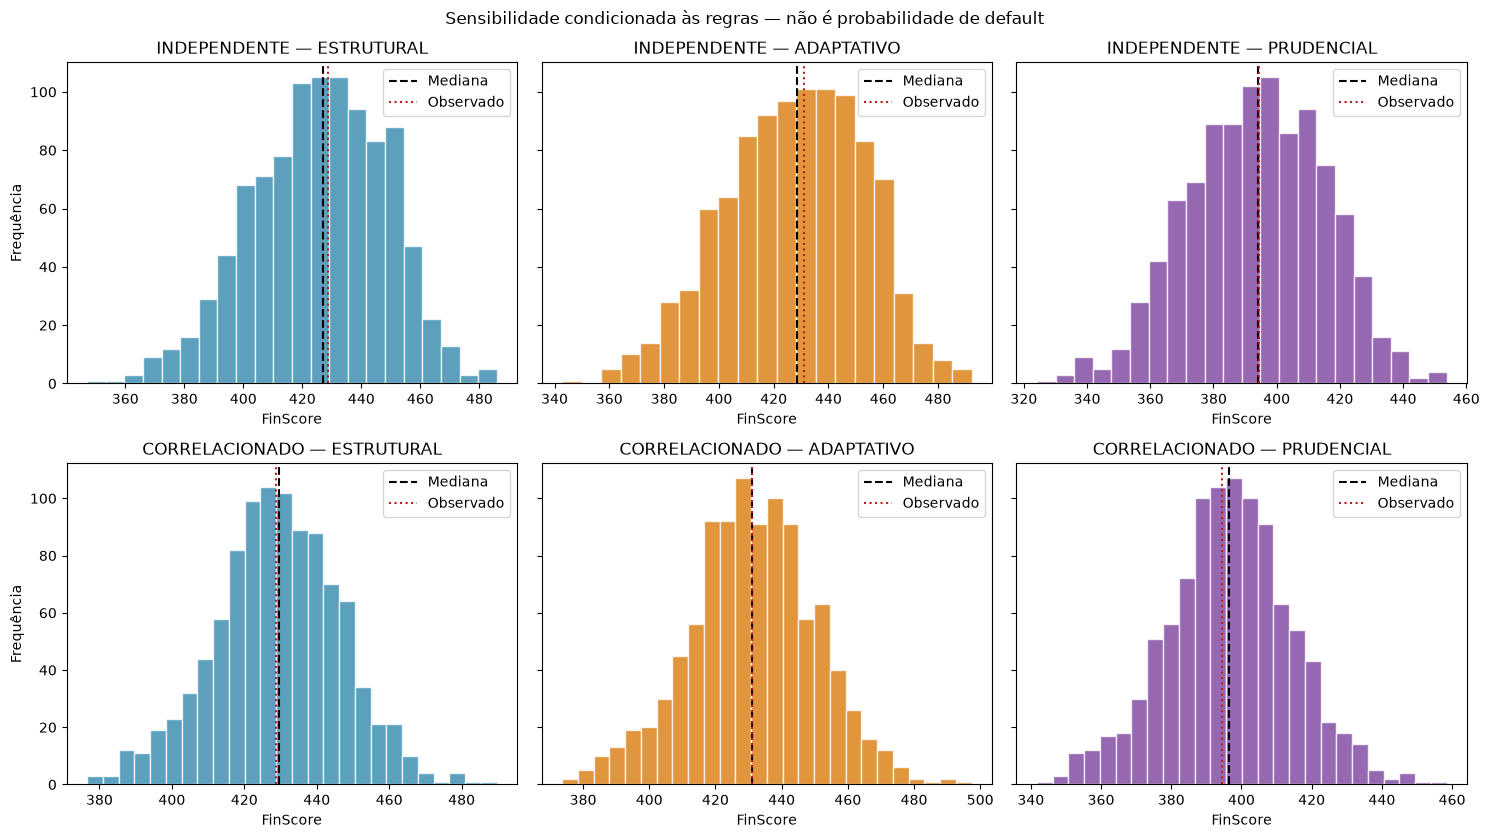

In [97]:
if MODELO_APTO:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.5), sharey="row")
    approaches = [
        ("INDEPENDENTE", df_simulacoes_independentes),
        ("CORRELACIONADO", df_simulacoes_correlacionadas),
    ]
    methods = ["estrutural", "adaptativo", "prudencial"]
    colors = ["#2E86AB", "#D97706", "#7A3E9D"]
    for row, (approach, table) in enumerate(approaches):
        for column_index, (method, color) in enumerate(zip(methods, colors)):
            ax = axes[row, column_index]
            column = f"finscore_{method}"
            ax.hist(
                table[column], bins="fd", color=color,
                alpha=0.78, edgecolor="white",
            )
            ax.axvline(
                table[column].median(), color="black",
                linestyle="--", label="Mediana",
            )
            observed = finscore_observado.get(column, np.nan)
            if np.isfinite(observed):
                ax.axvline(
                    observed, color="#B91C1C",
                    linestyle=":", label="Observado",
                )
            ax.set_title(f"{approach} — {method.upper()}")
            ax.set_xlabel("FinScore")
            ax.legend()
    axes[0, 0].set_ylabel("Frequência")
    axes[1, 0].set_ylabel("Frequência")
    fig.suptitle(
        "Sensibilidade condicionada às regras — não é probabilidade de default"
    )
    plt.tight_layout()
    plt.show()


In [98]:
df_serasa = assess_external_credit(
    finscore_observado.get("finscore_prudencial", np.nan),
    SERASA_SCORE,
    SERASA_DATA_CONSULTA,
    SERASA_RESTRICAO_GRAVE,
)
display(df_serasa)


,serasa_score,data_consulta,status,divergencia_pontos,nivel_divergencia,direcao,restricao_grave,score_integrado
0,700.0000,2026-07-23,ANALISAR_CONJUNTAMENTE,305.5685,elevada,evidência externa mais favorável,False,NaN


In [99]:
df_autotestes = run_self_tests() if EXECUTAR_AUTOTESTES else pd.DataFrame()
if EXECUTAR_AUTOTESTES:
    display(df_autotestes)
    if not df_autotestes["status"].eq("PASSOU").all():
        falhas = df_autotestes.loc[
            df_autotestes["status"].ne("PASSOU"),
            ["teste", "detalhe"],
        ]
        descricao = "; ".join(
            f"{linha.teste}: {linha.detalhe or 'sem detalhe'}"
            for linha in falhas.itertuples(index=False)
        )
        raise AssertionError(f"Autoteste(s) com falha: {descricao}")


,teste,status,detalhe
0,95-95-95 recebe nota temporal 100,PASSOU,
1,estabilidades refletem o nível,PASSOU,
2,melhora supera deterioração inversa,PASSOU,
3,estabilidade elevada não é penalizada,PASSOU,
4,deterioração não melhora nota temporal,PASSOU,
5,nota temporal permanece entre 0 e 100,PASSOU,
6,21 contas primárias,PASSOU,
7,base sintética aprovada,PASSOU,
8,base sintética sem correções,PASSOU,
9,dados reportados imutáveis,PASSOU,


***

## 6. RESULTADOS

In [100]:
def _formatar_numero_resumo(valor, casas=2):
    """Formata valores sem interferir nos cálculos."""
    try:
        numero = float(valor)
    except (TypeError, ValueError):
        return "não disponível"

    if not np.isfinite(numero):
        return "não disponível"

    return (
        f"{numero:,.{casas}f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )


def _formatar_percentual_resumo(valor, casas=1, proporcao=True):
    """Formata proporções ou percentuais."""
    try:
        numero = float(valor)
    except (TypeError, ValueError):
        return "não disponível"

    if not np.isfinite(numero):
        return "não disponível"

    if proporcao:
        numero *= 100

    return f"{_formatar_numero_resumo(numero, casas)}%"


def _obter_valor(objeto, chave, padrao=np.nan):
    """
    Obtém uma chave de dict, Series ou objeto semelhante,
    sem interromper a saída se a chave não existir.
    """
    if objeto is None:
        return padrao

    try:
        if hasattr(objeto, "get"):
            return objeto.get(chave, padrao)
    except Exception:
        pass

    return padrao


def _serie_numerica(df, coluna):
    """Converte uma coluna em série numérica finita."""
    if (
        not isinstance(df, pd.DataFrame)
        or df.empty
        or coluna not in df.columns
    ):
        return pd.Series(dtype=float)

    return (
        pd.to_numeric(df[coluna], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )


def _buscar_coluna(df, candidatos):
    """Localiza a primeira coluna disponível entre nomes candidatos."""
    if not isinstance(df, pd.DataFrame):
        return None

    mapa = {str(coluna).lower(): coluna for coluna in df.columns}

    for candidato in candidatos:
        if candidato.lower() in mapa:
            return mapa[candidato.lower()]

    return None


def _resumir_motivos_bloqueio(limite=5):
    """Consolida bloqueios já identificados pela validação."""
    motivos = []

    df = globals().get("df_qualidade")

    if isinstance(df, pd.DataFrame) and not df.empty:
        if "bloqueia_calculo" in df.columns:
            bloqueios = df.loc[
                df["bloqueia_calculo"].fillna(False).astype(bool)
            ].copy()
        else:
            bloqueios = pd.DataFrame()

        colunas_duplicidade = [
            coluna
            for coluna in ["tipo", "conta", "exercicios", "detalhe"]
            if coluna in bloqueios.columns
        ]

        if colunas_duplicidade:
            bloqueios_unicos = bloqueios.drop_duplicates(
                subset=colunas_duplicidade
            )
        else:
            bloqueios_unicos = bloqueios

        for _, ocorrencia in bloqueios_unicos.head(limite).iterrows():
            conta = str(ocorrencia.get("conta", "")).strip()
            exercicios = str(
                ocorrencia.get("exercicios", "")
            ).strip()
            detalhe = str(ocorrencia.get("detalhe", "")).strip()

            referencia = " / ".join(
                parte
                for parte in [
                    conta,
                    f"exercício {exercicios}" if exercicios else "",
                ]
                if parte
            )

            texto = (
                f"{referencia}: {detalhe}"
                if referencia and detalhe
                else referencia or detalhe
            )

            if texto:
                motivos.append(texto)

        excedentes = max(len(bloqueios_unicos) - len(motivos), 0)

        if excedentes:
            motivos.append(
                f"mais {excedentes} ocorrência(s) bloqueadora(s) "
                "detalhada(s) na planilha"
            )

    if not motivos:
        motivos.append(
            "a base não atendeu aos critérios impeditivos de "
            "qualidade definidos pelo modelo"
        )

    return motivos


def _resumo_monte_carlo():
    """
    Resume a distribuição Monte Carlo do FinScore prudencial.
    Retorna None caso as simulações não estejam disponíveis.
    """
    df = globals().get("df_simulacoes")

    if not isinstance(df, pd.DataFrame) or df.empty:
        return None

    coluna = _buscar_coluna(
        df,
        [
            "finscore_prudencial",
            "FinScore_prudencial",
            "finscore_final",
            "FinScore",
        ],
    )

    if coluna is None:
        return None

    serie = _serie_numerica(df, coluna)

    if serie.empty:
        return None

    media = serie.mean()
    desvio = serie.std(ddof=1)

    # A trava de 500 é identificada pela concentração exatamente nesse valor.
    # Não se presume que todo valor 500 decorra necessariamente da mesma regra.
    quantidade_500 = int(np.isclose(serie.to_numpy(), 500.0).sum())
    proporcao_500 = quantidade_500 / len(serie)

    erro_padrao = (
        desvio / np.sqrt(len(serie))
        if len(serie) > 1 and np.isfinite(desvio)
        else np.nan
    )

    return {
        "coluna": coluna,
        "simulacoes": int(len(serie)),
        "media": media,
        "mediana": serie.median(),
        "desvio_padrao": desvio,
        "erro_padrao_media": erro_padrao,
        "p01": serie.quantile(0.01),
        "p05": serie.quantile(0.05),
        "p10": serie.quantile(0.10),
        "p90": serie.quantile(0.90),
        "p95": serie.quantile(0.95),
        "p99": serie.quantile(0.99),
        "minimo": serie.min(),
        "maximo": serie.max(),
        "amplitude": serie.max() - serie.min(),
        "valores_unicos": int(serie.nunique()),
        "quantidade_500": quantidade_500,
        "proporcao_500": proporcao_500,
    }


def _resumo_convergencia_mc(coluna="finscore_prudencial"):
    """
    Compara estatísticas acumuladas da simulação.
    Isso não substitui uma execução independente com sementes diferentes.
    """
    df = globals().get("df_simulacoes")

    if (
        not isinstance(df, pd.DataFrame)
        or df.empty
        or coluna not in df.columns
    ):
        return None

    serie = _serie_numerica(df, coluna)

    if serie.empty:
        return None

    candidatos = [25, 50, 100, 250, 500, 1000, 3000, 5000, 10000]
    tamanhos = [n for n in candidatos if n <= len(serie)]

    if len(serie) not in tamanhos:
        tamanhos.append(len(serie))

    registros = []

    for n in sorted(set(tamanhos)):
        amostra = serie.iloc[:n]

        registros.append(
            {
                "simulacoes": n,
                "media": amostra.mean(),
                "mediana": amostra.median(),
                "p05": amostra.quantile(0.05),
                "p95": amostra.quantile(0.95),
                "desvio_padrao": amostra.std(ddof=1),
                "proporcao_500": np.isclose(
                    amostra.to_numpy(), 500.0
                ).mean(),
            }
        )

    return pd.DataFrame(registros)


def _resumo_pca_por_nucleo():
    """
    Extrai informações do diagnóstico do PCA sem pressupor uma estrutura
    rígida de colunas.
    """
    df = globals().get("df_diagnostico_pca")

    if not isinstance(df, pd.DataFrame) or df.empty:
        return None

    coluna_nucleo = _buscar_coluna(
        df,
        ["nucleo", "núcleo", "grupo", "bloco"],
    )

    coluna_componentes = _buscar_coluna(
        df,
        [
            "n_componentes",
            "componentes_retidos",
            "componentes",
            "n_components",
        ],
    )

    coluna_variancia = _buscar_coluna(
        df,
        [
            "variancia_explicada",
            "variancia_explicada_acumulada",
            "variancia_acumulada",
            "explained_variance",
            "explained_variance_ratio",
        ],
    )

    coluna_condicao = _buscar_coluna(
        df,
        [
            "numero_condicao",
            "número_condição",
            "condition_number",
            "condicao",
        ],
    )

    coluna_status = _buscar_coluna(
        df,
        [
            "status",
            "diagnostico",
            "diagnóstico",
            "classificacao",
            "classificação",
        ],
    )

    colunas = [
        coluna
        for coluna in [
            coluna_nucleo,
            coluna_componentes,
            coluna_variancia,
            coluna_condicao,
            coluna_status,
        ]
        if coluna is not None
    ]

    if not colunas:
        return df.copy()

    return df[colunas].copy()


def _principais_cargas_pca(limite=5):
    """
    Identifica os índices com maiores cargas absolutas no PCA.
    A carga absoluta representa influência, não direção econômica.
    """
    df = globals().get("df_cargas_pca")

    if not isinstance(df, pd.DataFrame) or df.empty:
        return None

    coluna_indice = _buscar_coluna(
        df,
        [
            "indice",
            "índice",
            "variavel",
            "variável",
            "indicador",
            "conta",
        ],
    )

    coluna_nucleo = _buscar_coluna(
        df,
        ["nucleo", "núcleo", "grupo", "bloco"],
    )

    colunas_carga = [
        coluna
        for coluna in df.columns
        if (
            str(coluna).lower().startswith("pc")
            or "carga" in str(coluna).lower()
            or "loading" in str(coluna).lower()
        )
        and pd.to_numeric(df[coluna], errors="coerce").notna().any()
    ]

    if not colunas_carga:
        return None

    registros = []

    for coluna_carga in colunas_carga:
        carga = pd.to_numeric(df[coluna_carga], errors="coerce")

        tabela = pd.DataFrame(
            {
                "nucleo": (
                    df[coluna_nucleo].astype(str)
                    if coluna_nucleo is not None
                    else ""
                ),
                "indice": (
                    df[coluna_indice].astype(str)
                    if coluna_indice is not None
                    else df.index.astype(str)
                ),
                "componente": str(coluna_carga),
                "carga": carga,
                "carga_absoluta": carga.abs(),
            }
        ).dropna(subset=["carga"])

        registros.append(
            tabela.sort_values(
                "carga_absoluta",
                ascending=False,
            ).head(limite)
        )

    if not registros:
        return None

    return pd.concat(registros, ignore_index=True)


def _comparar_observado_simulado(
    score_observado,
    resumo_mc,
):
    """Compara o FinScore pontual à distribuição simulada."""
    if resumo_mc is None:
        return None

    try:
        observado = float(score_observado)
    except (TypeError, ValueError):
        return None

    if not np.isfinite(observado):
        return None

    df = globals().get("df_simulacoes")
    coluna = resumo_mc["coluna"]
    serie = _serie_numerica(df, coluna)

    if serie.empty:
        return None

    percentil_empirico = (
        (serie <= observado).sum() / len(serie)
    )

    return {
        "observado": observado,
        "media_simulada": resumo_mc["media"],
        "mediana_simulada": resumo_mc["mediana"],
        "diferenca_media": observado - resumo_mc["media"],
        "diferenca_mediana": observado - resumo_mc["mediana"],
        "percentil_empirico": percentil_empirico,
    }


def _imprimir_tabela_texto(
    df,
    colunas=None,
    limite=10,
    casas=3,
):
    """Imprime DataFrame de forma compacta para a saída textual."""
    if not isinstance(df, pd.DataFrame) or df.empty:
        print("• informação não disponível")
        return

    tabela = df.copy()

    if colunas:
        colunas_existentes = [
            coluna for coluna in colunas if coluna in tabela.columns
        ]
        if colunas_existentes:
            tabela = tabela[colunas_existentes]

    tabela = tabela.head(limite)

    for coluna in tabela.columns:
        if pd.api.types.is_numeric_dtype(tabela[coluna]):
            tabela[coluna] = tabela[coluna].round(casas)

    print(
        tabela.to_string(
            index=False,
            max_cols=12,
            max_colwidth=35,
        )
    )


# =============================================================================
# EXECUÇÃO DA SAÍDA
# =============================================================================

# Captura toda a saída textual desta célula sem exibi-la imediatamente.
# Na célula subsequente, use: print(resultado_final_finscore)
import builtins
from io import StringIO

_buffer_resultado_final = StringIO()
_print_original = builtins.print


def _capturar_resultado_final(*args, **kwargs):
    """Direciona temporariamente os prints para o buffer de resultados."""
    kwargs["file"] = _buffer_resultado_final
    _print_original(*args, **kwargs)


print = _capturar_resultado_final

modelo_apto = bool(globals().get("MODELO_APTO", False))
exportar_excel = bool(globals().get("EXPORTAR_EXCEL", False))
arquivo_saida = globals().get("ARQUIVO_SAIDA")

status = globals().get("status_qualidade", {})
finscore = globals().get("finscore_observado", {})
confiabilidade = globals().get("confiabilidade_observada", {})

q_atual = globals().get("q_observado", np.nan)

linha = "=" * 88


if not modelo_apto:
    motivos_bloqueio = _resumir_motivos_bloqueio()

    pontos_observacao = [
        "conferir as contas e os exercícios citados nos demonstrativos originais",
        "reconciliar Balanço Patrimonial, subtotais e componentes",
        "validar pendências de confirmação e rubricas colocadas em quarentena",
        "consultar as abas 'qualidade_dados', 'correcoes_auditoria' e "
        "'alertas_vies_material' da planilha exportada",
    ]

    print("\n" + linha)
    print("AVISO FINAL — FINSCORE NÃO CALCULADO")

    print("\nMotivos simplificados:")
    for motivo in motivos_bloqueio:
        print(f"• {motivo}")

    print("\nO que o parecerista deve observar:")
    for ponto in pontos_observacao:
        print(f"• {ponto}")

    if exportar_excel and arquivo_saida is not None:
        try:
            print(
                "\nInformações completas: "
                f"{arquivo_saida.resolve()}"
            )
        except Exception:
            print(f"\nInformações completas: {arquivo_saida}")

    print(linha)


else:
    score_prudencial_observado = _obter_valor(
        finscore,
        "finscore_prudencial",
    )

    score_estrutural = _obter_valor(
        finscore,
        "finscore_estrutural",
    )

    score_estrutural_pos_gargalo = _obter_valor(
        finscore,
        "finscore_estrutural_pos_gargalo",
    )

    score_adaptativo = _obter_valor(
        finscore,
        "finscore_adaptativo",
    )

    score_adaptativo_pos_gargalo = _obter_valor(
        finscore,
        "finscore_adaptativo_pos_gargalo",
    )

    score_prudencial_pre_cap = _obter_valor(
        finscore,
        "finscore_prudencial_pre_cap",
    )

    nucleo_eo = _obter_valor(
        finscore,
        "nucleo_EO_estrutural",
    )

    nucleo_fp = _obter_valor(
        finscore,
        "nucleo_FP_estrutural",
    )

    resumo_mc = _resumo_monte_carlo()

    comparacao_mc = _comparar_observado_simulado(
        score_prudencial_observado,
        resumo_mc,
    )

    resumo_pca = _resumo_pca_por_nucleo()
    cargas_pca = _principais_cargas_pca(limite=5)

    print("\n" + linha)
    print("RESUMO FINAL — FINSCORE CALCULADO")

    # -------------------------------------------------------------------------
    # 1. RESULTADO PRINCIPAL
    # -------------------------------------------------------------------------

    print("\n1. RESULTADO PRINCIPAL")

    print(
        "Classificação de uso: "
        f"{_obter_valor(status, 'classificacao_uso', 'não disponível')}"
    )

    print(
        "FinScore prudencial observado: "
        f"{_formatar_numero_resumo(score_prudencial_observado)}"
    )

    print(
        "Núcleo econômico-operacional (EO): "
        f"{_formatar_numero_resumo(nucleo_eo)}"
    )

    print(
        "Núcleo financeiro-patrimonial (FP): "
        f"{_formatar_numero_resumo(nucleo_fp)}"
    )

    print(
        "Índice de confiabilidade: "
        f"{_formatar_numero_resumo(q_atual, 3)} "
        f"({_obter_valor(confiabilidade, 'classificacao_confiabilidade', 'não disponível')})"
    )

    limite_inferior = _obter_valor(
        finscore,
        "faixa_incerteza_inferior",
    )

    limite_superior = _obter_valor(
        finscore,
        "faixa_incerteza_superior",
    )

    try:
        faixa_valida = (
            np.isfinite(float(limite_inferior))
            and np.isfinite(float(limite_superior))
            and not np.isclose(
                float(limite_inferior),
                float(limite_superior),
            )
        )
    except (TypeError, ValueError):
        faixa_valida = False

    if faixa_valida:
        print(
            "Faixa parcial de incerteza: "
            f"{_formatar_numero_resumo(limite_inferior)} a "
            f"{_formatar_numero_resumo(limite_superior)}"
        )

    # -------------------------------------------------------------------------
    # 2. DECOMPOSIÇÃO DO SCORE
    # -------------------------------------------------------------------------

    print("\n2. DECOMPOSIÇÃO DO FINSCORE")

    componentes_score = [
        ("Estrutural", score_estrutural),
        (
            "Estrutural após gargalo",
            score_estrutural_pos_gargalo,
        ),
        ("Adaptativo/PCA", score_adaptativo),
        (
            "Adaptativo/PCA após gargalo",
            score_adaptativo_pos_gargalo,
        ),
        (
            "Prudencial antes da trava",
            score_prudencial_pre_cap,
        ),
        (
            "Prudencial final",
            score_prudencial_observado,
        ),
    ]

    encontrou_componente = False

    for nome, valor in componentes_score:
        try:
            valor_valido = np.isfinite(float(valor))
        except (TypeError, ValueError):
            valor_valido = False

        if valor_valido:
            encontrou_componente = True
            print(
                f"• {nome}: "
                f"{_formatar_numero_resumo(valor)}"
            )

    if not encontrou_componente:
        print(
            "• decomposição detalhada não disponível no objeto "
            "'finscore_observado'"
        )

    # Efeitos incrementais, quando calculáveis
    try:
        efeito_gargalo_estrutural = (
            float(score_estrutural_pos_gargalo)
            - float(score_estrutural)
        )

        print(
            "• Efeito do gargalo sobre o estrutural: "
            f"{_formatar_numero_resumo(efeito_gargalo_estrutural)} ponto(s)"
        )
    except (TypeError, ValueError):
        pass

    try:
        efeito_adaptativo = (
            float(score_adaptativo)
            - float(score_estrutural)
        )

        print(
            "• Efeito adaptativo/PCA antes do gargalo: "
            f"{_formatar_numero_resumo(efeito_adaptativo)} ponto(s)"
        )
    except (TypeError, ValueError):
        pass

    try:
        efeito_trava = (
            float(score_prudencial_observado)
            - float(score_prudencial_pre_cap)
        )

        print(
            "• Efeito da trava prudencial no resultado observado: "
            f"{_formatar_numero_resumo(efeito_trava)} ponto(s)"
        )
    except (TypeError, ValueError):
        pass

    # -------------------------------------------------------------------------
    # 3. DIAGNÓSTICO DO PCA
    # -------------------------------------------------------------------------

    print("\n3. DIAGNÓSTICO DO PCA")

    if resumo_pca is not None:
        _imprimir_tabela_texto(
            resumo_pca,
            limite=10,
            casas=4,
        )
    else:
        print(
            "• diagnóstico consolidado do PCA não disponível"
        )

    print("\nÍndices com maiores cargas absolutas:")

    if cargas_pca is not None:
        _imprimir_tabela_texto(
            cargas_pca,
            colunas=[
                "nucleo",
                "indice",
                "componente",
                "carga",
                "carga_absoluta",
            ],
            limite=15,
            casas=4,
        )

        print(
            "Observação: a carga absoluta indica influência estatística; "
            "o sinal da carga deve ser interpretado conjuntamente com o "
            "sentido econômico e a orientação do componente."
        )
    else:
        print(
            "• cargas do PCA não disponíveis em estrutura reconhecida"
        )

    # -------------------------------------------------------------------------
    # 4. MONTE CARLO
    # -------------------------------------------------------------------------

    print("\n4. ANÁLISE DE SENSIBILIDADE — MONTE CARLO")

    if resumo_mc is None:
        print(
            "• distribuição simulada do FinScore prudencial não disponível"
        )
    else:
        print(
            "• Simulações válidas: "
            f"{resumo_mc['simulacoes']}"
        )

        print(
            "• Média simulada: "
            f"{_formatar_numero_resumo(resumo_mc['media'])}"
        )

        print(
            "• Mediana simulada: "
            f"{_formatar_numero_resumo(resumo_mc['mediana'])}"
        )

        print(
            "• Desvio-padrão: "
            f"{_formatar_numero_resumo(resumo_mc['desvio_padrao'])}"
        )

        print(
            "• Quantis empíricos P05–P95: "
            f"{_formatar_numero_resumo(resumo_mc['p05'])} a "
            f"{_formatar_numero_resumo(resumo_mc['p95'])}"
        )

        print(
            "• Quantis empíricos P01–P99: "
            f"{_formatar_numero_resumo(resumo_mc['p01'])} a "
            f"{_formatar_numero_resumo(resumo_mc['p99'])}"
        )

        print(
            "• Mínimo e máximo simulados: "
            f"{_formatar_numero_resumo(resumo_mc['minimo'])} a "
            f"{_formatar_numero_resumo(resumo_mc['maximo'])}"
        )

        print(
            "• Amplitude total: "
            f"{_formatar_numero_resumo(resumo_mc['amplitude'])} ponto(s)"
        )

        print(
            "• Cenários exatamente em 500: "
            f"{resumo_mc['quantidade_500']} "
            f"({_formatar_percentual_resumo(resumo_mc['proporcao_500'])})"
        )

        if comparacao_mc is not None:
            print(
                "• Diferença entre score observado e média simulada: "
                f"{_formatar_numero_resumo(comparacao_mc['diferenca_media'])} "
                "ponto(s)"
            )

            print(
                "• Diferença entre score observado e mediana simulada: "
                f"{_formatar_numero_resumo(comparacao_mc['diferenca_mediana'])} "
                "ponto(s)"
            )

            print(
                "• Posição do score observado na distribuição simulada: "
                f"percentil empírico "
                f"{_formatar_percentual_resumo(comparacao_mc['percentil_empirico'])}"
            )

        # ---------------------------------------------------------------------
        # 5. CONVERGÊNCIA
        # ---------------------------------------------------------------------

        print("\n5. ESTABILIDADE NUMÉRICA DA SIMULAÇÃO")

        df_convergencia = _resumo_convergencia_mc(
            resumo_mc["coluna"]
        )

        if (
            isinstance(df_convergencia, pd.DataFrame)
            and not df_convergencia.empty
        ):
            tabela_convergencia = df_convergencia.copy()

            tabela_convergencia["proporcao_500"] = (
                tabela_convergencia["proporcao_500"] * 100
            )

            tabela_convergencia = tabela_convergencia.rename(
                columns={
                    "simulacoes": "N",
                    "media": "média",
                    "mediana": "mediana",
                    "p05": "P05",
                    "p95": "P95",
                    "desvio_padrao": "desvio",
                    "proporcao_500": "% em 500",
                }
            )

            _imprimir_tabela_texto(
                tabela_convergencia,
                limite=20,
                casas=3,
            )

            if len(tabela_convergencia) >= 2:
                primeira = tabela_convergencia.iloc[-2]
                ultima = tabela_convergencia.iloc[-1]

                variacao_media = (
                    float(ultima["média"])
                    - float(primeira["média"])
                )

                variacao_p05 = (
                    float(ultima["P05"])
                    - float(primeira["P05"])
                )

                print(
                    "• Variação da média entre os dois últimos "
                    "tamanhos avaliados: "
                    f"{_formatar_numero_resumo(variacao_media, 3)}"
                )

                print(
                    "• Variação do P05 entre os dois últimos "
                    "tamanhos avaliados: "
                    f"{_formatar_numero_resumo(variacao_p05, 3)}"
                )

            print(
                "Observação: esta tabela avalia subconjuntos acumulados "
                "da mesma execução. Ela indica estabilidade numérica, mas "
                "não substitui execuções independentes com sementes distintas."
            )
        else:
            print(
                "• informações de convergência não disponíveis"
            )

    # -------------------------------------------------------------------------
    # 6. ALERTAS AUTOMÁTICOS
    # -------------------------------------------------------------------------



    print("\n6. DIAGNÓSTICO DE REDUNDÂNCIA DO NÚCLEO FP")
    fp_table = globals().get("df_sensibilidade_redundancia_fp", pd.DataFrame())
    fp_summary = globals().get("resumo_redundancia_fp", {})
    if isinstance(fp_table, pd.DataFrame) and not fp_table.empty:
        _imprimir_tabela_texto(
            fp_table[[
                "variacao", "peso_capitalizacao", "peso_endividamento",
                "nucleo_FP", "finscore_estrutural_pos_gargalo",
                "finscore_estrutural_com_cap",
            ]],
            limite=5,
            casas=3,
        )
        print(
            "• Amplitude antes do cap: "
            f"{_formatar_numero_resumo(fp_summary.get('amplitude_pre_cap'))} ponto(s)"
        )
        print(
            "• Amplitude final: "
            f"{_formatar_numero_resumo(fp_summary.get('amplitude_final'))} ponto(s)"
        )
        print(f"• Conclusão: {fp_summary.get('conclusao', 'não disponível')}")
        if fp_summary.get("influencia_material", False):
            print(
                "• A redundância entre capitalização e endividamento está "
                "influenciando materialmente o FinScore estrutural."
            )
        else:
            print(
                "• A redundância não altera materialmente o FinScore estrutural "
                "no limiar configurado."
            )
    else:
        print("• diagnóstico não disponível")

    print("\n7. COMPARAÇÃO DAS ABORDAGENS DE MONTE CARLO")
    mc_comparison = globals().get("df_comparacao_monte_carlo", pd.DataFrame())
    if isinstance(mc_comparison, pd.DataFrame) and not mc_comparison.empty:
        _imprimir_tabela_texto(mc_comparison, limite=10, casas=3)
        for diagnostics in [
            globals().get("diagnosticos_simulacao", {}),
            globals().get("diagnosticos_simulacao_correlacionada", {}),
        ]:
            if diagnostics:
                print(
                    f"• {diagnostics.get('abordagem')}: rejeição "
                    f"{_formatar_percentual_resumo(diagnostics.get('taxa_rejeicao'))}; "
                    f"limite {_formatar_percentual_resumo(diagnostics.get('limite_taxa_rejeicao'))}; "
                    f"status {diagnostics.get('status_rejeicao')}"
                )
    else:
        print("• comparação não disponível")

    print("\n8. PONTOS DE ATENÇÃO AO PARECERISTA")

    alertas = []

    apto_decisao = bool(
        _obter_valor(status, "apto_decisao", False)
    )

    if not apto_decisao:
        alertas.append(
            "o FinScore é interpretável, mas existem alertas prudenciais "
            "e/ou documentais que devem ser considerados na decisão"
        )

    if resumo_mc is not None:
        if resumo_mc["simulacoes"] < 1000:
            alertas.append(
                "a simulação possui menos de 1.000 cenários; as medidas "
                "centrais são úteis, mas frequências de cauda e "
                "percentis extremos ainda podem apresentar instabilidade"
            )

        if resumo_mc["proporcao_500"] >= 0.05:
            alertas.append(
                "há concentração material de cenários exatamente em 500; "
                "o parecerista deve identificar a regra prudencial que "
                "provocou essa reclassificação"
            )

        if resumo_mc["desvio_padrao"] >= 40:
            alertas.append(
                "a dispersão do FinScore prudencial é elevada em relação "
                "aos scores anteriores à trava, indicando sensibilidade "
                "relevante aos cenários adversos"
            )

    try:
        diferenca_fluxos = abs(
            float(score_prudencial_pre_cap)
            - float(score_estrutural_pos_gargalo)
        )

        diferenca_adaptativo = abs(
            float(score_prudencial_pre_cap)
            - float(score_adaptativo_pos_gargalo)
        )

        if (
            diferenca_fluxos < 0.10
            and diferenca_adaptativo > 0.50
        ):
            alertas.append(
                "o prudencial antes da trava está mais próximo do "
                "estrutural pós-gargalo do que do adaptativo pós-gargalo; "
                "convém confirmar se esse encadeamento foi intencional"
            )
    except (TypeError, ValueError):
        pass

    if alertas:
        for alerta in alertas:
            print(f"• {alerta}")
    else:
        print(
            "• nenhum alerta adicional foi identificado automaticamente "
            "pelos critérios desta célula"
        )

    print(
        "• observar a substância econômica da operação, a origem e "
        "realização dos créditos fiscais, as partes relacionadas, as "
        "garantias e a capacidade de absorção de perdas"
    )

    # -------------------------------------------------------------------------
    # 7. LOCALIZAÇÃO DOS RESULTADOS COMPLETOS
    # -------------------------------------------------------------------------

    print("\n9. INFORMAÇÕES COMPLETAS")

    if exportar_excel and arquivo_saida is not None:
        try:
            caminho_saida = arquivo_saida.resolve()
        except Exception:
            caminho_saida = arquivo_saida

        print(
            "Consulte a planilha para resultados completos, cenários, "
            f"simulações e trilha de auditoria: {caminho_saida}"
        )
    else:
        print(
            "Consulte as tabelas geradas pelo notebook; a exportação "
            "da planilha está desativada."
        )

    print(linha)


# Disponibiliza o relatório completo e restaura o comportamento normal de print.
resultado_final_finscore = _buffer_resultado_final.getvalue()
print = _print_original
_buffer_resultado_final.close()

***

#### 10.1 FinScore

In [101]:
# Clique em 'scrollable element' ou em 'text editor' para ver os resultados completos.
# Os resultados mais importantes estão na seção '1. RESULTADO PRINCIPAL'.
print(resultado_final_finscore)


RESUMO FINAL — FINSCORE CALCULADO

1. RESULTADO PRINCIPAL
Classificação de uso: CALCULADO_COM_ALERTAS
FinScore prudencial observado: 394,43
Núcleo econômico-operacional (EO): 629,49
Núcleo financeiro-patrimonial (FP): 291,85
Índice de confiabilidade: 0,918 (ALTA)

2. DECOMPOSIÇÃO DO FINSCORE
• Estrutural: 428,62
• Estrutural após gargalo: 394,43
• Adaptativo/PCA: 431,08
• Adaptativo/PCA após gargalo: 398,97
• Prudencial antes da trava: 394,43
• Prudencial final: 394,43
• Efeito do gargalo sobre o estrutural: -34,19 ponto(s)
• Efeito adaptativo/PCA antes do gargalo: 2,46 ponto(s)
• Efeito da trava prudencial no resultado observado: 0,00 ponto(s)

3. DIAGNÓSTICO DO PCA
nucleo  componentes
    EO            2
    FP            2

Índices com maiores cargas absolutas:
nucleo                 indice componente   carga  carga_absoluta
    EO           margem_bruta        PC1  0.7056          0.7056
    EO            margem_ebit        PC1  0.7056          0.7056
    FP      liquidez_corrente

In [102]:
# --- EM BRANCO

In [103]:
# --- EM BRANCO

In [104]:
# --- EM BRANCO

***

#### 10.2 Tempo de Execução do Script

In [105]:
fim = time.time()
tempo = fim - inicio
minutos = int(tempo // 60)
segundos = tempo % 60

In [106]:
if minutos > 0:
    print(f"Tempo de execução do script: {minutos} min e {segundos:.2f} segundos.")
else:
    print(f"Tempo de execução do script: {segundos:.2f} segundos.")

Tempo de execução do script: 2 min e 26.89 segundos.
